# Phase 1: MCX Gold Futures Data Collection & Validation

## Objective

Collect and validate historical MCX gold futures data for:

- GOLDM
- GOLDTEN
- GOLDGUINEA
- GOLDPETAL

The validated data will be used for cross-contract relative pricing analysis.

In [1]:
%pip install pandas numpy requests openpyxl pyarrow

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import requests
from pathlib import Path
from io import BytesIO
import zipfile
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

print("Project root:", PROJECT_ROOT)
print("Raw path:", PROJECT_ROOT / "data" / "raw")
print("Is raw a folder?", (PROJECT_ROOT / "data" / "raw").is_dir())
print("Is raw a file?", (PROJECT_ROOT / "data" / "raw").is_file())

Project root: c:\Users\ASUS\Desktop\commodity-intelligence
Raw path: c:\Users\ASUS\Desktop\commodity-intelligence\data\raw
Is raw a folder? False
Is raw a file? True


FileExistsError: [WinError 183] Cannot create a file when that file already exists: 'c:\\Users\\ASUS\\Desktop\\commodity-intelligence\\data\\cleaned'

In [5]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data"

for name in ["raw", "cleaned", "processed"]:
    path = DATA_PATH / name
    print(f"{name}:")
    print("  Exists:", path.exists())
    print("  Folder:", path.is_dir())
    print("  File:", path.is_file())
    print()

raw:
  Exists: True
  Folder: True
  File: False

cleaned:
  Exists: True
  Folder: False
  File: True

processed:
  Exists: True
  Folder: False
  File: True



In [6]:
from pathlib import Path

DATA_PATH = PROJECT_ROOT / "data"

for name in ["cleaned", "processed"]:
    path = DATA_PATH / name
    print(name, "=", path)
    print("Size:", path.stat().st_size, "bytes")
    print()

cleaned = c:\Users\ASUS\Desktop\commodity-intelligence\data\cleaned
Size: 0 bytes

processed = c:\Users\ASUS\Desktop\commodity-intelligence\data\processed
Size: 0 bytes



In [7]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"
CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "cleaned"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

RAW_DATA_PATH.mkdir(parents=True, exist_ok=True)
CLEANED_DATA_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_PATH)
print("Cleaned data folder:", CLEANED_DATA_PATH)
print("Processed data folder:", PROCESSED_DATA_PATH)
print("Folders created successfully!")

Project root: c:\Users\ASUS\Desktop\commodity-intelligence
Raw data folder: c:\Users\ASUS\Desktop\commodity-intelligence\data\raw
Cleaned data folder: c:\Users\ASUS\Desktop\commodity-intelligence\data\cleaned
Processed data folder: c:\Users\ASUS\Desktop\commodity-intelligence\data\processed
Folders created successfully!


In [8]:
from pathlib import Path

print("Files inside data/raw:\n")

for file in RAW_DATA_PATH.iterdir():
    print(file.name)

Files inside data/raw:



In [9]:
for file in RAW_DATA_PATH.iterdir():
    print(file.name)

BhavCopyDateWise_01102026.xls


ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [11]:
%pip install xlrd

Note: you may need to restart the kernel to use updated packages.


NameError: name 'RAW_DATA_PATH' is not defined

In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

print("Raw folder:", RAW_DATA_PATH)

Raw folder: c:\Users\ASUS\Desktop\commodity-intelligence\data\raw


XLRDError: Unsupported format, or corrupt file: Expected BOF record; found b'\n<table '

In [4]:
from pathlib import Path

sample_file = RAW_DATA_PATH / "BhavCopyDateWise_01102026.xls"

with open(sample_file, "rb") as f:
    first_bytes = f.read(300)

print(first_bytes)

b'\n<table border="1" style="border-collapse: collapse;">\n<thead>\n<tr>\n                        <th style="padding: 5px; text-align: center; background-color: #f2f2f2; font-weight: bold;">Date</th><th style="padding: 5px; text-align: center; background-color: #f2f2f2; font-weight: bold;">Instrument Name'


ImportError: `Import lxml` failed.  Use pip or conda to install the lxml package.

In [6]:
%pip install lxml

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.1 MB 3.1 MB/s eta 0:00:02
   ------------ --------------------------- 1.3/4.1 MB 3.9 MB/s eta 0:00:01
   -------------------- ------------------- 2.1/4.1 MB 3.7 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.1 MB 3.7 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.1 MB 3.8 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.1 MB 3.8 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.1 MB 3.8 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.1 MB 3.8 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.1 MB 3.8 MB/s eta 0:00:01
   ------------------------------------ --- 3.7/4.1 MB 1.8 MB/s eta 0:00:01
   ------------------------------------ --- 3.7/4.1 MB 1.8 MB/s eta 0:00:01
   ------------------------------------ --- 3.7/4.1 MB 1.8 MB/s eta 0:00:01
   ----------------

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

print(RAW_DATA_PATH)

c:\Users\ASUS\Desktop\commodity-intelligence\data\raw


In [2]:
import pandas as pd

sample_file = RAW_DATA_PATH / "BhavCopyDateWise_01102026.xls"

tables = pd.read_html(sample_file)

print("Number of tables found:", len(tables))

for i, table in enumerate(tables):
    print(f"\nTable {i}:")
    print("Shape:", table.shape)
    print(table.head(2))

Number of tables found: 1

Table 0:
Shape: (15104, 15)
          Date Instrument Name   Symbol Expiry Date Option Type  Strike Price  \
0  01 Oct 2026          FUTCOM  ALUMINI   30OCT2026           -             0   
1  01 Oct 2026          FUTCOM  ALUMINI   30NOV2026           -             0   

    Open    High     Low   Close  Previous Close  Volume(Lots)  \
0  340.6  341.20  337.00  337.65          341.80          3096   
1  339.9  340.85  336.15  337.15          341.45           479   

  Volume(In 000's)  Value(Lacs)  Open Interest(Lots)  
0     3096.000 KGS     10481.59                 2635  
1      479.000 KGS      1620.09                  613  


In [3]:
df = tables[0].copy()

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (15104, 15)

Columns:
['Date', 'Instrument Name', 'Symbol', 'Expiry Date', 'Option Type', 'Strike Price', 'Open', 'High', 'Low', 'Close', 'Previous Close', 'Volume(Lots)', "Volume(In 000's)", 'Value(Lacs)', 'Open Interest(Lots)']


In [4]:
gold_symbols = df[
    df["Symbol"]
    .astype(str)
    .str.upper()
    .str.contains("GOLD", na=False)
]["Symbol"].unique()

print("Gold symbols found:")
print(gold_symbols)

Gold symbols found:
<ArrowStringArray>
['GOLD', 'GOLDGUINEA', 'GOLDM', 'GOLDPETAL', 'GOLDTEN']
Length: 5, dtype: str


In [5]:
TARGET_CONTRACTS = [
    "GOLDM",
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL"
]

gold_df = df[
    df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(TARGET_CONTRACTS)
].copy()

print("Gold target rows:", len(gold_df))

print("\nContracts found:")
print(gold_df["Symbol"].value_counts())

Gold target rows: 522

Contracts found:
Symbol
GOLDM         504
GOLDGUINEA      6
GOLDPETAL       6
GOLDTEN         6
Name: count, dtype: int64


In [6]:
print(
    gold_df[
        [
            "Date",
            "Symbol",
            "Expiry Date",
            "Open",
            "High",
            "Low",
            "Close",
            "Volume(Lots)",
            "Open Interest(Lots)"
        ]
    ].to_string(index=False)
)

       Date     Symbol Expiry Date     Open     High      Low    Close  Volume(Lots)  Open Interest(Lots)
01 Oct 2026 GOLDGUINEA   30OCT2026 119589.0 120295.0 119221.0 119993.0         11305                13525
01 Oct 2026 GOLDGUINEA   30NOV2026 120747.0 121484.0 120407.0 121147.0          3323                 7551
01 Oct 2026 GOLDGUINEA   31DEC2026 121759.0 122451.0 121434.0 122171.0           928                 3301
01 Oct 2026 GOLDGUINEA   29JAN2027 122544.0 123443.0 122536.0 123222.0           256                 1753
01 Oct 2026 GOLDGUINEA   26FEB2027 123903.0 124450.0 123543.0 124072.0           109                  452
01 Oct 2026 GOLDGUINEA   31MAR2027      NaN      NaN      NaN 124050.0             0                    0
01 Oct 2026      GOLDM   05OCT2026 146875.0 148295.0 146550.0 147729.0          1722                 1589
01 Oct 2026      GOLDM   29OCT2026      NaN      NaN      NaN   6841.0             0                   83
01 Oct 2026      GOLDM   29OCT2026      NaN   

In [7]:
target_symbols = [
    "GOLDM",
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL"
]

check_df = df[
    df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(target_symbols)
].copy()

print(
    check_df.groupby(["Symbol", "Instrument Name"])
    .size()
    .reset_index(name="Rows")
    .to_string(index=False)
)

    Symbol Instrument Name  Rows
GOLDGUINEA          FUTCOM     6
     GOLDM          FUTCOM     6
     GOLDM          OPTFUT   498
 GOLDPETAL          FUTCOM     6
   GOLDTEN          FUTCOM     6


In [8]:
gold_df = check_df[
    check_df["Instrument Name"].astype(str).str.strip().eq("FUTCOM")
].copy()

In [9]:
target_symbols = [
    "GOLDM",
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL"
]

check_df = df[
    df["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
    .isin(target_symbols)
].copy()

print(
    check_df.groupby(["Symbol", "Instrument Name"])
    .size()
    .reset_index(name="Rows")
    .to_string(index=False)
)

    Symbol Instrument Name  Rows
GOLDGUINEA          FUTCOM     6
     GOLDM          FUTCOM     6
     GOLDM          OPTFUT   498
 GOLDPETAL          FUTCOM     6
   GOLDTEN          FUTCOM     6


In [10]:
TARGET_CONTRACTS = [
    "GOLDM",
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL"
]

gold_futures = df[
    (df["Instrument Name"].astype(str).str.strip().str.upper() == "FUTCOM") &
    (df["Symbol"].astype(str).str.strip().str.upper().isin(TARGET_CONTRACTS))
].copy()

# Clean symbol names
gold_futures["Symbol"] = (
    gold_futures["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
)

print("Correct futures rows:", len(gold_futures))

print("\nContracts:")
print(gold_futures["Symbol"].value_counts())

print("\nData:")
print(
    gold_futures[
        [
            "Date",
            "Symbol",
            "Expiry Date",
            "Open",
            "High",
            "Low",
            "Close",
            "Volume(Lots)",
            "Open Interest(Lots)"
        ]
    ].to_string(index=False)
)

Correct futures rows: 24

Contracts:
Symbol
GOLDGUINEA    6
GOLDM         6
GOLDPETAL     6
GOLDTEN       6
Name: count, dtype: int64

Data:
       Date     Symbol Expiry Date     Open     High      Low    Close  Volume(Lots)  Open Interest(Lots)
01 Oct 2026 GOLDGUINEA   30OCT2026 119589.0 120295.0 119221.0 119993.0         11305                13525
01 Oct 2026 GOLDGUINEA   30NOV2026 120747.0 121484.0 120407.0 121147.0          3323                 7551
01 Oct 2026 GOLDGUINEA   31DEC2026 121759.0 122451.0 121434.0 122171.0           928                 3301
01 Oct 2026 GOLDGUINEA   29JAN2027 122544.0 123443.0 122536.0 123222.0           256                 1753
01 Oct 2026 GOLDGUINEA   26FEB2027 123903.0 124450.0 123543.0 124072.0           109                  452
01 Oct 2026 GOLDGUINEA   31MAR2027      NaN      NaN      NaN 124050.0             0                    0
01 Oct 2026      GOLDM   05OCT2026 146875.0 148295.0 146550.0 147729.0          1722                 1589
01 Oct 2026

In [11]:
raw_gold_file = RAW_DATA_PATH / "mcx_gold_futures_01102026.csv"

gold_futures.to_csv(raw_gold_file, index=False)

print("Saved successfully:")
print(raw_gold_file)

Saved successfully:
c:\Users\ASUS\Desktop\commodity-intelligence\data\raw\mcx_gold_futures_01102026.csv


In [12]:
print("Missing values:")
print(gold_futures.isna().sum())

Missing values:
Date                   0
Instrument Name        0
Symbol                 0
Expiry Date            0
Option Type            0
Strike Price           0
Open                   1
High                   1
Low                    1
Close                  0
Previous Close         0
Volume(Lots)           0
Volume(In 000's)       0
Value(Lacs)            0
Open Interest(Lots)    0
dtype: int64


In [13]:
duplicates = gold_futures.duplicated(
    subset=["Symbol", "Expiry Date"]
).sum()

print("Duplicate Symbol + Expiry rows:", duplicates)

Duplicate Symbol + Expiry rows: 0


In [14]:
print("Expiry dates by contract:\n")

for symbol in TARGET_CONTRACTS:
    print(f"\n{symbol}")
    print(
        gold_futures.loc[
            gold_futures["Symbol"] == symbol,
            "Expiry Date"
        ].tolist()
    )

Expiry dates by contract:


GOLDM
['05OCT2026', '05NOV2026', '04DEC2026', '05JAN2027', '05FEB2027', '05MAR2027']

GOLDTEN
['30OCT2026', '30NOV2026', '31DEC2026', '29JAN2027', '26FEB2027', '31MAR2027']

GOLDGUINEA
['30OCT2026', '30NOV2026', '31DEC2026', '29JAN2027', '26FEB2027', '31MAR2027']

GOLDPETAL
['30OCT2026', '30NOV2026', '31DEC2026', '29JAN2027', '26FEB2027', '31MAR2027']


In [15]:
price_columns = ["Open", "High", "Low", "Close"]

print(gold_futures[price_columns].describe())

                Open           High            Low          Close
count      23.000000      23.000000      23.000000      24.000000
mean   109326.304348  110069.608696  109111.869565  110411.875000
std     58367.640240   58773.341018   58253.722495   57429.379539
min     14911.000000   15035.000000   14910.000000   15002.000000
25%     67638.500000   68022.500000   67424.000000   93918.000000
50%    146875.000000  148295.000000  146550.000000  135900.500000
75%    151206.500000  152277.000000  150896.000000  151753.750000
max    155990.000000  156112.000000  155295.000000  155662.000000


In [16]:
print(
    gold_futures[
        ["Symbol", "Expiry Date", "Close", "Volume(Lots)", "Open Interest(Lots)"]
    ].sort_values(["Symbol", "Expiry Date"]).to_string(index=False)
)

    Symbol Expiry Date    Close  Volume(Lots)  Open Interest(Lots)
GOLDGUINEA   26FEB2027 124072.0           109                  452
GOLDGUINEA   29JAN2027 123222.0           256                 1753
GOLDGUINEA   30NOV2026 121147.0          3323                 7551
GOLDGUINEA   30OCT2026 119993.0         11305                13525
GOLDGUINEA   31DEC2026 122171.0           928                 3301
GOLDGUINEA   31MAR2027 124050.0             0                    0
     GOLDM   04DEC2026 150374.0         14954                14420
     GOLDM   05FEB2027 153150.0           368                 1815
     GOLDM   05JAN2027 151629.0          1293                 3687
     GOLDM   05MAR2027 154617.0           152                  239
     GOLDM   05NOV2026 149055.0         41017                42632
     GOLDM   05OCT2026 147729.0          1722                 1589
 GOLDPETAL   26FEB2027  15561.0          4126                11492
 GOLDPETAL   29JAN2027  15423.0          7973                3

In [17]:
missing_ohlc = gold_futures[
    gold_futures[["Open", "High", "Low"]].isna().any(axis=1)
]

print(missing_ohlc[
    [
        "Date",
        "Symbol",
        "Expiry Date",
        "Open",
        "High",
        "Low",
        "Close",
        "Volume(Lots)",
        "Open Interest(Lots)"
    ]
].to_string(index=False))

       Date     Symbol Expiry Date  Open  High  Low    Close  Volume(Lots)  Open Interest(Lots)
01 Oct 2026 GOLDGUINEA   31MAR2027   NaN   NaN  NaN 124050.0             0                    0


In [18]:
# STEP 2: Normalize gold contract prices

import numpy as np

gold_futures["Close"] = pd.to_numeric(
    gold_futures["Close"], errors="coerce"
)

# Quotation weight and purity for each contract
quotation_weight = {
    "GOLDM": 10,
    "GOLDTEN": 10,
    "GOLDGUINEA": 8,
    "GOLDPETAL": 1
}

purity_factor = {
    "GOLDM": 0.995,
    "GOLDTEN": 0.999,
    "GOLDGUINEA": 0.999,
    "GOLDPETAL": 0.999
}

gold_futures["Quotation Weight (g)"] = gold_futures["Symbol"].map(
    quotation_weight
)

gold_futures["Purity Factor"] = gold_futures["Symbol"].map(
    purity_factor
)

# Common comparable price: pure gold ₹ per gram
gold_futures["Pure Gold Price (₹/g)"] = (
    gold_futures["Close"]
    / gold_futures["Quotation Weight (g)"]
    * gold_futures["Purity Factor"]
)

print(
    gold_futures[
        [
            "Symbol",
            "Expiry Date",
            "Close",
            "Quotation Weight (g)",
            "Purity Factor",
            "Pure Gold Price (₹/g)"
        ]
    ].sort_values(["Symbol", "Expiry Date"]).to_string(index=False)
)

    Symbol Expiry Date    Close  Quotation Weight (g)  Purity Factor  Pure Gold Price (₹/g)
GOLDGUINEA   26FEB2027 124072.0                     8          0.999           15493.491000
GOLDGUINEA   29JAN2027 123222.0                     8          0.999           15387.347250
GOLDGUINEA   30NOV2026 121147.0                     8          0.999           15128.231625
GOLDGUINEA   30OCT2026 119993.0                     8          0.999           14984.125875
GOLDGUINEA   31DEC2026 122171.0                     8          0.999           15256.103625
GOLDGUINEA   31MAR2027 124050.0                     8          0.999           15490.743750
     GOLDM   04DEC2026 150374.0                    10          0.995           14962.213000
     GOLDM   05FEB2027 153150.0                    10          0.995           15238.425000
     GOLDM   05JAN2027 151629.0                    10          0.995           15087.085500
     GOLDM   05MAR2027 154617.0                    10          0.995           1

In [19]:
# STEP 3: Save normalized gold futures data

normalized_file = RAW_DATA_PATH / "mcx_gold_futures_normalized_01102026.csv"

gold_futures.to_csv(
    normalized_file,
    index=False
)

print("Saved successfully:")
print(normalized_file)
print("\nRows:", len(gold_futures))
print("Columns:", len(gold_futures.columns))

Saved successfully:
c:\Users\ASUS\Desktop\commodity-intelligence\data\raw\mcx_gold_futures_normalized_01102026.csv

Rows: 24
Columns: 18


In [20]:
# STEP 4: Check MCX Bhavcopy page

import requests

url = "https://www.mcxindia.com/market-data/bhavcopy"

response = requests.get(
    url,
    timeout=30,
    headers={
        "User-Agent": "Mozilla/5.0"
    }
)

print("Status code:", response.status_code)
print("Page size:", len(response.text))

print("\nFirst 500 characters:")
print(response.text[:500])

Status code: 403
Page size: 398

First 500 characters:
<HTML><HEAD>
<TITLE>Access Denied</TITLE>
</HEAD><BODY>
<H1>Access Denied</H1>
 
You don't have permission to access "http&#58;&#47;&#47;www&#46;mcxindia&#46;com&#47;market&#45;data&#47;bhavcopy" on this server.<P>
Reference&#32;&#35;18&#46;ad8c2c31&#46;1791015281&#46;114f19f2
<P>https&#58;&#47;&#47;errors&#46;edgesuite&#46;net&#47;18&#46;ad8c2c31&#46;1791015281&#46;114f19f2</P>
</BODY>
</HTML>



In [21]:
import requests
from pathlib import Path

test_url = "https://www.mcxindia.com/market-data/bhavcopy/BhavCopyDateWise_30092026.xls"

response = requests.get(
    test_url,
    timeout=30,
    headers={"User-Agent": "Mozilla/5.0"}
)

print("Status code:", response.status_code)
print("File size:", len(response.content), "bytes")

if response.status_code == 200:
    test_file = RAW_DATA_PATH / "BhavCopyDateWise_30092026.xls"
    test_file.write_bytes(response.content)
    print("Downloaded:", test_file)
else:
    print("Download blocked or URL pattern is incorrect.")
    print(response.text[:300])

Status code: 403
File size: 440 bytes
Download blocked or URL pattern is incorrect.
<HTML><HEAD>
<TITLE>Access Denied</TITLE>
</HEAD><BODY>
<H1>Access Denied</H1>
 
You don't have permission to access "http&#58;&#47;&#47;www&#46;mcxindia&#46;com&#47;market&#45;data&#47;bhavcopy&#47;BhavCopyDateWise&#95;30092026&#46;xls" on this server.<P>
Reference&#32;&#35;18&#46;ad8c2c31&#46;1791


In [22]:
from pathlib import Path

for file in RAW_DATA_PATH.iterdir():
    print(file.name)

BhavCopyDateWise_01102026.xls
mcx_gold_futures_01102026.csv
mcx_gold_futures_normalized_01102026.csv
MonthWise 2026-10-3 Detail report.xls
MonthWise 2026-10-3 Detail report1.xls


In [23]:
# STEP 7: Inspect downloaded MCX historical reports

import pandas as pd

historical_files = [
    RAW_DATA_PATH / "MonthWise 2026-10-3 Detail report.xls",
    RAW_DATA_PATH / "MonthWise 2026-10-3 Detail report1.xls"
]

for file in historical_files:
    print("\n" + "=" * 70)
    print("FILE:", file.name)
    print("=" * 70)

    try:
        tables = pd.read_html(file)

        print("Number of tables:", len(tables))

        for i, table in enumerate(tables):
            print(f"\nTable {i}:")
            print("Shape:", table.shape)
            print("Columns:", table.columns.tolist())
            print(table.head(3).to_string(index=False))

    except Exception as e:
        print("Could not read with pd.read_html:")
        print(type(e).__name__, e)


FILE: MonthWise 2026-10-3 Detail report.xls
Number of tables: 1

Table 0:
Shape: (461, 9)
Columns: ['Instrument', 'Month', 'Year', 'Segment', 'Commodity', 'Traded Contract (Lots)', 'Total Value (Lakhs)', 'Avg Daily Turnover(Lakhs)', 'Premium Value (Lakhs)']
Instrument Month  Year          Segment  Commodity  Traded Contract (Lots)  Total Value (Lakhs)  Avg Daily Turnover(Lakhs) Premium Value (Lakhs)
    FUTCOM   JAN  2025 AGRO COMMODITIES COTTONCNDY                    1102              7118.27                      27.59                     -
    FUTCOM   JAN  2025 AGRO COMMODITIES  COTTONOIL                       0                 0.00                       0.00                     -
    FUTCOM   JAN  2025 AGRO COMMODITIES      KAPAS                       0                 0.00                       0.00                     -

FILE: MonthWise 2026-10-3 Detail report1.xls
Number of tables: 1

Table 0:
Shape: (405, 9)
Columns: ['Instrument', 'Month', 'Year', 'Segment', 'Commodity', 'Tra

In [24]:
for file in RAW_DATA_PATH.iterdir():
    print(file.name)

BhavCopyDateWise_01102026.xls
mcx_gold_futures_01102026.csv
mcx_gold_futures_normalized_01102026.csv


In [25]:
# STEP 8: Find all Bhavcopy files in data/raw

from pathlib import Path

bhavcopy_files = sorted(
    RAW_DATA_PATH.glob("BhavCopyDateWise_*.xls")
)

print("Bhavcopy files found:", len(bhavcopy_files))

for file in bhavcopy_files:
    print("-", file.name)

Bhavcopy files found: 1
- BhavCopyDateWise_01102026.xls


In [26]:
# STEP 9: Reusable MCX Bhavcopy parser

import pandas as pd

TARGET_CONTRACTS = [
    "GOLDM",
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL"
]

def read_mcx_bhavcopy(file_path):
    """
    Read one MCX Bhavcopy HTML/XLS file
    and return only the required gold futures contracts.
    """

    tables = pd.read_html(file_path)

    if len(tables) == 0:
        raise ValueError(f"No table found in {file_path.name}")

    df = tables[0].copy()

    # Clean column names
    df.columns = [
        str(col).strip()
        for col in df.columns
    ]

    # Clean text columns
    for col in ["Instrument Name", "Symbol"]:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.upper()
            )

    # Keep only Futures contracts for our four gold products
    gold = df[
        (df["Instrument Name"] == "FUTCOM") &
        (df["Symbol"].isin(TARGET_CONTRACTS))
    ].copy()

    # Convert date columns
    gold["Date"] = pd.to_datetime(
        gold["Date"],
        errors="coerce"
    )

    gold["Expiry Date Parsed"] = pd.to_datetime(
        gold["Expiry Date"],
        format="%d%b%Y",
        errors="coerce"
    )

    # Convert numeric columns
    numeric_columns = [
        "Open",
        "High",
        "Low",
        "Close",
        "Previous Close",
        "Volume(Lots)",
        "Volume(In 000's)",
        "Value(Lacs)",
        "Open Interest(Lots)"
    ]

    for col in numeric_columns:
        if col in gold.columns:
            gold[col] = pd.to_numeric(
                gold[col],
                errors="coerce"
            )

    return gold


# Test the parser on our verified file
test_file = RAW_DATA_PATH / "BhavCopyDateWise_01102026.xls"

test_gold = read_mcx_bhavcopy(test_file)

print("Rows:", len(test_gold))
print("Symbols:", sorted(test_gold["Symbol"].unique().tolist()))
print("Date:", test_gold["Date"].dt.strftime("%d-%b-%Y").unique())

print("\nRows by contract:")
print(test_gold["Symbol"].value_counts().sort_index())

print("\nSample:")
print(
    test_gold[
        [
            "Date",
            "Symbol",
            "Expiry Date",
            "Close",
            "Volume(Lots)",
            "Open Interest(Lots)"
        ]
    ].sort_values(["Symbol", "Expiry Date"]).to_string(index=False)
)

Rows: 24
Symbols: ['GOLDGUINEA', 'GOLDM', 'GOLDPETAL', 'GOLDTEN']
Date: <ArrowStringArray>
['01-Oct-2026']
Length: 1, dtype: str

Rows by contract:
Symbol
GOLDGUINEA    6
GOLDM         6
GOLDPETAL     6
GOLDTEN       6
Name: count, dtype: int64

Sample:
      Date     Symbol Expiry Date    Close  Volume(Lots)  Open Interest(Lots)
2026-10-01 GOLDGUINEA   26FEB2027 124072.0           109                  452
2026-10-01 GOLDGUINEA   29JAN2027 123222.0           256                 1753
2026-10-01 GOLDGUINEA   30NOV2026 121147.0          3323                 7551
2026-10-01 GOLDGUINEA   30OCT2026 119993.0         11305                13525
2026-10-01 GOLDGUINEA   31DEC2026 122171.0           928                 3301
2026-10-01 GOLDGUINEA   31MAR2027 124050.0             0                    0
2026-10-01      GOLDM   04DEC2026 150374.0         14954                14420
2026-10-01      GOLDM   05FEB2027 153150.0           368                 1815
2026-10-01      GOLDM   05JAN2027 151629.0  

In [27]:
# STEP 10: Validate the date inside an MCX Bhavcopy

def validate_bhavcopy_date(gold_data, expected_date):
    """
    Verify that the Bhavcopy actually contains the requested date.
    """

    expected_date = pd.to_datetime(expected_date).normalize()

    actual_dates = (
        gold_data["Date"]
        .dropna()
        .dt.normalize()
        .unique()
    )

    if len(actual_dates) == 0:
        raise ValueError("No valid Date found in Bhavcopy.")

    if len(actual_dates) != 1:
        raise ValueError(
            f"Unexpected multiple dates found: {actual_dates}"
        )

    actual_date = pd.Timestamp(actual_dates[0])

    if actual_date != expected_date:
        raise ValueError(
            f"DATE MISMATCH! "
            f"Expected {expected_date.date()}, "
            f"but file contains {actual_date.date()}"
        )

    return True


# Test using our 01-Oct-2026 file
expected_date = "2026-10-01"

validate_bhavcopy_date(
    test_gold,
    expected_date
)

print("Date validation: PASSED")
print("Expected date:", expected_date)
print(
    "Actual date:",
    test_gold["Date"].iloc[0].strftime("%Y-%m-%d")
)

Date validation: PASSED
Expected date: 2026-10-01
Actual date: 2026-10-01


In [28]:
for file in RAW_DATA_PATH.iterdir():
    print(file.name)

BhavCopyDateWise_01102026.xls
DateWise 2026-10-3 Detail report (1).xls
mcx_gold_futures_01102026.csv
mcx_gold_futures_normalized_01102026.csv


In [29]:
# STEP 12: Inspect Date Wise report

datewise_file = RAW_DATA_PATH / "DateWise 2026-10-3 Detail report (1).xls"

tables = pd.read_html(datewise_file)

print("Number of tables:", len(tables))

for i, table in enumerate(tables):
    print("\n" + "=" * 70)
    print("TABLE", i)
    print("Shape:", table.shape)
    print("Columns:")
    print(table.columns.tolist())
    print("\nFirst 5 rows:")
    print(table.head().to_string(index=False))

Number of tables: 1

TABLE 0
Shape: (9, 8)
Columns:
['Instrument', 'Date', 'Segment', 'Commodity', 'Traded Contract (Lots)', 'Total Value (Lakhs)', 'Avg Daily Turnover(Lakhs)', 'Premium Value (Lakhs)']

First 5 rows:
Instrument        Date Segment  Commodity  Traded Contract (Lots)  Total Value (Lakhs)  Avg Daily Turnover(Lakhs) Premium Value (Lakhs)
    FUTCOM 30 Sep 2026 BULLION       GOLD                    9772           1463593.81                        0.0                     -
    FUTCOM 30 Sep 2026 BULLION GOLDGUINEA                   18526             22305.41                        0.0                     -
    FUTCOM 30 Sep 2026 BULLION      GOLDM                   84246           1254858.33                        0.0                     -
    FUTCOM 30 Sep 2026 BULLION  GOLDPETAL                  472074             71096.08                        0.0                     -
    FUTCOM 30 Sep 2026 BULLION    GOLDTEN                   48592             72881.60                 

In [30]:
# STEP 13: Inspect the working Bhavcopy file

bhavcopy_file = RAW_DATA_PATH / "BhavCopyDateWise_01102026.xls"

with open(bhavcopy_file, "r", encoding="utf-8", errors="ignore") as f:
    html = f.read()

print("File size:", len(html), "characters")

print("\nFirst 1000 characters:")
print(html[:1000])

File size: 15063299 characters

First 1000 characters:

<table border="1" style="border-collapse: collapse;">
<thead>
<tr>
                        <th style="padding: 5px; text-align: center; background-color: #f2f2f2; font-weight: bold;">Date</th><th style="padding: 5px; text-align: center; background-color: #f2f2f2; font-weight: bold;">Instrument Name</th><th style="padding: 5px; text-align: center; background-color: #f2f2f2; font-weight: bold;">Symbol</th><th style="padding: 5px; text-align: center; background-color: #f2f2f2; font-weight: bold;">Expiry Date</th><th style="padding: 5px; text-align: center; background-color: #f2f2f2; font-weight: bold;">Option Type</th><th style="padding: 5px; text-align: center; background-color: #f2f2f2; font-weight: bold;">Strike Price</th><th style="padding: 5px; text-align: center; background-color: #f2f2f2; font-weight: bold;">Open</th><th style="padding: 5px; text-align: center; background-color: #f2f2f2; font-weight: bold;">High</th><th style=

In [31]:
# STEP 15: Load all detailed MCX Bhavcopy files

from pathlib import Path
import pandas as pd

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

bhavcopy_files = list(RAW_DATA_PATH.glob("BhavCopyDateWise_*.xls"))

print("Bhavcopy files found:", len(bhavcopy_files))

for file in bhavcopy_files:
    print(" -", file.name)

Bhavcopy files found: 1
 - BhavCopyDateWise_01102026.xls


In [32]:
# STEP 16: Read and combine all detailed Bhavcopy files

all_gold_data = []

for file in bhavcopy_files:
    try:
        gold_data = read_mcx_bhavcopy(file)

        # Validate the file contains exactly one date
        file_dates = gold_data["Date"].dropna().dt.normalize().unique()

        if len(file_dates) != 1:
            print(f"⚠️ Skipping {file.name}: unexpected dates")
            continue

        print(
            f"Loaded: {file.name} | "
            f"Date: {pd.Timestamp(file_dates[0]).date()} | "
            f"Rows: {len(gold_data)}"
        )

        all_gold_data.append(gold_data)

    except Exception as e:
        print(f"❌ Error in {file.name}: {e}")

# Combine everything
if not all_gold_data:
    raise ValueError("No valid Bhavcopy data found.")

combined_gold = pd.concat(
    all_gold_data,
    ignore_index=True
)

# Remove accidental duplicate contract-date rows
combined_gold = combined_gold.drop_duplicates(
    subset=["Date", "Symbol", "Expiry Date"],
    keep="first"
).reset_index(drop=True)

print("\nCombined dataset created successfully!")
print("Rows:", len(combined_gold))
print("Columns:", len(combined_gold.columns))
print(
    "Date range:",
    combined_gold["Date"].min().date(),
    "to",
    combined_gold["Date"].max().date()
)

print("\nRows by contract:")
print(combined_gold["Symbol"].value_counts())

Loaded: BhavCopyDateWise_01102026.xls | Date: 2026-10-01 | Rows: 24

Combined dataset created successfully!
Rows: 24
Columns: 16
Date range: 2026-10-01 to 2026-10-01

Rows by contract:
Symbol
GOLDGUINEA    6
GOLDM         6
GOLDPETAL     6
GOLDTEN       6
Name: count, dtype: int64


In [33]:
# STEP 17: Normalize all contracts to pure-gold ₹/gram

quotation_weight = {
    "GOLDM": 10,
    "GOLDTEN": 10,
    "GOLDGUINEA": 8,
    "GOLDPETAL": 1
}

purity_factor = {
    "GOLDM": 0.995,
    "GOLDTEN": 0.999,
    "GOLDGUINEA": 0.999,
    "GOLDPETAL": 0.999
}

combined_gold["Quotation Weight (g)"] = (
    combined_gold["Symbol"].map(quotation_weight)
)

combined_gold["Purity Factor"] = (
    combined_gold["Symbol"].map(purity_factor)
)

# Convert Close price to pure-gold price per gram
combined_gold["Pure Gold Price (₹/g)"] = (
    combined_gold["Close"]
    / combined_gold["Quotation Weight (g)"]
    * combined_gold["Purity Factor"]
)

print("Normalization completed successfully!")

print("\nNormalized price sample:")
print(
    combined_gold[
        [
            "Date",
            "Symbol",
            "Expiry Date",
            "Close",
            "Quotation Weight (g)",
            "Purity Factor",
            "Pure Gold Price (₹/g)"
        ]
    ].head(12).to_string(index=False)
)

Normalization completed successfully!

Normalized price sample:
      Date     Symbol Expiry Date    Close  Quotation Weight (g)  Purity Factor  Pure Gold Price (₹/g)
2026-10-01 GOLDGUINEA   30OCT2026 119993.0                     8          0.999           14984.125875
2026-10-01 GOLDGUINEA   30NOV2026 121147.0                     8          0.999           15128.231625
2026-10-01 GOLDGUINEA   31DEC2026 122171.0                     8          0.999           15256.103625
2026-10-01 GOLDGUINEA   29JAN2027 123222.0                     8          0.999           15387.347250
2026-10-01 GOLDGUINEA   26FEB2027 124072.0                     8          0.999           15493.491000
2026-10-01 GOLDGUINEA   31MAR2027 124050.0                     8          0.999           15490.743750
2026-10-01      GOLDM   05OCT2026 147729.0                    10          0.995           14699.035500
2026-10-01      GOLDM   05NOV2026 149055.0                    10          0.995           14830.972500
2026-10-0

In [34]:
# STEP 18: Cross-contract relative pricing comparison

# Create expiry month for grouping
combined_gold["Expiry Month"] = (
    combined_gold["Expiry Date Parsed"]
    .dt.to_period("M")
)

# Keep only rows with valid normalized prices
comparison_data = combined_gold[
    combined_gold["Pure Gold Price (₹/g)"].notna()
].copy()

# Pivot contracts into separate columns
price_pivot = comparison_data.pivot_table(
    index=["Date", "Expiry Month"],
    columns="Symbol",
    values="Pure Gold Price (₹/g)",
    aggfunc="first"
).reset_index()

# Calculate pairwise price differences where both contracts exist
price_pivot["GOLDTEN_vs_GOLDGUINEA"] = (
    price_pivot["GOLDTEN"] -
    price_pivot["GOLDGUINEA"]
)

price_pivot["GOLDTEN_vs_GOLDPETAL"] = (
    price_pivot["GOLDTEN"] -
    price_pivot["GOLDPETAL"]
)

price_pivot["GOLDGUINEA_vs_GOLDPETAL"] = (
    price_pivot["GOLDGUINEA"] -
    price_pivot["GOLDPETAL"]
)

print("Cross-contract comparison completed!")

print("\nComparison table:")
print(price_pivot.to_string(index=False))

Cross-contract comparison completed!

Comparison table:
      Date Expiry Month   GOLDGUINEA      GOLDM  GOLDPETAL    GOLDTEN  GOLDTEN_vs_GOLDGUINEA  GOLDTEN_vs_GOLDPETAL  GOLDGUINEA_vs_GOLDPETAL
2026-10-01      2026-10 14984.125875 14699.0355  14986.998 14928.6564             -55.469475              -58.3416                -2.872125
2026-10-01      2026-11 15128.231625 14830.9725  15122.862 15068.3166             -59.915025              -54.5454                 5.369625
2026-10-01      2026-12 15256.103625 14962.2130  15262.722 15197.5872             -58.516425              -65.1348                -6.618375
2026-10-01      2027-01 15387.347250 15087.0855  15407.577 15345.7389             -41.608350              -61.8381               -20.229750
2026-10-01      2027-02 15493.491000 15238.4250  15545.439 15475.5090             -17.982000              -69.9300               -51.948000
2026-10-01      2027-03 15490.743750 15384.3915  15677.307 15550.6338              59.890050            

ModuleNotFoundError: No module named 'matplotlib'

In [36]:
%pip install matplotlib

  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl (240 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.5 MB 8.3 MB/s eta 0:00:01
   -------- ------------------------------- 0.5/2.5 MB 8.3 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.5 MB 869.9 kB/s eta 0:00:02
   ---------------- ----------------------- 1.0/2.5 MB 1.0 MB/s eta 0:00:02
   --------------------- ------------------ 1.3/2.5 MB 1.2 MB/s eta 0:00:01
  

NameError: name 'price_pivot' is not defined

In [2]:
# STEP 15: Find all detailed MCX Bhavcopy files

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"
CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "cleaned"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

bhavcopy_files = list(RAW_DATA_PATH.glob("BhavCopyDateWise_*.xls"))

print("Bhavcopy files found:", len(bhavcopy_files))

for file in bhavcopy_files:
    print(" -", file.name)

Bhavcopy files found: 1
 - BhavCopyDateWise_01102026.xls


In [3]:
# STEP 16: Read and combine all detailed Bhavcopy files

TARGET_CONTRACTS = [
    "GOLDM",
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL"
]

def read_mcx_bhavcopy(file_path):

    tables = pd.read_html(file_path)

    if len(tables) == 0:
        raise ValueError(f"No table found in {file_path.name}")

    df = tables[0].copy()

    df.columns = [str(col).strip() for col in df.columns]

    # Clean text columns
    for col in ["Instrument Name", "Symbol"]:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.strip()
                .str.upper()
            )

    # Keep only gold futures
    gold = df[
        (df["Instrument Name"] == "FUTCOM") &
        (df["Symbol"].isin(TARGET_CONTRACTS))
    ].copy()

    # Convert dates
    gold["Date"] = pd.to_datetime(
        gold["Date"],
        errors="coerce"
    )

    gold["Expiry Date Parsed"] = pd.to_datetime(
        gold["Expiry Date"],
        format="%d%b%Y",
        errors="coerce"
    )

    # Convert numeric columns
    numeric_columns = [
        "Open",
        "High",
        "Low",
        "Close",
        "Previous Close",
        "Volume(Lots)",
        "Volume(In 000's)",
        "Value(Lacs)",
        "Open Interest(Lots)"
    ]

    for col in numeric_columns:
        if col in gold.columns:
            gold[col] = pd.to_numeric(
                gold[col],
                errors="coerce"
            )

    return gold


all_gold_data = []

for file in bhavcopy_files:

    try:
        gold_data = read_mcx_bhavcopy(file)

        file_dates = (
            gold_data["Date"]
            .dropna()
            .dt.normalize()
            .unique()
        )

        if len(file_dates) != 1:
            print(
                f"WARNING: Skipping {file.name}: "
                f"unexpected dates"
            )
            continue

        print(
            f"Loaded: {file.name} | "
            f"Date: {pd.Timestamp(file_dates[0]).date()} | "
            f"Rows: {len(gold_data)}"
        )

        all_gold_data.append(gold_data)

    except Exception as e:
        print(f"ERROR in {file.name}: {e}")


if not all_gold_data:
    raise ValueError("No valid Bhavcopy data found.")


combined_gold = pd.concat(
    all_gold_data,
    ignore_index=True
)

# Remove duplicate contract-date rows
combined_gold = combined_gold.drop_duplicates(
    subset=["Date", "Symbol", "Expiry Date"],
    keep="first"
).reset_index(drop=True)


print("\nCombined dataset created successfully!")
print("Rows:", len(combined_gold))
print("Columns:", len(combined_gold.columns))

print(
    "Date range:",
    combined_gold["Date"].min().date(),
    "to",
    combined_gold["Date"].max().date()
)

print("\nRows by contract:")
print(combined_gold["Symbol"].value_counts())

Loaded: BhavCopyDateWise_01102026.xls | Date: 2026-10-01 | Rows: 24

Combined dataset created successfully!
Rows: 24
Columns: 16
Date range: 2026-10-01 to 2026-10-01

Rows by contract:
Symbol
GOLDGUINEA    6
GOLDM         6
GOLDPETAL     6
GOLDTEN       6
Name: count, dtype: int64


In [4]:
# STEP 17: Normalize all contracts to pure-gold ₹/gram

quotation_weight = {
    "GOLDM": 10,
    "GOLDTEN": 10,
    "GOLDGUINEA": 8,
    "GOLDPETAL": 1
}

purity_factor = {
    "GOLDM": 0.995,
    "GOLDTEN": 0.999,
    "GOLDGUINEA": 0.999,
    "GOLDPETAL": 0.999
}

combined_gold["Quotation Weight (g)"] = (
    combined_gold["Symbol"]
    .map(quotation_weight)
)

combined_gold["Purity Factor"] = (
    combined_gold["Symbol"]
    .map(purity_factor)
)

combined_gold["Pure Gold Price (₹/g)"] = (
    combined_gold["Close"]
    / combined_gold["Quotation Weight (g)"]
    * combined_gold["Purity Factor"]
)

print("Normalization completed successfully!")

print("\nNormalized price sample:")

print(
    combined_gold[
        [
            "Date",
            "Symbol",
            "Expiry Date",
            "Close",
            "Quotation Weight (g)",
            "Purity Factor",
            "Pure Gold Price (₹/g)"
        ]
    ]
    .head(12)
    .to_string(index=False)
)

Normalization completed successfully!

Normalized price sample:
      Date     Symbol Expiry Date    Close  Quotation Weight (g)  Purity Factor  Pure Gold Price (₹/g)
2026-10-01 GOLDGUINEA   30OCT2026 119993.0                     8          0.999           14984.125875
2026-10-01 GOLDGUINEA   30NOV2026 121147.0                     8          0.999           15128.231625
2026-10-01 GOLDGUINEA   31DEC2026 122171.0                     8          0.999           15256.103625
2026-10-01 GOLDGUINEA   29JAN2027 123222.0                     8          0.999           15387.347250
2026-10-01 GOLDGUINEA   26FEB2027 124072.0                     8          0.999           15493.491000
2026-10-01 GOLDGUINEA   31MAR2027 124050.0                     8          0.999           15490.743750
2026-10-01      GOLDM   05OCT2026 147729.0                    10          0.995           14699.035500
2026-10-01      GOLDM   05NOV2026 149055.0                    10          0.995           14830.972500
2026-10-0

In [5]:
# STEP 18: Cross-contract relative pricing comparison

# Create expiry month
combined_gold["Expiry Month"] = (
    combined_gold["Expiry Date Parsed"]
    .dt.to_period("M")
)

# Keep rows with valid normalized prices
comparison_data = combined_gold[
    combined_gold["Pure Gold Price (₹/g)"].notna()
].copy()

# Put each contract into its own column
price_pivot = comparison_data.pivot_table(
    index=["Date", "Expiry Month"],
    columns="Symbol",
    values="Pure Gold Price (₹/g)",
    aggfunc="first"
).reset_index()

# Pairwise differences
price_pivot["GOLDTEN_vs_GOLDGUINEA"] = (
    price_pivot["GOLDTEN"]
    - price_pivot["GOLDGUINEA"]
)

price_pivot["GOLDTEN_vs_GOLDPETAL"] = (
    price_pivot["GOLDTEN"]
    - price_pivot["GOLDPETAL"]
)

price_pivot["GOLDGUINEA_vs_GOLDPETAL"] = (
    price_pivot["GOLDGUINEA"]
    - price_pivot["GOLDPETAL"]
)

print("Cross-contract comparison completed!")

print("\nComparison table:")

print(
    price_pivot.to_string(index=False)
)

Cross-contract comparison completed!

Comparison table:
      Date Expiry Month   GOLDGUINEA      GOLDM  GOLDPETAL    GOLDTEN  GOLDTEN_vs_GOLDGUINEA  GOLDTEN_vs_GOLDPETAL  GOLDGUINEA_vs_GOLDPETAL
2026-10-01      2026-10 14984.125875 14699.0355  14986.998 14928.6564             -55.469475              -58.3416                -2.872125
2026-10-01      2026-11 15128.231625 14830.9725  15122.862 15068.3166             -59.915025              -54.5454                 5.369625
2026-10-01      2026-12 15256.103625 14962.2130  15262.722 15197.5872             -58.516425              -65.1348                -6.618375
2026-10-01      2027-01 15387.347250 15087.0855  15407.577 15345.7389             -41.608350              -61.8381               -20.229750
2026-10-01      2027-02 15493.491000 15238.4250  15545.439 15475.5090             -17.982000              -69.9300               -51.948000
2026-10-01      2027-03 15490.743750 15384.3915  15677.307 15550.6338              59.890050            

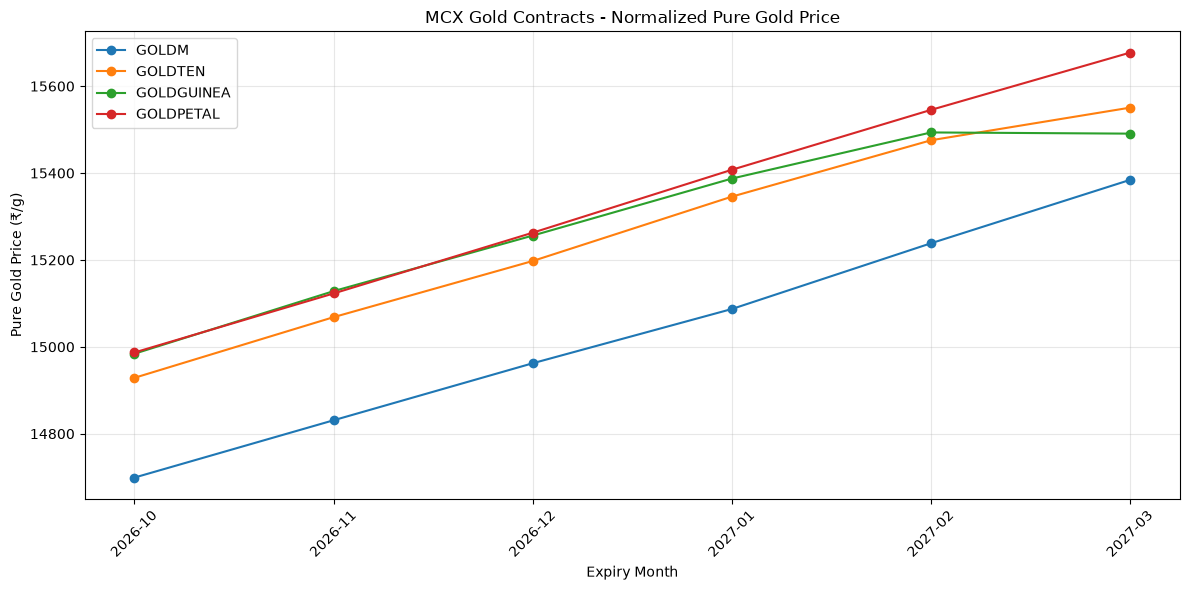

In [6]:
# STEP 19: Plot normalized prices across contracts

import matplotlib.pyplot as plt

plot_data = (
    price_pivot
    .sort_values("Expiry Month")
    .copy()
)

plt.figure(figsize=(12, 6))

for contract in [
    "GOLDM",
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL"
]:

    plt.plot(
        plot_data["Expiry Month"].astype(str),
        plot_data[contract],
        marker="o",
        label=contract
    )

plt.title(
    "MCX Gold Contracts - Normalized Pure Gold Price"
)

plt.xlabel("Expiry Month")

plt.ylabel(
    "Pure Gold Price (₹/g)"
)

plt.xticks(rotation=45)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [8]:
# STEP 20: Calculate relative pricing spreads

spread_data = price_pivot.copy()

# Absolute price spread
spread_data["Spread_TEN_GUINEA"] = (
    spread_data["GOLDTEN"]
    - spread_data["GOLDGUINEA"]
)

# Percentage spread relative to GOLDGUINEA
spread_data["Spread_%_TEN_GUINEA"] = (
    spread_data["Spread_TEN_GUINEA"]
    / spread_data["GOLDGUINEA"]
) * 100

# GOLDTEN vs GOLDPETAL
spread_data["Spread_TEN_PETAL"] = (
    spread_data["GOLDTEN"]
    - spread_data["GOLDPETAL"]
)

spread_data["Spread_%_TEN_PETAL"] = (
    spread_data["Spread_TEN_PETAL"]
    / spread_data["GOLDPETAL"]
) * 100

# GOLDGUINEA vs GOLDPETAL
spread_data["Spread_GUINEA_PETAL"] = (
    spread_data["GOLDGUINEA"]
    - spread_data["GOLDPETAL"]
)

spread_data["Spread_%_GUINEA_PETAL"] = (
    spread_data["Spread_GUINEA_PETAL"]
    / spread_data["GOLDPETAL"]
) * 100

print("Spread calculation completed!")

print("\nSpread analysis:")

print(
    spread_data[
        [
            "Date",
            "Expiry Month",
            "GOLDTEN",
            "GOLDGUINEA",
            "Spread_TEN_GUINEA",
            "Spread_%_TEN_GUINEA",
            "Spread_TEN_PETAL",
            "Spread_%_TEN_PETAL",
            "Spread_GUINEA_PETAL",
            "Spread_%_GUINEA_PETAL"
        ]
    ].to_string(index=False)
)

Spread calculation completed!

Spread analysis:
      Date Expiry Month    GOLDTEN   GOLDGUINEA  Spread_TEN_GUINEA  Spread_%_TEN_GUINEA  Spread_TEN_PETAL  Spread_%_TEN_PETAL  Spread_GUINEA_PETAL  Spread_%_GUINEA_PETAL
2026-10-01      2026-10 14928.6564 14984.125875         -55.469475            -0.370188          -58.3416           -0.389281            -2.872125              -0.019164
2026-10-01      2026-11 15068.3166 15128.231625         -59.915025            -0.396048          -54.5454           -0.360682             5.369625               0.035507
2026-10-01      2026-12 15197.5872 15256.103625         -58.516425            -0.383561          -65.1348           -0.426757            -6.618375              -0.043363
2026-10-01      2027-01 15345.7389 15387.347250         -41.608350            -0.270406          -61.8381           -0.401349           -20.229750              -0.131297
2026-10-01      2027-02 15475.5090 15493.491000         -17.982000            -0.116062          -69.9

In [9]:
# STEP 21: Create clean relative-value dataset

rv_data = spread_data[
    [
        "Date",
        "Expiry Month",
        "GOLDTEN",
        "GOLDGUINEA",
        "GOLDPETAL",
        "Spread_TEN_GUINEA",
        "Spread_%_TEN_GUINEA",
        "Spread_TEN_PETAL",
        "Spread_%_TEN_PETAL",
        "Spread_GUINEA_PETAL"
    ]
].copy()

# Sort chronologically
rv_data = rv_data.sort_values(
    ["Date", "Expiry Month"]
).reset_index(drop=True)

print("Relative-value dataset created successfully!")

print("\nShape:", rv_data.shape)

print("\nColumns:")
print(rv_data.columns.tolist())

print("\nData:")
print(rv_data.to_string(index=False))

Relative-value dataset created successfully!

Shape: (6, 10)

Columns:
['Date', 'Expiry Month', 'GOLDTEN', 'GOLDGUINEA', 'GOLDPETAL', 'Spread_TEN_GUINEA', 'Spread_%_TEN_GUINEA', 'Spread_TEN_PETAL', 'Spread_%_TEN_PETAL', 'Spread_GUINEA_PETAL']

Data:
      Date Expiry Month    GOLDTEN   GOLDGUINEA  GOLDPETAL  Spread_TEN_GUINEA  Spread_%_TEN_GUINEA  Spread_TEN_PETAL  Spread_%_TEN_PETAL  Spread_GUINEA_PETAL
2026-10-01      2026-10 14928.6564 14984.125875  14986.998         -55.469475            -0.370188          -58.3416           -0.389281            -2.872125
2026-10-01      2026-11 15068.3166 15128.231625  15122.862         -59.915025            -0.396048          -54.5454           -0.360682             5.369625
2026-10-01      2026-12 15197.5872 15256.103625  15262.722         -58.516425            -0.383561          -65.1348           -0.426757            -6.618375
2026-10-01      2027-01 15345.7389 15387.347250  15407.577         -41.608350            -0.270406          -61.8381  

In [10]:
# STEP 22: Save relative-value dataset

PROCESSED_DATA_PATH.mkdir(
    parents=True,
    exist_ok=True
)

output_file = (
    PROCESSED_DATA_PATH
    / "gold_relative_value.csv"
)

rv_data.to_csv(
    output_file,
    index=False
)

print("Saved successfully:")
print(output_file)

Saved successfully:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\gold_relative_value.csv


In [11]:
# STEP 23: Verify processed relative-value dataset

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

file_path = PROCESSED_DATA_PATH / "gold_relative_value.csv"

print("File exists:", file_path.exists())
print("File path:", file_path)

if file_path.exists():
    check_data = pd.read_csv(file_path)

    print("\nShape:", check_data.shape)

    print("\nColumns:")
    print(check_data.columns.tolist())

    print("\nFirst rows:")
    print(check_data.head().to_string(index=False))

File exists: True
File path: c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\gold_relative_value.csv

Shape: (6, 10)

Columns:
['Date', 'Expiry Month', 'GOLDTEN', 'GOLDGUINEA', 'GOLDPETAL', 'Spread_TEN_GUINEA', 'Spread_%_TEN_GUINEA', 'Spread_TEN_PETAL', 'Spread_%_TEN_PETAL', 'Spread_GUINEA_PETAL']

First rows:
      Date Expiry Month    GOLDTEN   GOLDGUINEA  GOLDPETAL  Spread_TEN_GUINEA  Spread_%_TEN_GUINEA  Spread_TEN_PETAL  Spread_%_TEN_PETAL  Spread_GUINEA_PETAL
2026-10-01      2026-10 14928.6564 14984.125875  14986.998         -55.469475            -0.370188          -58.3416           -0.389281            -2.872125
2026-10-01      2026-11 15068.3166 15128.231625  15122.862         -59.915025            -0.396048          -54.5454           -0.360682             5.369625
2026-10-01      2026-12 15197.5872 15256.103625  15262.722         -58.516425            -0.383561          -65.1348           -0.426757            -6.618375
2026-10-01      2027-01 15345.7389 15387.347

In [12]:
# STEP 24: Check available historical Bhavcopy files

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

bhavcopy_files = sorted(
    RAW_DATA_PATH.glob("BhavCopyDateWise_*.xls")
)

print("Total Bhavcopy files:", len(bhavcopy_files))

print("\nAvailable files:")
for file in bhavcopy_files:
    print(" -", file.name)

Total Bhavcopy files: 1

Available files:
 - BhavCopyDateWise_01102026.xls


In [13]:
# STEP 26: Verify detailed Bhavcopy structure

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

file_path = RAW_DATA_PATH / "BhavCopyDateWise_01102026.xls"

tables = pd.read_html(file_path)

print("Number of tables:", len(tables))

df_check = tables[0].copy()

print("\nShape:", df_check.shape)

print("\nColumns:")
for col in df_check.columns:
    print(" -", col)

print("\nFirst 5 rows:")
display(df_check.head())

Number of tables: 1

Shape: (15104, 15)

Columns:
 - Date
 - Instrument Name
 - Symbol
 - Expiry Date
 - Option Type
 - Strike Price
 - Open
 - High
 - Low
 - Close
 - Previous Close
 - Volume(Lots)
 - Volume(In 000's)
 - Value(Lacs)
 - Open Interest(Lots)

First 5 rows:


,Date,Instrument Name,Symbol,Expiry Date,Option Type,Strike Price,Open,High,Low,Close,Previous Close,Volume(Lots),Volume(In 000's),Value(Lacs),Open Interest(Lots)
0,01 Oct 2026,FUTCOM,ALUMINI,30OCT2026,-,0,340.60,341.20,337.00,337.65,341.80,3096,3096.000 KGS,10481.59,2635
1,01 Oct 2026,FUTCOM,ALUMINI,30NOV2026,-,0,339.90,340.85,336.15,337.15,341.45,479,479.000 KGS,1620.09,613
2,01 Oct 2026,FUTCOM,ALUMINI,31DEC2026,-,0,338.25,338.25,338.25,338.25,341.10,1,1.000 KGS,3.38,1
3,01 Oct 2026,FUTCOM,ALUMINI,29JAN2027,-,0,NaN,NaN,NaN,327.35,327.35,0,0.000 KGS,0.00,0
4,01 Oct 2026,FUTCOM,ALUMINI,31MAR2027,-,0,NaN,NaN,NaN,340.05,340.05,0,0.000 KGS,0.00,0


In [14]:
# STEP 27: Automatic historical Bhavcopy processor

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"
CLEANED_DATA_PATH = PROJECT_ROOT / "data" / "cleaned"

TARGET_CONTRACTS = [
    "GOLDM",
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL"
]


def read_mcx_bhavcopy(file_path):

    # Read HTML-based MCX Bhavcopy
    tables = pd.read_html(file_path)

    if len(tables) == 0:
        raise ValueError(f"No table found in {file_path.name}")

    df = tables[0].copy()

    # Clean column names
    df.columns = [str(col).strip() for col in df.columns]

    # Clean text columns
    df["Instrument Name"] = (
        df["Instrument Name"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df["Symbol"] = (
        df["Symbol"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # Keep only gold futures
    gold = df[
        (df["Instrument Name"] == "FUTCOM") &
        (df["Symbol"].isin(TARGET_CONTRACTS))
    ].copy()

    # Convert dates
    gold["Date"] = pd.to_datetime(
        gold["Date"],
        errors="coerce"
    )

    gold["Expiry Date Parsed"] = pd.to_datetime(
        gold["Expiry Date"],
        format="%d%b%Y",
        errors="coerce"
    )

    # Convert numeric columns
    numeric_columns = [
        "Open",
        "High",
        "Low",
        "Close",
        "Previous Close",
        "Volume(Lots)",
        "Volume(In 000's)",
        "Value(Lacs)",
        "Open Interest(Lots)"
    ]

    for col in numeric_columns:
        if col in gold.columns:
            gold[col] = pd.to_numeric(
                gold[col],
                errors="coerce"
            )

    return gold


# Find all detailed Bhavcopy files
bhavcopy_files = sorted(
    RAW_DATA_PATH.glob("BhavCopyDateWise_*.xls")
)

print("Bhavcopy files found:", len(bhavcopy_files))

all_data = []

for file in bhavcopy_files:

    try:
        data = read_mcx_bhavcopy(file)

        # Check that data was actually found
        if len(data) == 0:
            print("WARNING:", file.name, "→ No target gold futures found")
            continue

        all_data.append(data)

        print(
            "Loaded:",
            file.name,
            "| Date:",
            data["Date"].dropna().dt.date.unique(),
            "| Rows:",
            len(data)
        )

    except Exception as e:
        print(
            "ERROR:",
            file.name,
            "|",
            str(e)
        )


# Combine all dates
if len(all_data) > 0:

    historical_gold = pd.concat(
        all_data,
        ignore_index=True
    )

    historical_gold = historical_gold.sort_values(
        ["Date", "Symbol", "Expiry Date Parsed"]
    ).reset_index(drop=True)

else:

    historical_gold = pd.DataFrame()


print("\n===================================")
print("HISTORICAL DATA SUMMARY")
print("===================================")

print("Total rows:", len(historical_gold))

if len(historical_gold) > 0:

    print(
        "Date range:",
        historical_gold["Date"].min().date(),
        "to",
        historical_gold["Date"].max().date()
    )

    print(
        "Trading dates:",
        historical_gold["Date"].dt.date.nunique()
    )

    print("\nRows by contract:")
    print(
        historical_gold["Symbol"]
        .value_counts()
        .sort_index()
    )

    print("\nRows by date:")
    print(
        historical_gold
        .groupby("Date")
        .size()
        .head(20)
    )

Bhavcopy files found: 1
Loaded: BhavCopyDateWise_01102026.xls | Date: [datetime.date(2026, 10, 1)] | Rows: 24

HISTORICAL DATA SUMMARY
Total rows: 24
Date range: 2026-10-01 to 2026-10-01
Trading dates: 1

Rows by contract:
Symbol
GOLDGUINEA    6
GOLDM         6
GOLDPETAL     6
GOLDTEN       6
Name: count, dtype: int64

Rows by date:
Date
2026-10-01    24
dtype: int64


In [15]:
# STEP 28: Normalize gold prices

# Contract quotation weights
quotation_weight = {
    "GOLDM": 10,
    "GOLDTEN": 10,
    "GOLDGUINEA": 8,
    "GOLDPETAL": 1
}

# Purity factors
purity_factor = {
    "GOLDM": 0.995,
    "GOLDTEN": 0.999,
    "GOLDGUINEA": 0.999,
    "GOLDPETAL": 0.999
}

# Add quotation weight
historical_gold["Quotation Weight (g)"] = (
    historical_gold["Symbol"]
    .map(quotation_weight)
)

# Add purity
historical_gold["Purity Factor"] = (
    historical_gold["Symbol"]
    .map(purity_factor)
)

# Calculate pure-gold price per gram
historical_gold["Pure Gold Price (₹/g)"] = (
    historical_gold["Close"]
    / historical_gold["Quotation Weight (g)"]
    * historical_gold["Purity Factor"]
)

# Display important columns
display_columns = [
    "Date",
    "Symbol",
    "Expiry Date Parsed",
    "Close",
    "Quotation Weight (g)",
    "Purity Factor",
    "Pure Gold Price (₹/g)",
    "Volume(Lots)",
    "Open Interest(Lots)"
]

print("Normalized historical dataset:")
display(
    historical_gold[display_columns]
    .sort_values(["Date", "Expiry Date Parsed", "Symbol"])
    .reset_index(drop=True)
)

Normalized historical dataset:


,Date,Symbol,Expiry Date Parsed,Close,Quotation Weight (g),Purity Factor,Pure Gold Price (₹/g),Volume(Lots),Open Interest(Lots)
0,2026-10-01,GOLDM,2026-10-05,147729.0,10,0.995,14699.035500,1722,1589
1,2026-10-01,GOLDGUINEA,2026-10-30,119993.0,8,0.999,14984.125875,11305,13525
2,2026-10-01,GOLDPETAL,2026-10-30,15002.0,1,0.999,14986.998000,239269,198482
3,2026-10-01,GOLDTEN,2026-10-30,149436.0,10,0.999,14928.656400,22286,29866
4,2026-10-01,GOLDM,2026-11-05,149055.0,10,0.995,14830.972500,41017,42632
5,2026-10-01,GOLDGUINEA,2026-11-30,121147.0,8,0.999,15128.231625,3323,7551
6,2026-10-01,GOLDPETAL,2026-11-30,15138.0,1,0.999,15122.862000,85108,124644
7,2026-10-01,GOLDTEN,2026-11-30,150834.0,10,0.999,15068.316600,11846,15703
8,2026-10-01,GOLDM,2026-12-04,150374.0,10,0.995,14962.213000,14954,14420
9,2026-10-01,GOLDGUINEA,2026-12-31,122171.0,8,0.999,15256.103625,928,3301


In [16]:
# STEP 29: Save normalized historical dataset

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

PROCESSED_DATA_PATH.mkdir(
    parents=True,
    exist_ok=True
)

output_file = (
    PROCESSED_DATA_PATH
    / "historical_gold_normalized.csv"
)

historical_gold.to_csv(
    output_file,
    index=False
)

print("Normalized historical dataset saved successfully!")
print("\nFile:")
print(output_file)

print("\nRows:", len(historical_gold))
print("Columns:", len(historical_gold.columns))

print(
    "\nDate range:",
    historical_gold["Date"].min().date(),
    "to",
    historical_gold["Date"].max().date()
)

Normalized historical dataset saved successfully!

File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\historical_gold_normalized.csv

Rows: 24
Columns: 19

Date range: 2026-10-01 to 2026-10-01


In [17]:
# STEP 30: Check dates inside the detailed Bhavcopy

print("Unique dates in detailed Bhavcopy:")

dates = (
    historical_gold["Date"]
    .dropna()
    .dt.normalize()
    .drop_duplicates()
    .sort_values()
)

for date in dates:
    print(" -", date.date())

print("\nTotal unique dates:", len(dates))

Unique dates in detailed Bhavcopy:
 - 2026-10-01

Total unique dates: 1


In [18]:
# STEP 31: Create liquidity classification

import numpy as np

# Make sure missing volume/OI are treated as zero for classification
historical_gold["Volume(Lots)"] = (
    pd.to_numeric(
        historical_gold["Volume(Lots)"],
        errors="coerce"
    )
    .fillna(0)
)

historical_gold["Open Interest(Lots)"] = (
    pd.to_numeric(
        historical_gold["Open Interest(Lots)"],
        errors="coerce"
    )
    .fillna(0)
)

# Liquidity classification based on Volume
def classify_liquidity(volume):
    
    if volume == 0:
        return "NO_ACTIVITY"
    
    elif volume < 500:
        return "LOW"
    
    elif volume < 5000:
        return "MEDIUM"
    
    else:
        return "HIGH"


historical_gold["Liquidity"] = (
    historical_gold["Volume(Lots)"]
    .apply(classify_liquidity)
)

# Display results
liquidity_columns = [
    "Date",
    "Symbol",
    "Expiry Date Parsed",
    "Close",
    "Pure Gold Price (₹/g)",
    "Volume(Lots)",
    "Open Interest(Lots)",
    "Liquidity"
]

print("Liquidity classification:")
display(
    historical_gold[
        liquidity_columns
    ]
    .sort_values(
        ["Date", "Expiry Date Parsed", "Symbol"]
    )
    .reset_index(drop=True)
)

print("\nLiquidity distribution:")
print(
    historical_gold["Liquidity"]
    .value_counts()
)

Liquidity classification:


,Date,Symbol,Expiry Date Parsed,Close,Pure Gold Price (₹/g),Volume(Lots),Open Interest(Lots),Liquidity
0,2026-10-01,GOLDM,2026-10-05,147729.0,14699.035500,1722,1589,MEDIUM
1,2026-10-01,GOLDGUINEA,2026-10-30,119993.0,14984.125875,11305,13525,HIGH
2,2026-10-01,GOLDPETAL,2026-10-30,15002.0,14986.998000,239269,198482,HIGH
3,2026-10-01,GOLDTEN,2026-10-30,149436.0,14928.656400,22286,29866,HIGH
4,2026-10-01,GOLDM,2026-11-05,149055.0,14830.972500,41017,42632,HIGH
5,2026-10-01,GOLDGUINEA,2026-11-30,121147.0,15128.231625,3323,7551,MEDIUM
6,2026-10-01,GOLDPETAL,2026-11-30,15138.0,15122.862000,85108,124644,HIGH
7,2026-10-01,GOLDTEN,2026-11-30,150834.0,15068.316600,11846,15703,HIGH
8,2026-10-01,GOLDM,2026-12-04,150374.0,14962.213000,14954,14420,HIGH
9,2026-10-01,GOLDGUINEA,2026-12-31,122171.0,15256.103625,928,3301,MEDIUM



Liquidity distribution:
Liquidity
HIGH           9
MEDIUM         8
LOW            6
NO_ACTIVITY    1
Name: count, dtype: int64


In [19]:
# STEP 32: Create clean analysis dataset

analysis_columns = [
    "Date",
    "Symbol",
    "Expiry Date Parsed",
    "Close",
    "Previous Close",
    "Quotation Weight (g)",
    "Purity Factor",
    "Pure Gold Price (₹/g)",
    "Volume(Lots)",
    "Open Interest(Lots)",
    "Liquidity"
]

gold_analysis = (
    historical_gold[analysis_columns]
    .copy()
    .sort_values(
        ["Date", "Expiry Date Parsed", "Symbol"]
    )
    .reset_index(drop=True)
)

print("Clean analysis dataset created successfully!")

print("\nShape:", gold_analysis.shape)

print("\nColumns:")
for col in gold_analysis.columns:
    print(" -", col)

print("\nMissing values:")
print(
    gold_analysis.isna().sum()
)

print("\nFirst 10 rows:")
display(
    gold_analysis.head(10)
)

Clean analysis dataset created successfully!

Shape: (24, 11)

Columns:
 - Date
 - Symbol
 - Expiry Date Parsed
 - Close
 - Previous Close
 - Quotation Weight (g)
 - Purity Factor
 - Pure Gold Price (₹/g)
 - Volume(Lots)
 - Open Interest(Lots)
 - Liquidity

Missing values:
Date                     0
Symbol                   0
Expiry Date Parsed       0
Close                    0
Previous Close           0
Quotation Weight (g)     0
Purity Factor            0
Pure Gold Price (₹/g)    0
Volume(Lots)             0
Open Interest(Lots)      0
Liquidity                0
dtype: int64

First 10 rows:


,Date,Symbol,Expiry Date Parsed,Close,Previous Close,Quotation Weight (g),Purity Factor,Pure Gold Price (₹/g),Volume(Lots),Open Interest(Lots),Liquidity
0,2026-10-01,GOLDM,2026-10-05,147729.0,146151.0,10,0.995,14699.035500,1722,1589,MEDIUM
1,2026-10-01,GOLDGUINEA,2026-10-30,119993.0,119207.0,8,0.999,14984.125875,11305,13525,HIGH
2,2026-10-01,GOLDPETAL,2026-10-30,15002.0,14893.0,1,0.999,14986.998000,239269,198482,HIGH
3,2026-10-01,GOLDTEN,2026-10-30,149436.0,148322.0,10,0.999,14928.656400,22286,29866,HIGH
4,2026-10-01,GOLDM,2026-11-05,149055.0,147908.0,10,0.995,14830.972500,41017,42632,HIGH
5,2026-10-01,GOLDGUINEA,2026-11-30,121147.0,120417.0,8,0.999,15128.231625,3323,7551,MEDIUM
6,2026-10-01,GOLDPETAL,2026-11-30,15138.0,15033.0,1,0.999,15122.862000,85108,124644,HIGH
7,2026-10-01,GOLDTEN,2026-11-30,150834.0,149643.0,10,0.999,15068.316600,11846,15703,HIGH
8,2026-10-01,GOLDM,2026-12-04,150374.0,149125.0,10,0.995,14962.213000,14954,14420,HIGH
9,2026-10-01,GOLDGUINEA,2026-12-31,122171.0,121434.0,8,0.999,15256.103625,928,3301,MEDIUM


In [20]:
# STEP 33: Exact-expiry relative pricing comparison

# Pivot normalized price by actual expiry date
exact_price_pivot = (
    gold_analysis
    .pivot_table(
        index=["Date", "Expiry Date Parsed"],
        columns="Symbol",
        values="Pure Gold Price (₹/g)",
        aggfunc="first"
    )
    .reset_index()
)

# Remove column-name label
exact_price_pivot.columns.name = None

# Calculate pairwise differences
exact_price_pivot["TEN_vs_GUINEA"] = (
    exact_price_pivot["GOLDTEN"]
    - exact_price_pivot["GOLDGUINEA"]
)

exact_price_pivot["TEN_vs_PETAL"] = (
    exact_price_pivot["GOLDTEN"]
    - exact_price_pivot["GOLDPETAL"]
)

exact_price_pivot["GUINEA_vs_PETAL"] = (
    exact_price_pivot["GOLDGUINEA"]
    - exact_price_pivot["GOLDPETAL"]
)

print("Exact-expiry comparison created!")

print("\nShape:", exact_price_pivot.shape)

display(
    exact_price_pivot
)

Exact-expiry comparison created!

Shape: (12, 9)


,Date,Expiry Date Parsed,GOLDGUINEA,GOLDM,GOLDPETAL,GOLDTEN,TEN_vs_GUINEA,TEN_vs_PETAL,GUINEA_vs_PETAL
0,2026-10-01,2026-10-05,NaN,14699.0355,NaN,NaN,NaN,NaN,NaN
1,2026-10-01,2026-10-30,14984.125875,NaN,14986.998,14928.6564,-55.469475,-58.3416,-2.872125
2,2026-10-01,2026-11-05,NaN,14830.9725,NaN,NaN,NaN,NaN,NaN
3,2026-10-01,2026-11-30,15128.231625,NaN,15122.862,15068.3166,-59.915025,-54.5454,5.369625
4,2026-10-01,2026-12-04,NaN,14962.2130,NaN,NaN,NaN,NaN,NaN
5,2026-10-01,2026-12-31,15256.103625,NaN,15262.722,15197.5872,-58.516425,-65.1348,-6.618375
6,2026-10-01,2027-01-05,NaN,15087.0855,NaN,NaN,NaN,NaN,NaN
7,2026-10-01,2027-01-29,15387.347250,NaN,15407.577,15345.7389,-41.608350,-61.8381,-20.229750
8,2026-10-01,2027-02-05,NaN,15238.4250,NaN,NaN,NaN,NaN,NaN
9,2026-10-01,2027-02-26,15493.491000,NaN,15545.439,15475.5090,-17.982000,-69.9300,-51.948000


In [22]:
# STEP 34: Calculate exact-expiry percentage spreads

exact_spread_data = exact_price_pivot.copy()

# TEN vs GUINEA
exact_spread_data["TEN_vs_GUINEA_%"] = (
    (
        exact_spread_data["GOLDTEN"]
        - exact_spread_data["GOLDGUINEA"]
    )
    / exact_spread_data["GOLDGUINEA"]
) * 100

# TEN vs PETAL
exact_spread_data["TEN_vs_PETAL_%"] = (
    (
        exact_spread_data["GOLDTEN"]
        - exact_spread_data["GOLDPETAL"]
    )
    / exact_spread_data["GOLDPETAL"]
) * 100

# GUINEA vs PETAL
exact_spread_data["GUINEA_vs_PETAL_%"] = (
    (
        exact_spread_data["GOLDGUINEA"]
        - exact_spread_data["GOLDPETAL"]
    )
    / exact_spread_data["GOLDPETAL"]
) * 100

In [23]:
# Keep rows where all three comparable contracts are available

same_expiry_data = exact_spread_data[
    exact_spread_data[
        [
            "GOLDTEN",
            "GOLDGUINEA",
            "GOLDPETAL"
        ]
    ].notna().all(axis=1)
].copy()

print("Same-expiry comparison rows:", len(same_expiry_data))

display_columns = [
    "Date",
    "Expiry Date Parsed",
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL",
    "TEN_vs_GUINEA",
    "TEN_vs_GUINEA_%",
    "TEN_vs_PETAL",
    "TEN_vs_PETAL_%",
    "GUINEA_vs_PETAL",
    "GUINEA_vs_PETAL_%"
]

display(
    same_expiry_data[display_columns]
    .reset_index(drop=True)
)

Same-expiry comparison rows: 6


,Date,Expiry Date Parsed,GOLDTEN,GOLDGUINEA,GOLDPETAL,TEN_vs_GUINEA,TEN_vs_GUINEA_%,TEN_vs_PETAL,TEN_vs_PETAL_%,GUINEA_vs_PETAL,GUINEA_vs_PETAL_%
0,2026-10-01,2026-10-30,14928.6564,14984.125875,14986.998,-55.469475,-0.370188,-58.3416,-0.389281,-2.872125,-0.019164
1,2026-10-01,2026-11-30,15068.3166,15128.231625,15122.862,-59.915025,-0.396048,-54.5454,-0.360682,5.369625,0.035507
2,2026-10-01,2026-12-31,15197.5872,15256.103625,15262.722,-58.516425,-0.383561,-65.1348,-0.426757,-6.618375,-0.043363
3,2026-10-01,2027-01-29,15345.7389,15387.347250,15407.577,-41.608350,-0.270406,-61.8381,-0.401349,-20.229750,-0.131297
4,2026-10-01,2027-02-26,15475.5090,15493.491000,15545.439,-17.982000,-0.116062,-69.9300,-0.449843,-51.948000,-0.334169
5,2026-10-01,2027-03-31,15550.6338,15490.743750,15677.307,59.890050,0.386618,-126.6732,-0.808004,-186.563250,-1.190021


In [24]:
# STEP 35: Save exact-expiry relative-value dataset

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed"

output_file = (
    PROCESSED_DATA_PATH
    / "exact_expiry_relative_value.csv"
)

same_expiry_data.to_csv(
    output_file,
    index=False
)

print("Exact-expiry relative-value dataset saved successfully!")

print("\nFile:")
print(output_file)

print("\nRows:", len(same_expiry_data))
print("Columns:", len(same_expiry_data.columns))

Exact-expiry relative-value dataset saved successfully!

File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\exact_expiry_relative_value.csv

Rows: 6
Columns: 12


In [25]:
# STEP 36: Verify exact-expiry relative-value dataset

import pandas as pd

file_path = (
    PROCESSED_DATA_PATH
    / "exact_expiry_relative_value.csv"
)

check_data = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("\nShape:", check_data.shape)

print("\nColumns:")
for i, col in enumerate(check_data.columns, 1):
    print(f"{i}. {col}")

print("\nData:")
display(check_data)

Dataset loaded successfully!

Shape: (6, 12)

Columns:
1. Date
2. Expiry Date Parsed
3. GOLDGUINEA
4. GOLDM
5. GOLDPETAL
6. GOLDTEN
7. TEN_vs_GUINEA
8. TEN_vs_PETAL
9. GUINEA_vs_PETAL
10. TEN_vs_GUINEA_%
11. TEN_vs_PETAL_%
12. GUINEA_vs_PETAL_%

Data:


,Date,Expiry Date Parsed,GOLDGUINEA,GOLDM,GOLDPETAL,GOLDTEN,TEN_vs_GUINEA,TEN_vs_PETAL,GUINEA_vs_PETAL,TEN_vs_GUINEA_%,TEN_vs_PETAL_%,GUINEA_vs_PETAL_%
0,2026-10-01,2026-10-30,14984.125875,NaN,14986.998,14928.6564,-55.469475,-58.3416,-2.872125,-0.370188,-0.389281,-0.019164
1,2026-10-01,2026-11-30,15128.231625,NaN,15122.862,15068.3166,-59.915025,-54.5454,5.369625,-0.396048,-0.360682,0.035507
2,2026-10-01,2026-12-31,15256.103625,NaN,15262.722,15197.5872,-58.516425,-65.1348,-6.618375,-0.383561,-0.426757,-0.043363
3,2026-10-01,2027-01-29,15387.347250,NaN,15407.577,15345.7389,-41.608350,-61.8381,-20.229750,-0.270406,-0.401349,-0.131297
4,2026-10-01,2027-02-26,15493.491000,NaN,15545.439,15475.5090,-17.982000,-69.9300,-51.948000,-0.116062,-0.449843,-0.334169
5,2026-10-01,2027-03-31,15490.743750,NaN,15677.307,15550.6338,59.890050,-126.6732,-186.563250,0.386618,-0.808004,-1.190021


In [26]:
# STEP 37: Relative-price dislocation analysis

import pandas as pd

rv = pd.read_csv(
    PROCESSED_DATA_PATH / "exact_expiry_relative_value.csv"
)

# Convert dates
rv["Date"] = pd.to_datetime(rv["Date"])
rv["Expiry Date Parsed"] = pd.to_datetime(rv["Expiry Date Parsed"])

# Absolute spread analysis
spread_columns = [
    "TEN_vs_GUINEA",
    "TEN_vs_PETAL",
    "GUINEA_vs_PETAL"
]

print("RELATIVE-PRICE DISLOCATION ANALYSIS")
print("=" * 60)

for col in spread_columns:
    print(f"\n{col}")
    print(f"Mean spread   : {rv[col].mean():.4f}")
    print(f"Minimum spread: {rv[col].min():.4f}")
    print(f"Maximum spread: {rv[col].max():.4f}")
    print(f"Std deviation : {rv[col].std():.4f}")

print("\n" + "=" * 60)
print("FULL SPREAD DATA")
print("=" * 60)

display(
    rv[
        [
            "Date",
            "Expiry Date Parsed",
            "TEN_vs_GUINEA",
            "TEN_vs_PETAL",
            "GUINEA_vs_PETAL",
            "TEN_vs_GUINEA_%",
            "TEN_vs_PETAL_%",
            "GUINEA_vs_PETAL_%"
        ]
    ]
)

RELATIVE-PRICE DISLOCATION ANALYSIS

TEN_vs_GUINEA
Mean spread   : -28.9335
Minimum spread: -59.9150
Maximum spread: 59.8901
Std deviation : 46.2804

TEN_vs_PETAL
Mean spread   : -72.7438
Minimum spread: -126.6732
Maximum spread: -54.5454
Std deviation : 26.9508

GUINEA_vs_PETAL
Mean spread   : -43.8103
Minimum spread: -186.5633
Maximum spread: 5.3696
Std deviation : 72.7716

FULL SPREAD DATA


,Date,Expiry Date Parsed,TEN_vs_GUINEA,TEN_vs_PETAL,GUINEA_vs_PETAL,TEN_vs_GUINEA_%,TEN_vs_PETAL_%,GUINEA_vs_PETAL_%
0,2026-10-01,2026-10-30,-55.469475,-58.3416,-2.872125,-0.370188,-0.389281,-0.019164
1,2026-10-01,2026-11-30,-59.915025,-54.5454,5.369625,-0.396048,-0.360682,0.035507
2,2026-10-01,2026-12-31,-58.516425,-65.1348,-6.618375,-0.383561,-0.426757,-0.043363
3,2026-10-01,2027-01-29,-41.608350,-61.8381,-20.229750,-0.270406,-0.401349,-0.131297
4,2026-10-01,2027-02-26,-17.982000,-69.9300,-51.948000,-0.116062,-0.449843,-0.334169
5,2026-10-01,2027-03-31,59.890050,-126.6732,-186.563250,0.386618,-0.808004,-1.190021


In [27]:
# STEP 38: Rank observed relative-price dislocations

pairs = {
    "TEN_vs_GUINEA_%": "TEN vs GUINEA",
    "TEN_vs_PETAL_%": "TEN vs PETAL",
    "GUINEA_vs_PETAL_%": "GUINEA vs PETAL"
}

dislocations = []

for column, pair_name in pairs.items():
    temp = rv[
        [
            "Date",
            "Expiry Date Parsed",
            column
        ]
    ].copy()

    temp["Pair"] = pair_name
    temp["Absolute Spread %"] = temp[column].abs()

    temp = temp.rename(columns={column: "Spread %"})

    dislocations.append(temp)

dislocation_table = pd.concat(
    dislocations,
    ignore_index=True
)

dislocation_table = dislocation_table.sort_values(
    "Absolute Spread %",
    ascending=False
).reset_index(drop=True)

print("RANKED RELATIVE-PRICE DISLOCATIONS")
print("=" * 70)

display(dislocation_table)

RANKED RELATIVE-PRICE DISLOCATIONS


,Date,Expiry Date Parsed,Spread %,Pair,Absolute Spread %
0,2026-10-01,2027-03-31,-1.190021,GUINEA vs PETAL,1.190021
1,2026-10-01,2027-03-31,-0.808004,TEN vs PETAL,0.808004
2,2026-10-01,2027-02-26,-0.449843,TEN vs PETAL,0.449843
3,2026-10-01,2026-12-31,-0.426757,TEN vs PETAL,0.426757
4,2026-10-01,2027-01-29,-0.401349,TEN vs PETAL,0.401349
5,2026-10-01,2026-11-30,-0.396048,TEN vs GUINEA,0.396048
6,2026-10-01,2026-10-30,-0.389281,TEN vs PETAL,0.389281
7,2026-10-01,2027-03-31,0.386618,TEN vs GUINEA,0.386618
8,2026-10-01,2026-12-31,-0.383561,TEN vs GUINEA,0.383561
9,2026-10-01,2026-10-30,-0.370188,TEN vs GUINEA,0.370188


In [28]:
# STEP 39: Add liquidity information to relative-value analysis

liquidity_data = gold_analysis[
    [
        "Date",
        "Symbol",
        "Expiry Date Parsed",
        "Volume(Lots)",
        "Open Interest(Lots)",
        "Liquidity"
    ]
].copy()

# Keep only the six common-expiry dates
common_expiries = same_expiry_data[
    "Expiry Date Parsed"
].tolist()

liquidity_common = liquidity_data[
    liquidity_data["Expiry Date Parsed"].isin(common_expiries)
].copy()

liquidity_common = liquidity_common.sort_values(
    ["Expiry Date Parsed", "Symbol"]
).reset_index(drop=True)

print("LIQUIDITY OF COMMON-EXPIRY CONTRACTS")
print("=" * 70)

display(liquidity_common)

LIQUIDITY OF COMMON-EXPIRY CONTRACTS


,Date,Symbol,Expiry Date Parsed,Volume(Lots),Open Interest(Lots),Liquidity
0,2026-10-01,GOLDGUINEA,2026-10-30,11305,13525,HIGH
1,2026-10-01,GOLDPETAL,2026-10-30,239269,198482,HIGH
2,2026-10-01,GOLDTEN,2026-10-30,22286,29866,HIGH
3,2026-10-01,GOLDGUINEA,2026-11-30,3323,7551,MEDIUM
4,2026-10-01,GOLDPETAL,2026-11-30,85108,124644,HIGH
5,2026-10-01,GOLDTEN,2026-11-30,11846,15703,HIGH
6,2026-10-01,GOLDGUINEA,2026-12-31,928,3301,MEDIUM
7,2026-10-01,GOLDPETAL,2026-12-31,26538,52214,HIGH
8,2026-10-01,GOLDTEN,2026-12-31,2601,6801,MEDIUM
9,2026-10-01,GOLDGUINEA,2027-01-29,256,1753,LOW


In [29]:
# STEP 40: Apply basic liquidity filter

# Contracts used for exact-expiry comparison
COMPARABLE_CONTRACTS = [
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL"
]

# Keep only rows with actual trading activity
liquid_contracts = gold_analysis[
    (gold_analysis["Symbol"].isin(COMPARABLE_CONTRACTS)) &
    (gold_analysis["Volume(Lots)"] > 0)
].copy()

# Find expiry dates where all three contracts traded
liquid_expiry_counts = (
    liquid_contracts
    .groupby(["Date", "Expiry Date Parsed"])["Symbol"]
    .nunique()
    .reset_index(name="Contract_Count")
)

liquid_expiries = liquid_expiry_counts[
    liquid_expiry_counts["Contract_Count"] == 3
][
    ["Date", "Expiry Date Parsed"]
]

# Filter the relative-value dataset
liquid_rv = rv.merge(
    liquid_expiries,
    on=["Date", "Expiry Date Parsed"],
    how="inner"
)

print("LIQUIDITY-FILTERED RELATIVE-VALUE DATASET")
print("=" * 70)

print("\nRows before filter:", len(rv))
print("Rows after filter :", len(liquid_rv))

print("\nFiltered expiries:")
display(
    liquid_rv[
        [
            "Date",
            "Expiry Date Parsed",
            "TEN_vs_GUINEA_%",
            "TEN_vs_PETAL_%",
            "GUINEA_vs_PETAL_%"
        ]
    ]
)

LIQUIDITY-FILTERED RELATIVE-VALUE DATASET

Rows before filter: 6
Rows after filter : 5

Filtered expiries:


,Date,Expiry Date Parsed,TEN_vs_GUINEA_%,TEN_vs_PETAL_%,GUINEA_vs_PETAL_%
0,2026-10-01,2026-10-30,-0.370188,-0.389281,-0.019164
1,2026-10-01,2026-11-30,-0.396048,-0.360682,0.035507
2,2026-10-01,2026-12-31,-0.383561,-0.426757,-0.043363
3,2026-10-01,2027-01-29,-0.270406,-0.401349,-0.131297
4,2026-10-01,2027-02-26,-0.116062,-0.449843,-0.334169


In [30]:
# STEP 41: Save liquidity-filtered relative-value dataset

output_file = (
    PROCESSED_DATA_PATH
    / "liquidity_filtered_relative_value.csv"
)

liquid_rv.to_csv(
    output_file,
    index=False
)

print("Liquidity-filtered dataset saved successfully!")

print("\nFile:")
print(output_file)

print("\nRows:", len(liquid_rv))
print("Columns:", len(liquid_rv.columns))

print("\nDate range:")
print(
    liquid_rv["Date"].min().date(),
    "to",
    liquid_rv["Date"].max().date()
)

Liquidity-filtered dataset saved successfully!

File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\liquidity_filtered_relative_value.csv

Rows: 5
Columns: 12

Date range:
2026-10-01 to 2026-10-01


In [31]:
# STEP 42: Check available MCX Bhavcopy files

from pathlib import Path
import pandas as pd

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

bhavcopy_files = sorted(
    RAW_DATA_PATH.glob("BhavCopyDateWise_*.xls")
)

print("MCX Bhavcopy files available:", len(bhavcopy_files))
print("=" * 70)

file_summary = []

for file in bhavcopy_files:
    try:
        data = read_mcx_bhavcopy(file)

        dates = (
            data["Date"]
            .dropna()
            .dt.normalize()
            .unique()
        )

        file_summary.append({
            "File": file.name,
            "Date": dates[0].date() if len(dates) == 1 else dates,
            "Rows": len(data)
        })

    except Exception as e:
        file_summary.append({
            "File": file.name,
            "Date": "ERROR",
            "Rows": str(e)
        })

file_summary = pd.DataFrame(file_summary)

display(file_summary)

MCX Bhavcopy files available: 1


,File,Date,Rows
0,BhavCopyDateWise_01102026.xls,2026-10-01,24


In [32]:
# STEP 43: Check all downloaded MCX Bhavcopy files

from pathlib import Path
import pandas as pd

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

bhavcopy_files = sorted(
    RAW_DATA_PATH.glob("BhavCopyDateWise_*.xls")
)

print("Total Bhavcopy files found:", len(bhavcopy_files))
print("=" * 80)

results = []

for file in bhavcopy_files:

    try:
        data = read_mcx_bhavcopy(file)

        if len(data) > 0:
            dates = (
                data["Date"]
                .dropna()
                .dt.normalize()
                .unique()
            )

            date_value = (
                dates[0].date()
                if len(dates) == 1
                else str(dates)
            )

        else:
            date_value = "No target gold contracts"

        results.append({
            "File": file.name,
            "Date": date_value,
            "Gold Rows": len(data),
            "Status": "OK" if len(data) > 0 else "NO GOLD DATA"
        })

    except Exception as e:

        results.append({
            "File": file.name,
            "Date": "ERROR",
            "Gold Rows": 0,
            "Status": str(e)
        })

file_check = pd.DataFrame(results)

display(file_check)

print("\nSummary")
print("=" * 80)
print("Files found:", len(file_check))
print(
    "Files with gold data:",
    (file_check["Gold Rows"] > 0).sum()
)
print(
    "Files without gold data:",
    (file_check["Gold Rows"] == 0).sum()
)

Total Bhavcopy files found: 14


,File,Date,Gold Rows,Status
0,BhavCopyDateWise_01102026.xls,2026-10-01,24,OK
1,BhavCopyDateWise_14092026.xls,2026-09-14,24,OK
2,BhavCopyDateWise_15092026.xls,2026-09-15,24,OK
3,BhavCopyDateWise_16092026.xls,2026-09-16,24,OK
4,BhavCopyDateWise_17092026.xls,2026-09-17,24,OK
5,BhavCopyDateWise_18092026.xls,2026-09-18,24,OK
6,BhavCopyDateWise_21092026.xls,2026-09-21,24,OK
7,BhavCopyDateWise_22092026.xls,2026-09-22,24,OK
8,BhavCopyDateWise_23092026.xls,2026-09-23,24,OK
9,BhavCopyDateWise_24092026.xls,2026-09-24,24,OK



Summary
Files found: 14
Files with gold data: 14
Files without gold data: 0


In [33]:
# STEP 44: Build the complete historical gold futures dataset

import pandas as pd

all_data = []

for file in bhavcopy_files:
    data = read_mcx_bhavcopy(file)

    if len(data) > 0:
        all_data.append(data)

historical_gold = (
    pd.concat(all_data, ignore_index=True)
    .sort_values(
        ["Date", "Symbol", "Expiry Date Parsed"]
    )
    .reset_index(drop=True)
)

print("HISTORICAL GOLD FUTURES DATASET")
print("=" * 70)

print("\nTotal rows:", len(historical_gold))

print(
    "Date range:",
    historical_gold["Date"].min().date(),
    "to",
    historical_gold["Date"].max().date()
)

print(
    "Trading dates:",
    historical_gold["Date"].dt.normalize().nunique()
)

print("\nRows by contract:")
display(
    historical_gold["Symbol"].value_counts().sort_index()
)

print("\nRows by date:")
display(
    historical_gold.groupby(
        historical_gold["Date"].dt.date
    ).size()
)

print("\nMissing values:")
display(
    historical_gold.isna().sum()
)

HISTORICAL GOLD FUTURES DATASET

Total rows: 336
Date range: 2026-09-14 to 2026-10-01
Trading dates: 14

Rows by contract:


Symbol
GOLDGUINEA    84
GOLDM         84
GOLDPETAL     84
GOLDTEN       84
Name: count, dtype: int64


Rows by date:


Date
2026-09-14    24
2026-09-15    24
2026-09-16    24
2026-09-17    24
2026-09-18    24
2026-09-21    24
2026-09-22    24
2026-09-23    24
2026-09-24    24
2026-09-25    24
2026-09-28    24
2026-09-29    24
2026-09-30    24
2026-10-01    24
dtype: int64


Missing values:


Date                     0
Instrument Name          0
Symbol                   0
Expiry Date              0
Option Type              0
Strike Price             0
Open                     1
High                     1
Low                      1
Close                    0
Previous Close           0
Volume(Lots)             0
Volume(In 000's)       336
Value(Lacs)              0
Open Interest(Lots)      0
Expiry Date Parsed       0
dtype: int64

In [34]:
# STEP 45: Normalize historical gold prices

quotation_weight = {
    "GOLDM": 10,
    "GOLDTEN": 10,
    "GOLDGUINEA": 8,
    "GOLDPETAL": 1
}

purity_factor = {
    "GOLDM": 0.995,
    "GOLDTEN": 0.999,
    "GOLDGUINEA": 0.999,
    "GOLDPETAL": 0.999
}

historical_gold["Quotation Weight (g)"] = (
    historical_gold["Symbol"].map(quotation_weight)
)

historical_gold["Purity Factor"] = (
    historical_gold["Symbol"].map(purity_factor)
)

historical_gold["Pure Gold Price (₹/g)"] = (
    historical_gold["Close"]
    / historical_gold["Quotation Weight (g)"]
    * historical_gold["Purity Factor"]
)

print("NORMALIZATION COMPLETED")
print("=" * 70)

print("\nRows:", len(historical_gold))

print("\nMissing normalized prices:")
print(
    historical_gold["Pure Gold Price (₹/g)"].isna().sum()
)

print("\nSample normalized data:")

display(
    historical_gold[
        [
            "Date",
            "Symbol",
            "Expiry Date Parsed",
            "Close",
            "Quotation Weight (g)",
            "Purity Factor",
            "Pure Gold Price (₹/g)"
        ]
    ].head(12)
)

NORMALIZATION COMPLETED

Rows: 336

Missing normalized prices:
0

Sample normalized data:


,Date,Symbol,Expiry Date Parsed,Close,Quotation Weight (g),Purity Factor,Pure Gold Price (₹/g)
0,2026-09-14,GOLDGUINEA,2026-09-30,121569.0,8,0.999,15180.928875
1,2026-09-14,GOLDGUINEA,2026-10-30,122584.0,8,0.999,15307.677000
2,2026-09-14,GOLDGUINEA,2026-11-30,123379.0,8,0.999,15406.952625
3,2026-09-14,GOLDGUINEA,2026-12-31,124694.0,8,0.999,15571.163250
4,2026-09-14,GOLDGUINEA,2027-01-29,125682.0,8,0.999,15694.539750
5,2026-09-14,GOLDGUINEA,2027-02-26,126675.0,8,0.999,15818.540625
6,2026-09-14,GOLDM,2026-10-05,151385.0,10,0.995,15062.807500
7,2026-09-14,GOLDM,2026-11-05,152191.0,10,0.995,15143.004500
8,2026-09-14,GOLDM,2026-12-04,152861.0,10,0.995,15209.669500
9,2026-09-14,GOLDM,2027-01-05,153945.0,10,0.995,15317.527500


In [35]:
# STEP 46: Build historical exact-expiry relative-value dataset

comparable_contracts = [
    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL"
]

comparable_data = historical_gold[
    historical_gold["Symbol"].isin(comparable_contracts)
].copy()

# Pivot prices by exact expiry
historical_exact_pivot = (
    comparable_data
    .pivot_table(
        index=["Date", "Expiry Date Parsed"],
        columns="Symbol",
        values="Pure Gold Price (₹/g)",
        aggfunc="first"
    )
    .reset_index()
)

historical_exact_pivot.columns.name = None

# Keep only expiries where all three contracts exist
historical_same_expiry = historical_exact_pivot[
    historical_exact_pivot[
        comparable_contracts
    ].notna().all(axis=1)
].copy()

# Calculate absolute spreads
historical_same_expiry["TEN_vs_GUINEA"] = (
    historical_same_expiry["GOLDTEN"]
    - historical_same_expiry["GOLDGUINEA"]
)

historical_same_expiry["TEN_vs_PETAL"] = (
    historical_same_expiry["GOLDTEN"]
    - historical_same_expiry["GOLDPETAL"]
)

historical_same_expiry["GUINEA_vs_PETAL"] = (
    historical_same_expiry["GOLDGUINEA"]
    - historical_same_expiry["GOLDPETAL"]
)

# Calculate percentage spreads
historical_same_expiry["TEN_vs_GUINEA_%"] = (
    historical_same_expiry["TEN_vs_GUINEA"]
    / historical_same_expiry["GOLDGUINEA"]
) * 100

historical_same_expiry["TEN_vs_PETAL_%"] = (
    historical_same_expiry["TEN_vs_PETAL"]
    / historical_same_expiry["GOLDPETAL"]
) * 100

historical_same_expiry["GUINEA_vs_PETAL_%"] = (
    historical_same_expiry["GUINEA_vs_PETAL"]
    / historical_same_expiry["GOLDPETAL"]
) * 100

historical_same_expiry = (
    historical_same_expiry
    .sort_values(["Date", "Expiry Date Parsed"])
    .reset_index(drop=True)
)

print("HISTORICAL EXACT-EXPIRY DATASET")
print("=" * 70)

print("\nRows:", len(historical_same_expiry))

print(
    "Trading dates:",
    historical_same_expiry["Date"].nunique()
)

print(
    "Unique expiries:",
    historical_same_expiry["Expiry Date Parsed"].nunique()
)

print("\nDate range:")
print(
    historical_same_expiry["Date"].min().date(),
    "to",
    historical_same_expiry["Date"].max().date()
)

print("\nSample:")
display(historical_same_expiry.head(15))

HISTORICAL EXACT-EXPIRY DATASET

Rows: 84
Trading dates: 14
Unique expiries: 7

Date range:
2026-09-14 to 2026-10-01

Sample:


,Date,Expiry Date Parsed,GOLDGUINEA,GOLDPETAL,GOLDTEN,TEN_vs_GUINEA,TEN_vs_PETAL,GUINEA_vs_PETAL,TEN_vs_GUINEA_%,TEN_vs_PETAL_%,GUINEA_vs_PETAL_%
0,2026-09-14,2026-09-30,15180.928875,15175.809,15141.6432,-39.285675,-34.1658,5.119875,-0.258783,-0.225133,0.033737
1,2026-09-14,2026-10-30,15307.677000,15304.680,15240.3444,-67.332600,-64.3356,2.997000,-0.439862,-0.420366,0.019582
2,2026-09-14,2026-11-30,15406.952625,15387.597,15317.7669,-89.185725,-69.8301,19.355625,-0.578867,-0.453808,0.125787
3,2026-09-14,2026-12-31,15571.163250,15519.465,15419.6649,-151.498350,-99.8001,51.698250,-0.972942,-0.643064,0.333119
4,2026-09-14,2027-01-29,15694.539750,15647.337,15555.8286,-138.711150,-91.5084,47.202750,-0.883818,-0.584818,0.301666
5,2026-09-14,2027-02-26,15818.540625,15789.195,15663.2211,-155.319525,-125.9739,29.345625,-0.981883,-0.797849,0.185859
6,2026-09-15,2026-09-30,15134.225625,15131.853,15096.7881,-37.437525,-35.0649,2.372625,-0.247370,-0.231729,0.015680
7,2026-09-15,2026-10-30,15266.593125,15260.724,15198.2865,-68.306625,-62.4375,5.869125,-0.447425,-0.409139,0.038459
8,2026-09-15,2026-11-30,15357.127500,15341.643,15271.0137,-86.113800,-70.6293,15.484500,-0.560742,-0.460376,0.100931
9,2026-09-15,2026-12-31,15499.859625,15475.509,15383.9007,-115.958925,-91.6083,24.350625,-0.748129,-0.591957,0.157349


In [36]:
# STEP 47: Validate and save historical exact-expiry relative-value dataset

spread_columns = [
    "TEN_vs_GUINEA",
    "TEN_vs_PETAL",
    "GUINEA_vs_PETAL",
    "TEN_vs_GUINEA_%",
    "TEN_vs_PETAL_%",
    "GUINEA_vs_PETAL_%"
]

print("HISTORICAL RELATIVE-VALUE VALIDATION")
print("=" * 70)

print("\nDataset shape:", historical_same_expiry.shape)

print("\nMissing values in spread columns:")
display(
    historical_same_expiry[spread_columns].isna().sum()
)

print("\nRows with any missing spread:")
missing_rows = historical_same_expiry[
    historical_same_expiry[spread_columns].isna().any(axis=1)
]

print("Count:", len(missing_rows))

if len(missing_rows) > 0:
    display(
        missing_rows[
            [
                "Date",
                "Expiry Date Parsed",
                "GOLDTEN",
                "GOLDGUINEA",
                "GOLDPETAL"
            ]
        ]
    )

# Save dataset
output_file = (
    PROCESSED_DATA_PATH
    / "historical_exact_expiry_relative_value.csv"
)

historical_same_expiry.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("Historical relative-value dataset saved successfully!")
print("File:", output_file)
print("Rows:", len(historical_same_expiry))
print("Columns:", len(historical_same_expiry.columns))

HISTORICAL RELATIVE-VALUE VALIDATION

Dataset shape: (84, 11)

Missing values in spread columns:


TEN_vs_GUINEA        0
TEN_vs_PETAL         0
GUINEA_vs_PETAL      0
TEN_vs_GUINEA_%      0
TEN_vs_PETAL_%       0
GUINEA_vs_PETAL_%    0
dtype: int64


Rows with any missing spread:
Count: 0

Historical relative-value dataset saved successfully!
File: c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\historical_exact_expiry_relative_value.csv
Rows: 84
Columns: 11


In [37]:
# STEP 48: Calculate look-ahead-safe rolling z-scores

import numpy as np

zscore_data = historical_same_expiry.copy()

# Sort chronologically within each expiry lifecycle
zscore_data = (
    zscore_data
    .sort_values(["Expiry Date Parsed", "Date"])
    .reset_index(drop=True)
)

# Spread columns to analyze
spread_columns = [
    "TEN_vs_GUINEA_%",
    "TEN_vs_PETAL_%",
    "GUINEA_vs_PETAL_%"
]

# Rolling window
ROLLING_WINDOW = 5

for spread in spread_columns:

    # Historical values BEFORE today's observation
    historical_mean = (
        zscore_data
        .groupby("Expiry Date Parsed")[spread]
        .transform(
            lambda x:
            x.shift(1).rolling(
                ROLLING_WINDOW,
                min_periods=3
            ).mean()
        )
    )

    historical_std = (
        zscore_data
        .groupby("Expiry Date Parsed")[spread]
        .transform(
            lambda x:
            x.shift(1).rolling(
                ROLLING_WINDOW,
                min_periods=3
            ).std()
        )
    )

    zscore_name = spread.replace("%", "Z")

    zscore_data[f"{zscore_name}_Mean"] = historical_mean
    zscore_data[f"{zscore_name}_Std"] = historical_std

    zscore_data[f"{zscore_name}_ZScore"] = (
        zscore_data[spread] - historical_mean
    ) / historical_std

print("LOOK-AHEAD-SAFE Z-SCORES CREATED")
print("=" * 70)

print("Rolling window:", ROLLING_WINDOW)
print("Minimum observations:", 3)

zscore_columns = [
    col for col in zscore_data.columns
    if "ZScore" in col
]

print("\nZ-score columns:")
for col in zscore_columns:
    print("-", col)

print("\nNon-null z-score counts:")
display(
    zscore_data[zscore_columns].notna().sum()
)

print("\nSample:")
display(
    zscore_data[
        [
            "Date",
            "Expiry Date Parsed",
            "TEN_vs_GUINEA_%",
            "TEN_vs_GUINEA_Z_ZScore",
            "TEN_vs_PETAL_%",
            "TEN_vs_PETAL_Z_ZScore",
            "GUINEA_vs_PETAL_%",
            "GUINEA_vs_PETAL_Z_ZScore"
        ]
    ].head(20)
)

LOOK-AHEAD-SAFE Z-SCORES CREATED
Rolling window: 5
Minimum observations: 3

Z-score columns:
- TEN_vs_GUINEA_Z_ZScore
- TEN_vs_PETAL_Z_ZScore
- GUINEA_vs_PETAL_Z_ZScore

Non-null z-score counts:


TEN_vs_GUINEA_Z_ZScore      65
TEN_vs_PETAL_Z_ZScore       65
GUINEA_vs_PETAL_Z_ZScore    65
dtype: int64


Sample:


,Date,Expiry Date Parsed,TEN_vs_GUINEA_%,TEN_vs_GUINEA_Z_ZScore,TEN_vs_PETAL_%,TEN_vs_PETAL_Z_ZScore,GUINEA_vs_PETAL_%,GUINEA_vs_PETAL_Z_ZScore
0,2026-09-14,2026-09-30,-0.258783,NaN,-0.225133,NaN,0.033737,NaN
1,2026-09-15,2026-09-30,-0.247370,NaN,-0.231729,NaN,0.015680,NaN
2,2026-09-16,2026-09-30,-0.260520,NaN,-0.152951,NaN,0.107850,NaN
3,2026-09-17,2026-09-30,-0.247725,1.096452,-0.183594,0.450253,0.064290,0.242980
4,2026-09-18,2026-09-30,-0.135152,16.858931,-0.118217,2.164933,0.016957,-0.953180
5,2026-09-21,2026-09-30,-0.272201,-0.793150,-0.201652,-0.401966,0.070741,0.591951
6,2026-09-22,2026-09-30,-0.197690,0.629655,-0.112969,1.475824,0.084890,0.761461
7,2026-09-23,2026-09-30,-0.306277,-1.478357,-0.207895,-1.381956,0.098684,0.887080
8,2026-09-24,2026-09-30,-0.260624,-0.430305,-0.189740,-0.541998,0.071070,0.127560
9,2026-09-25,2026-09-30,-0.100876,1.964235,-0.098402,1.452708,0.002477,-2.127669


In [38]:
# STEP 49: Create historical dislocation labels

signal_data = zscore_data.copy()

def classify_dislocation(z):
    if pd.isna(z):
        return "INSUFFICIENT HISTORY"
    elif abs(z) >= 3:
        return "EXTREME DISLOCATION"
    elif abs(z) >= 2:
        return "UNUSUAL DISLOCATION"
    else:
        return "NORMAL"


signal_data["TEN_vs_GUINEA_Signal"] = (
    signal_data["TEN_vs_GUINEA_Z_ZScore"]
    .apply(classify_dislocation)
)

signal_data["TEN_vs_PETAL_Signal"] = (
    signal_data["TEN_vs_PETAL_Z_ZScore"]
    .apply(classify_dislocation)
)

signal_data["GUINEA_vs_PETAL_Signal"] = (
    signal_data["GUINEA_vs_PETAL_Z_ZScore"]
    .apply(classify_dislocation)
)

print("HISTORICAL DISLOCATION SIGNALS CREATED")
print("=" * 70)

signal_columns = [
    "TEN_vs_GUINEA_Signal",
    "TEN_vs_PETAL_Signal",
    "GUINEA_vs_PETAL_Signal"
]

for col in signal_columns:
    print(f"\n{col}")
    print(signal_data[col].value_counts(dropna=False))

print("\n" + "=" * 70)
print("Sample dislocation signals:")

display(
    signal_data[
        [
            "Date",
            "Expiry Date Parsed",

            "TEN_vs_GUINEA_%",
            "TEN_vs_GUINEA_Z_ZScore",
            "TEN_vs_GUINEA_Signal",

            "TEN_vs_PETAL_%",
            "TEN_vs_PETAL_Z_ZScore",
            "TEN_vs_PETAL_Signal",

            "GUINEA_vs_PETAL_%",
            "GUINEA_vs_PETAL_Z_ZScore",
            "GUINEA_vs_PETAL_Signal"
        ]
    ].tail(20)
)

HISTORICAL DISLOCATION SIGNALS CREATED

TEN_vs_GUINEA_Signal
TEN_vs_GUINEA_Signal
NORMAL                  53
INSUFFICIENT HISTORY    19
EXTREME DISLOCATION      6
UNUSUAL DISLOCATION      6
Name: count, dtype: int64

TEN_vs_PETAL_Signal
TEN_vs_PETAL_Signal
NORMAL                  55
INSUFFICIENT HISTORY    19
UNUSUAL DISLOCATION      5
EXTREME DISLOCATION      5
Name: count, dtype: int64

GUINEA_vs_PETAL_Signal
GUINEA_vs_PETAL_Signal
NORMAL                  53
INSUFFICIENT HISTORY    19
EXTREME DISLOCATION     10
UNUSUAL DISLOCATION      2
Name: count, dtype: int64

Sample dislocation signals:


,Date,Expiry Date Parsed,TEN_vs_GUINEA_%,TEN_vs_GUINEA_Z_ZScore,TEN_vs_GUINEA_Signal,TEN_vs_PETAL_%,TEN_vs_PETAL_Z_ZScore,TEN_vs_PETAL_Signal,GUINEA_vs_PETAL_%,GUINEA_vs_PETAL_Z_ZScore,GUINEA_vs_PETAL_Signal
64,2026-09-25,2027-01-29,-0.959947,-3.706328,EXTREME DISLOCATION,-0.672296,-3.865200,EXTREME DISLOCATION,0.290439,0.613994,NORMAL
65,2026-09-28,2027-01-29,-0.359788,3.899739,EXTREME DISLOCATION,-0.490215,0.087061,NORMAL,-0.130899,-10.621104,EXTREME DISLOCATION
66,2026-09-29,2027-01-29,-0.385846,1.435623,NORMAL,-0.473013,0.340235,NORMAL,-0.087504,-1.520493,NORMAL
67,2026-09-30,2027-01-29,-0.429084,0.782130,NORMAL,-0.507899,0.053995,NORMAL,-0.079155,-0.934786,NORMAL
68,2026-10-01,2027-01-29,-0.270406,1.153313,NORMAL,-0.401349,1.662554,NORMAL,-0.131297,-0.883872,NORMAL
69,2026-09-14,2027-02-26,-0.981883,NaN,INSUFFICIENT HISTORY,-0.797849,NaN,INSUFFICIENT HISTORY,0.185859,NaN,INSUFFICIENT HISTORY
70,2026-09-15,2027-02-26,-0.981688,NaN,INSUFFICIENT HISTORY,-0.645468,NaN,INSUFFICIENT HISTORY,0.339553,NaN,INSUFFICIENT HISTORY
71,2026-09-16,2027-02-26,-0.750377,NaN,INSUFFICIENT HISTORY,-0.481442,NaN,INSUFFICIENT HISTORY,0.270969,NaN,INSUFFICIENT HISTORY
72,2026-09-17,2027-02-26,-0.874541,0.225357,NORMAL,-0.668004,-0.166945,NORMAL,0.208359,-0.741616,NORMAL
73,2026-09-18,2027-02-26,-0.673878,2.027262,UNUSUAL DISLOCATION,-0.449851,1.527158,NORMAL,0.225548,-0.371313,NORMAL


In [39]:
# STEP 50: Add volume and open-interest information

liquidity_source = historical_gold[
    historical_gold["Symbol"].isin(
        ["GOLDTEN", "GOLDGUINEA", "GOLDPETAL"]
    )
].copy()

# Keep only the fields required for liquidity analysis
liquidity_source = liquidity_source[
    [
        "Date",
        "Expiry Date Parsed",
        "Symbol",
        "Volume(Lots)",
        "Open Interest(Lots)"
    ]
].copy()

# Create one row per Date + Expiry
liquidity_pivot = (
    liquidity_source
    .pivot_table(
        index=["Date", "Expiry Date Parsed"],
        columns="Symbol",
        values=["Volume(Lots)", "Open Interest(Lots)"],
        aggfunc="first"
    )
    .reset_index()
)

# Flatten multi-level column names
liquidity_pivot.columns = [
    "_".join([str(x) for x in col if str(x) != ""])
    if isinstance(col, tuple)
    else str(col)
    for col in liquidity_pivot.columns
]

# Rename columns for clarity
liquidity_pivot = liquidity_pivot.rename(
    columns={
        "Volume(Lots)_GOLDTEN": "GOLDTEN_Volume",
        "Volume(Lots)_GOLDGUINEA": "GOLDGUINEA_Volume",
        "Volume(Lots)_GOLDPETAL": "GOLDPETAL_Volume",

        "Open Interest(Lots)_GOLDTEN": "GOLDTEN_OI",
        "Open Interest(Lots)_GOLDGUINEA": "GOLDGUINEA_OI",
        "Open Interest(Lots)_GOLDPETAL": "GOLDPETAL_OI"
    }
)

# Merge liquidity information into signal dataset
signal_liquidity_data = signal_data.merge(
    liquidity_pivot,
    on=["Date", "Expiry Date Parsed"],
    how="left"
)

# Minimum liquidity across the three comparable contracts
volume_columns = [
    "GOLDTEN_Volume",
    "GOLDGUINEA_Volume",
    "GOLDPETAL_Volume"
]

oi_columns = [
    "GOLDTEN_OI",
    "GOLDGUINEA_OI",
    "GOLDPETAL_OI"
]

signal_liquidity_data["Minimum_Volume"] = (
    signal_liquidity_data[volume_columns].min(axis=1)
)

signal_liquidity_data["Minimum_OI"] = (
    signal_liquidity_data[oi_columns].min(axis=1)
)

print("LIQUIDITY INFORMATION ADDED")
print("=" * 70)

print("\nDataset shape:")
print(signal_liquidity_data.shape)

print("\nLiquidity columns:")
for col in volume_columns + oi_columns:
    print("-", col)

print("\nMissing liquidity values:")
display(
    signal_liquidity_data[
        volume_columns + oi_columns
    ].isna().sum()
)

print("\nSample:")
display(
    signal_liquidity_data[
        [
            "Date",
            "Expiry Date Parsed",

            "GOLDTEN_Volume",
            "GOLDGUINEA_Volume",
            "GOLDPETAL_Volume",

            "GOLDTEN_OI",
            "GOLDGUINEA_OI",
            "GOLDPETAL_OI",

            "Minimum_Volume",
            "Minimum_OI"
        ]
    ].head(15)
)

LIQUIDITY INFORMATION ADDED

Dataset shape:
(84, 31)

Liquidity columns:
- GOLDTEN_Volume
- GOLDGUINEA_Volume
- GOLDPETAL_Volume
- GOLDTEN_OI
- GOLDGUINEA_OI
- GOLDPETAL_OI

Missing liquidity values:


GOLDTEN_Volume       0
GOLDGUINEA_Volume    0
GOLDPETAL_Volume     0
GOLDTEN_OI           0
GOLDGUINEA_OI        0
GOLDPETAL_OI         0
dtype: int64


Sample:


,Date,Expiry Date Parsed,GOLDTEN_Volume,GOLDGUINEA_Volume,GOLDPETAL_Volume,GOLDTEN_OI,GOLDGUINEA_OI,GOLDPETAL_OI,Minimum_Volume,Minimum_OI
0,2026-09-14,2026-09-30,18540,8367,166065,23926,10890,206359,8367,10890
1,2026-09-15,2026-09-30,20063,9247,223809,23977,10948,207296,9247,10948
2,2026-09-16,2026-09-30,20336,9927,199729,21921,10349,204341,9927,10349
3,2026-09-17,2026-09-30,28203,11413,261967,22072,10218,194763,11413,10218
4,2026-09-18,2026-09-30,28177,10595,258446,20605,9737,184129,10595,9737
5,2026-09-21,2026-09-30,22460,7565,202166,20914,9694,173815,7565,9694
6,2026-09-22,2026-09-30,23524,8681,199719,19764,9312,159751,8681,9312
7,2026-09-23,2026-09-30,15099,6598,141684,19387,9095,148065,6598,9095
8,2026-09-24,2026-09-30,16226,7073,169541,15921,7692,127054,7073,7692
9,2026-09-25,2026-09-30,22111,12025,253660,6451,3164,41072,12025,3164


In [40]:
# STEP 51: Inspect liquidity distribution

print("LIQUIDITY DISTRIBUTION ANALYSIS")
print("=" * 70)

liquidity_columns = [
    "GOLDTEN_Volume",
    "GOLDGUINEA_Volume",
    "GOLDPETAL_Volume",
    "GOLDTEN_OI",
    "GOLDGUINEA_OI",
    "GOLDPETAL_OI",
    "Minimum_Volume",
    "Minimum_OI"
]

liquidity_summary = (
    signal_liquidity_data[liquidity_columns]
    .describe()
    .T
)

liquidity_summary["zero_count"] = (
    signal_liquidity_data[liquidity_columns]
    .eq(0)
    .sum()
)

display(liquidity_summary)

print("\n" + "=" * 70)
print("Minimum liquidity observations:")

display(
    signal_liquidity_data[
        [
            "Date",
            "Expiry Date Parsed",
            "Minimum_Volume",
            "Minimum_OI",
            "GOLDTEN_Volume",
            "GOLDGUINEA_Volume",
            "GOLDPETAL_Volume"
        ]
    ]
    .sort_values("Minimum_Volume")
    .head(15)
)

LIQUIDITY DISTRIBUTION ANALYSIS


,count,mean,std,min,25%,50%,75%,max,zero_count
GOLDTEN_Volume,84.0,7500.000000,9233.401646,25.0,679.00,2641.0,12962.50,41253.0,0
GOLDGUINEA_Volume,84.0,3291.833333,4118.376250,0.0,288.50,1398.5,5175.75,18457.0,1
GOLDPETAL_Volume,84.0,68322.369048,85895.078103,172.0,6655.00,27268.0,99439.50,355614.0,0
GOLDTEN_OI,84.0,9168.190476,8747.190681,21.0,2273.25,5986.5,15667.75,31674.0,0
GOLDGUINEA_OI,84.0,4422.238095,4038.236650,0.0,1104.50,3002.0,7358.50,14377.0,1
GOLDPETAL_OI,84.0,80345.928571,66128.650419,282.0,32306.00,47550.0,124713.50,208412.0,0
Minimum_Volume,84.0,3291.071429,4118.954835,0.0,288.50,1398.5,5175.75,18457.0,1
Minimum_OI,84.0,4415.988095,4043.594114,0.0,1098.00,3002.0,7358.50,14377.0,1



Minimum liquidity observations:


,Date,Expiry Date Parsed,Minimum_Volume,Minimum_OI,GOLDTEN_Volume,GOLDGUINEA_Volume,GOLDPETAL_Volume
83,2026-10-01,2027-03-31,0,0,25,0,727
12,2026-09-30,2026-09-30,20,439,295,20,172
74,2026-09-21,2027-02-26,44,205,331,44,2801
71,2026-09-16,2027-02-26,61,186,173,61,3051
72,2026-09-17,2027-02-26,62,199,253,62,3649
76,2026-09-23,2027-02-26,69,243,205,69,2709
78,2026-09-25,2027-02-26,69,307,236,69,4188
75,2026-09-22,2027-02-26,82,232,209,82,2082
73,2026-09-18,2027-02-26,87,196,333,87,4381
69,2026-09-14,2027-02-26,102,176,277,102,2879


In [41]:
# STEP 52: Create data-driven liquidity classification

liquidity_data = signal_liquidity_data.copy()

# Use the 25th percentile of minimum volume as a descriptive threshold
volume_threshold = (
    liquidity_data["Minimum_Volume"]
    .quantile(0.25)
)

def classify_liquidity(volume):
    if pd.isna(volume):
        return "UNKNOWN"
    elif volume == 0:
        return "NO_ACTIVITY"
    elif volume < volume_threshold:
        return "LOW_LIQUIDITY"
    else:
        return "NORMAL_LIQUIDITY"


liquidity_data["Liquidity_Class"] = (
    liquidity_data["Minimum_Volume"]
    .apply(classify_liquidity)
)

print("LIQUIDITY CLASSIFICATION CREATED")
print("=" * 70)

print("Minimum-volume threshold (25th percentile):")
print(round(volume_threshold, 2))

print("\nLiquidity class distribution:")
print(
    liquidity_data["Liquidity_Class"]
    .value_counts()
)

print("\n" + "=" * 70)
print("Liquidity classification by class:")

display(
    liquidity_data[
        [
            "Date",
            "Expiry Date Parsed",
            "Minimum_Volume",
            "Minimum_OI",
            "Liquidity_Class"
        ]
    ]
    .sort_values(
        ["Liquidity_Class", "Minimum_Volume"]
    )
    .head(25)
)

LIQUIDITY CLASSIFICATION CREATED
Minimum-volume threshold (25th percentile):
288.5

Liquidity class distribution:
Liquidity_Class
NORMAL_LIQUIDITY    63
LOW_LIQUIDITY       20
NO_ACTIVITY          1
Name: count, dtype: int64

Liquidity classification by class:


,Date,Expiry Date Parsed,Minimum_Volume,Minimum_OI,Liquidity_Class
12,2026-09-30,2026-09-30,20,439,LOW_LIQUIDITY
74,2026-09-21,2027-02-26,44,205,LOW_LIQUIDITY
71,2026-09-16,2027-02-26,61,186,LOW_LIQUIDITY
72,2026-09-17,2027-02-26,62,199,LOW_LIQUIDITY
76,2026-09-23,2027-02-26,69,243,LOW_LIQUIDITY
78,2026-09-25,2027-02-26,69,307,LOW_LIQUIDITY
75,2026-09-22,2027-02-26,82,232,LOW_LIQUIDITY
73,2026-09-18,2027-02-26,87,196,LOW_LIQUIDITY
69,2026-09-14,2027-02-26,102,176,LOW_LIQUIDITY
82,2026-10-01,2027-02-26,109,452,LOW_LIQUIDITY


In [42]:
# STEP 53: Analyze dislocations together with liquidity

print("DISLOCATION × LIQUIDITY ANALYSIS")
print("=" * 70)

signal_columns = [
    "TEN_vs_GUINEA_Signal",
    "TEN_vs_PETAL_Signal",
    "GUINEA_vs_PETAL_Signal"
]

# ---------------------------------------------------------
# 1. Count signals by liquidity class
# ---------------------------------------------------------

for signal_col in signal_columns:

    print("\n" + "-" * 70)
    print(signal_col)

    cross_table = pd.crosstab(
        liquidity_data[signal_col],
        liquidity_data["Liquidity_Class"]
    )

    display(cross_table)


# ---------------------------------------------------------
# 2. Show all EXTREME observations
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("ALL EXTREME DISLOCATION OBSERVATIONS")

extreme_rows = []

for signal_col in signal_columns:

    mask = (
        liquidity_data[signal_col]
        == "EXTREME DISLOCATION"
    )

    temp = liquidity_data.loc[
        mask,
        [
            "Date",
            "Expiry Date Parsed",
            "Minimum_Volume",
            "Minimum_OI",
            "Liquidity_Class",
            signal_col
        ]
    ].copy()

    temp["Pair"] = signal_col.replace(
        "_Signal",
        ""
    )

    extreme_rows.append(temp)


extreme_summary = pd.concat(
    extreme_rows,
    ignore_index=True
)

extreme_summary = extreme_summary.sort_values(
    ["Date", "Expiry Date Parsed", "Pair"]
)

display(extreme_summary)


# ---------------------------------------------------------
# 3. Summary by pair
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("EXTREME SIGNAL SUMMARY")

summary_rows = []

for signal_col in signal_columns:

    pair_name = signal_col.replace(
        "_Signal",
        ""
    )

    pair_data = liquidity_data[
        liquidity_data[signal_col]
        == "EXTREME DISLOCATION"
    ]

    summary_rows.append({
        "Pair": pair_name,
        "Extreme_Count": len(pair_data),
        "Normal_Liquidity_Count": (
            pair_data["Liquidity_Class"]
            == "NORMAL_LIQUIDITY"
        ).sum(),
        "Low_Liquidity_Count": (
            pair_data["Liquidity_Class"]
            == "LOW_LIQUIDITY"
        ).sum(),
        "No_Activity_Count": (
            pair_data["Liquidity_Class"]
            == "NO_ACTIVITY"
        ).sum()
    })

extreme_summary_table = pd.DataFrame(
    summary_rows
)

display(extreme_summary_table)

DISLOCATION × LIQUIDITY ANALYSIS

----------------------------------------------------------------------
TEN_vs_GUINEA_Signal


Liquidity_Class,LOW_LIQUIDITY,NORMAL_LIQUIDITY,NO_ACTIVITY
TEN_vs_GUINEA_Signal,,,
EXTREME DISLOCATION,1,5,0
INSUFFICIENT HISTORY,5,13,1
NORMAL,13,40,0
UNUSUAL DISLOCATION,1,5,0



----------------------------------------------------------------------
TEN_vs_PETAL_Signal


Liquidity_Class,LOW_LIQUIDITY,NORMAL_LIQUIDITY,NO_ACTIVITY
TEN_vs_PETAL_Signal,,,
EXTREME DISLOCATION,1,4,0
INSUFFICIENT HISTORY,5,13,1
NORMAL,14,41,0
UNUSUAL DISLOCATION,0,5,0



----------------------------------------------------------------------
GUINEA_vs_PETAL_Signal


Liquidity_Class,LOW_LIQUIDITY,NORMAL_LIQUIDITY,NO_ACTIVITY
GUINEA_vs_PETAL_Signal,,,
EXTREME DISLOCATION,1,9,0
INSUFFICIENT HISTORY,5,13,1
NORMAL,14,39,0
UNUSUAL DISLOCATION,0,2,0



ALL EXTREME DISLOCATION OBSERVATIONS


,Date,Expiry Date Parsed,Minimum_Volume,Minimum_OI,Liquidity_Class,TEN_vs_GUINEA_Signal,Pair,TEN_vs_PETAL_Signal,GUINEA_vs_PETAL_Signal
12,2026-09-17,2026-10-30,5430,6518,NORMAL_LIQUIDITY,NaN,GUINEA_vs_PETAL,NaN,EXTREME DISLOCATION
0,2026-09-18,2026-09-30,10595,9737,NORMAL_LIQUIDITY,EXTREME DISLOCATION,TEN_vs_GUINEA,NaN,NaN
7,2026-09-18,2026-10-30,6078,6568,NORMAL_LIQUIDITY,NaN,TEN_vs_PETAL,EXTREME DISLOCATION,NaN
14,2026-09-21,2026-11-30,2132,4917,NORMAL_LIQUIDITY,NaN,GUINEA_vs_PETAL,NaN,EXTREME DISLOCATION
15,2026-09-22,2026-11-30,2454,5323,NORMAL_LIQUIDITY,NaN,GUINEA_vs_PETAL,NaN,EXTREME DISLOCATION
17,2026-09-22,2026-12-31,808,2359,NORMAL_LIQUIDITY,NaN,GUINEA_vs_PETAL,NaN,EXTREME DISLOCATION
16,2026-09-23,2026-11-30,2708,5800,NORMAL_LIQUIDITY,NaN,GUINEA_vs_PETAL,NaN,EXTREME DISLOCATION
19,2026-09-23,2027-02-26,69,243,LOW_LIQUIDITY,NaN,GUINEA_vs_PETAL,NaN,EXTREME DISLOCATION
3,2026-09-25,2027-01-29,431,1425,NORMAL_LIQUIDITY,EXTREME DISLOCATION,TEN_vs_GUINEA,NaN,NaN
9,2026-09-25,2027-01-29,431,1425,NORMAL_LIQUIDITY,NaN,TEN_vs_PETAL,EXTREME DISLOCATION,NaN



EXTREME SIGNAL SUMMARY


,Pair,Extreme_Count,Normal_Liquidity_Count,Low_Liquidity_Count,No_Activity_Count
0,TEN_vs_GUINEA,6,5,1,0
1,TEN_vs_PETAL,5,4,1,0
2,GUINEA_vs_PETAL,10,9,1,0


In [43]:
# STEP 54: Create and save final research dataset

final_research_data = liquidity_data.copy()

# ---------------------------------------------------------
# Arrange the most important columns first
# ---------------------------------------------------------

priority_columns = [
    "Date",
    "Expiry Date Parsed",

    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL",

    "TEN_vs_GUINEA",
    "TEN_vs_GUINEA_%",
    "TEN_vs_GUINEA_Z_ZScore",
    "TEN_vs_GUINEA_Signal",

    "TEN_vs_PETAL",
    "TEN_vs_PETAL_%",
    "TEN_vs_PETAL_Z_ZScore",
    "TEN_vs_PETAL_Signal",

    "GUINEA_vs_PETAL",
    "GUINEA_vs_PETAL_%",
    "GUINEA_vs_PETAL_Z_ZScore",
    "GUINEA_vs_PETAL_Signal",

    "GOLDTEN_Volume",
    "GOLDGUINEA_Volume",
    "GOLDPETAL_Volume",

    "GOLDTEN_OI",
    "GOLDGUINEA_OI",
    "GOLDPETAL_OI",

    "Minimum_Volume",
    "Minimum_OI",
    "Liquidity_Class"
]

# Keep only columns that exist
priority_columns = [
    col for col in priority_columns
    if col in final_research_data.columns
]

remaining_columns = [
    col for col in final_research_data.columns
    if col not in priority_columns
]

final_research_data = final_research_data[
    priority_columns + remaining_columns
].copy()

# Sort chronologically
final_research_data = (
    final_research_data
    .sort_values(
        ["Date", "Expiry Date Parsed"]
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Validate
# ---------------------------------------------------------

print("FINAL RESEARCH DATASET")
print("=" * 70)

print("Rows:", len(final_research_data))
print("Columns:", len(final_research_data.columns))

print("\nDate range:")
print(
    final_research_data["Date"].min(),
    "to",
    final_research_data["Date"].max()
)

print("\nMissing values in key analytical columns:")

key_columns = [
    "TEN_vs_GUINEA_Z_ZScore",
    "TEN_vs_PETAL_Z_ZScore",
    "GUINEA_vs_PETAL_Z_ZScore",
    "Minimum_Volume",
    "Minimum_OI",
    "Liquidity_Class"
]

display(
    final_research_data[key_columns]
    .isna()
    .sum()
)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

final_output_file = (
    PROCESSED_DATA_PATH
    / "final_relative_value_research_dataset.csv"
)

final_research_data.to_csv(
    final_output_file,
    index=False
)

print("\n" + "=" * 70)
print("Final research dataset saved successfully!")

print("File:", final_output_file)
print("Rows:", len(final_research_data))
print("Columns:", len(final_research_data.columns))

print("\nFirst 5 rows:")
display(
    final_research_data.head()
)

FINAL RESEARCH DATASET
Rows: 84
Columns: 32

Date range:
2026-09-14 00:00:00 to 2026-10-01 00:00:00

Missing values in key analytical columns:


TEN_vs_GUINEA_Z_ZScore      19
TEN_vs_PETAL_Z_ZScore       19
GUINEA_vs_PETAL_Z_ZScore    19
Minimum_Volume               0
Minimum_OI                   0
Liquidity_Class              0
dtype: int64


Final research dataset saved successfully!
File: c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\final_relative_value_research_dataset.csv
Rows: 84
Columns: 32

First 5 rows:


,Date,Expiry Date Parsed,GOLDTEN,GOLDGUINEA,GOLDPETAL,TEN_vs_GUINEA,TEN_vs_GUINEA_%,TEN_vs_GUINEA_Z_ZScore,TEN_vs_GUINEA_Signal,TEN_vs_PETAL,...,GOLDPETAL_OI,Minimum_Volume,Minimum_OI,Liquidity_Class,TEN_vs_GUINEA_Z_Mean,TEN_vs_GUINEA_Z_Std,TEN_vs_PETAL_Z_Mean,TEN_vs_PETAL_Z_Std,GUINEA_vs_PETAL_Z_Mean,GUINEA_vs_PETAL_Z_Std
0,2026-09-14,2026-09-30,15141.6432,15180.928875,15175.809,-39.285675,-0.258783,NaN,INSUFFICIENT HISTORY,-34.1658,...,206359,8367,10890,NORMAL_LIQUIDITY,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-09-14,2026-10-30,15240.3444,15307.677000,15304.680,-67.332600,-0.439862,NaN,INSUFFICIENT HISTORY,-64.3356,...,109975,3171,6305,NORMAL_LIQUIDITY,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-09-14,2026-11-30,15317.7669,15406.952625,15387.597,-89.185725,-0.578867,NaN,INSUFFICIENT HISTORY,-69.8301,...,112483,1525,4441,NORMAL_LIQUIDITY,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-09-14,2026-12-31,15419.6649,15571.163250,15519.465,-151.498350,-0.972942,NaN,INSUFFICIENT HISTORY,-99.8001,...,39724,707,2205,NORMAL_LIQUIDITY,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-09-14,2027-01-29,15555.8286,15694.539750,15647.337,-138.711150,-0.883818,NaN,INSUFFICIENT HISTORY,-91.5084,...,32107,217,1105,LOW_LIQUIDITY,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
# STEP 55: Historical post-signal evaluation
# Measure what happened on the next available observation
# for the same exact expiry.

evaluation_data = final_research_data.copy()

# ---------------------------------------------------------
# Sort by exact expiry lifecycle and date
# ---------------------------------------------------------

evaluation_data = (
    evaluation_data
    .sort_values(
        ["Expiry Date Parsed", "Date"]
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Pair definitions
# ---------------------------------------------------------

pairs = {
    "TEN_vs_GUINEA": {
        "spread_pct": "TEN_vs_GUINEA_%",
        "signal": "TEN_vs_GUINEA_Signal"
    },
    "TEN_vs_PETAL": {
        "spread_pct": "TEN_vs_PETAL_%",
        "signal": "TEN_vs_PETAL_Signal"
    },
    "GUINEA_vs_PETAL": {
        "spread_pct": "GUINEA_vs_PETAL_%",
        "signal": "GUINEA_vs_PETAL_Signal"
    }
}

# ---------------------------------------------------------
# Calculate next observation within SAME expiry
# ---------------------------------------------------------

for pair_name, cols in pairs.items():

    spread_col = cols["spread_pct"]

    group = evaluation_data.groupby(
        "Expiry Date Parsed"
    )

    # Next spread percentage
    evaluation_data[
        f"{pair_name}_Next_Spread_%"
    ] = group[spread_col].shift(-1)

    # Next date
    evaluation_data[
        f"{pair_name}_Next_Date"
    ] = group["Date"].shift(-1)

    # Change in spread percentage
    evaluation_data[
        f"{pair_name}_Spread_Change_%"
    ] = (
        evaluation_data[f"{pair_name}_Next_Spread_%"]
        - evaluation_data[spread_col]
    )

    # Absolute spread before
    evaluation_data[
        f"{pair_name}_Abs_Spread_Before"
    ] = evaluation_data[spread_col].abs()

    # Absolute spread after
    evaluation_data[
        f"{pair_name}_Abs_Spread_After"
    ] = evaluation_data[
        f"{pair_name}_Next_Spread_%"
    ].abs()

    # Did the absolute spread decrease?
    evaluation_data[
        f"{pair_name}_Spread_Contracted"
    ] = (
        evaluation_data[
            f"{pair_name}_Abs_Spread_After"
        ]
        <
        evaluation_data[
            f"{pair_name}_Abs_Spread_Before"
        ]
    )

# ---------------------------------------------------------
# Display signal observations with next observation
# ---------------------------------------------------------

print("POST-SIGNAL HISTORICAL EVALUATION")
print("=" * 70)

for pair_name, cols in pairs.items():

    signal_col = cols["signal"]

    print("\n" + "-" * 70)
    print(pair_name)

    display(
        evaluation_data[
            evaluation_data[signal_col].isin(
                [
                    "UNUSUAL DISLOCATION",
                    "EXTREME DISLOCATION"
                ]
            )
        ][
            [
                "Date",
                "Expiry Date Parsed",
                signal_col,
                cols["spread_pct"],
                f"{pair_name}_Next_Date",
                f"{pair_name}_Next_Spread_%",
                f"{pair_name}_Spread_Change_%",
                f"{pair_name}_Spread_Contracted",
                "Liquidity_Class"
            ]
        ]
    )

POST-SIGNAL HISTORICAL EVALUATION

----------------------------------------------------------------------
TEN_vs_GUINEA


,Date,Expiry Date Parsed,TEN_vs_GUINEA_Signal,TEN_vs_GUINEA_%,TEN_vs_GUINEA_Next_Date,TEN_vs_GUINEA_Next_Spread_%,TEN_vs_GUINEA_Spread_Change_%,TEN_vs_GUINEA_Spread_Contracted,Liquidity_Class
4,2026-09-18,2026-09-30,EXTREME DISLOCATION,-0.135152,2026-09-21,-0.272201,-0.137049,False,NORMAL_LIQUIDITY
11,2026-09-29,2026-09-30,EXTREME DISLOCATION,-0.763856,2026-09-30,-0.649723,0.114133,True,LOW_LIQUIDITY
17,2026-09-18,2026-10-30,UNUSUAL DISLOCATION,-0.313818,2026-09-21,-0.494133,-0.180315,False,NORMAL_LIQUIDITY
24,2026-09-29,2026-10-30,UNUSUAL DISLOCATION,-0.442266,2026-09-30,-0.460879,-0.018613,False,NORMAL_LIQUIDITY
39,2026-09-30,2026-11-30,UNUSUAL DISLOCATION,-0.583472,2026-10-01,-0.396048,0.187425,True,NORMAL_LIQUIDITY
40,2026-10-01,2026-11-30,UNUSUAL DISLOCATION,-0.396048,NaT,NaN,NaN,False,NORMAL_LIQUIDITY
51,2026-09-28,2026-12-31,EXTREME DISLOCATION,-0.522790,2026-09-29,-0.408029,0.114761,True,NORMAL_LIQUIDITY
52,2026-09-29,2026-12-31,UNUSUAL DISLOCATION,-0.408029,2026-09-30,-0.484543,-0.076514,False,NORMAL_LIQUIDITY
64,2026-09-25,2027-01-29,EXTREME DISLOCATION,-0.959947,2026-09-28,-0.359788,0.600159,True,NORMAL_LIQUIDITY
65,2026-09-28,2027-01-29,EXTREME DISLOCATION,-0.359788,2026-09-29,-0.385846,-0.026059,False,NORMAL_LIQUIDITY



----------------------------------------------------------------------
TEN_vs_PETAL


,Date,Expiry Date Parsed,TEN_vs_PETAL_Signal,TEN_vs_PETAL_%,TEN_vs_PETAL_Next_Date,TEN_vs_PETAL_Next_Spread_%,TEN_vs_PETAL_Spread_Change_%,TEN_vs_PETAL_Spread_Contracted,Liquidity_Class
4,2026-09-18,2026-09-30,UNUSUAL DISLOCATION,-0.118217,2026-09-21,-0.201652,-0.083435,False,NORMAL_LIQUIDITY
10,2026-09-28,2026-09-30,EXTREME DISLOCATION,-0.796412,2026-09-29,-0.801483,-0.005071,False,NORMAL_LIQUIDITY
17,2026-09-18,2026-10-30,EXTREME DISLOCATION,-0.249167,2026-09-21,-0.389920,-0.140753,False,NORMAL_LIQUIDITY
34,2026-09-23,2026-11-30,UNUSUAL DISLOCATION,-0.484872,2026-09-24,-0.439917,0.044955,True,NORMAL_LIQUIDITY
40,2026-10-01,2026-11-30,EXTREME DISLOCATION,-0.360682,NaT,NaN,NaN,False,NORMAL_LIQUIDITY
45,2026-09-18,2026-12-31,UNUSUAL DISLOCATION,-0.435360,2026-09-21,-0.512528,-0.077168,False,NORMAL_LIQUIDITY
50,2026-09-25,2026-12-31,UNUSUAL DISLOCATION,-0.608411,2026-09-28,-0.480090,0.128322,True,NORMAL_LIQUIDITY
52,2026-09-29,2026-12-31,UNUSUAL DISLOCATION,-0.387484,2026-09-30,-0.482904,-0.095420,False,NORMAL_LIQUIDITY
64,2026-09-25,2027-01-29,EXTREME DISLOCATION,-0.672296,2026-09-28,-0.490215,0.182080,True,NORMAL_LIQUIDITY
78,2026-09-25,2027-02-26,EXTREME DISLOCATION,-0.755584,2026-09-28,-0.591516,0.164067,True,LOW_LIQUIDITY



----------------------------------------------------------------------
GUINEA_vs_PETAL


,Date,Expiry Date Parsed,GUINEA_vs_PETAL_Signal,GUINEA_vs_PETAL_%,GUINEA_vs_PETAL_Next_Date,GUINEA_vs_PETAL_Next_Spread_%,GUINEA_vs_PETAL_Spread_Change_%,GUINEA_vs_PETAL_Spread_Contracted,Liquidity_Class
9,2026-09-25,2026-09-30,UNUSUAL DISLOCATION,0.002477,2026-09-28,-0.473734,-0.476210,False,NORMAL_LIQUIDITY
10,2026-09-28,2026-09-30,EXTREME DISLOCATION,-0.473734,2026-09-29,-0.037917,0.435817,True,NORMAL_LIQUIDITY
16,2026-09-17,2026-10-30,EXTREME DISLOCATION,0.095272,2026-09-18,0.064854,-0.030418,True,NORMAL_LIQUIDITY
25,2026-09-30,2026-10-30,EXTREME DISLOCATION,0.052877,2026-10-01,-0.019164,-0.072041,True,NORMAL_LIQUIDITY
32,2026-09-21,2026-11-30,EXTREME DISLOCATION,0.149638,2026-09-22,0.200565,0.050926,False,NORMAL_LIQUIDITY
33,2026-09-22,2026-11-30,EXTREME DISLOCATION,0.200565,2026-09-23,0.012930,-0.187635,True,NORMAL_LIQUIDITY
34,2026-09-23,2026-11-30,EXTREME DISLOCATION,0.012930,2026-09-24,0.083539,0.070609,False,NORMAL_LIQUIDITY
47,2026-09-22,2026-12-31,EXTREME DISLOCATION,0.353031,2026-09-23,0.116015,-0.237016,True,NORMAL_LIQUIDITY
48,2026-09-23,2026-12-31,UNUSUAL DISLOCATION,0.116015,2026-09-24,0.139773,0.023758,False,NORMAL_LIQUIDITY
65,2026-09-28,2027-01-29,EXTREME DISLOCATION,-0.130899,2026-09-29,-0.087504,0.043395,True,NORMAL_LIQUIDITY


In [45]:
# STEP 56: Summarize post-signal outcomes

print("POST-SIGNAL OUTCOME SUMMARY")
print("=" * 70)

summary_results = []

for pair_name, cols in pairs.items():

    signal_col = cols["signal"]

    # Only unusual/extreme signals
    signal_mask = evaluation_data[signal_col].isin(
        [
            "UNUSUAL DISLOCATION",
            "EXTREME DISLOCATION"
        ]
    )

    pair_data = evaluation_data.loc[
        signal_mask
    ].copy()

    # Remove observations where there is no next observation
    evaluable = pair_data[
        pair_data[
            f"{pair_name}_Next_Spread_%"
        ].notna()
    ].copy()

    # Separate extreme and unusual
    extreme = evaluable[
        evaluable[signal_col]
        == "EXTREME DISLOCATION"
    ]

    unusual = evaluable[
        evaluable[signal_col]
        == "UNUSUAL DISLOCATION"
    ]

    summary_results.append({
        "Pair": pair_name,

        "Total_Signals": len(pair_data),

        "Evaluable_Signals": len(evaluable),

        "Not_Evaluable_Last_Date": (
            len(pair_data) - len(evaluable)
        ),

        "Extreme_Signals": (
            pair_data[signal_col]
            == "EXTREME DISLOCATION"
        ).sum(),

        "Unusual_Signals": (
            pair_data[signal_col]
            == "UNUSUAL DISLOCATION"
        ).sum(),

        "Evaluable_Extreme": len(extreme),

        "Evaluable_Unusual": len(unusual),

        "Spread_Contracted": (
            evaluable[
                f"{pair_name}_Spread_Contracted"
            ]
            == True
        ).sum(),

        "Spread_Expanded": (
            evaluable[
                f"{pair_name}_Spread_Contracted"
            ]
            == False
        ).sum(),

        "Contraction_Rate_%": (
            100
            * evaluable[
                f"{pair_name}_Spread_Contracted"
            ].mean()
            if len(evaluable) > 0
            else np.nan
        ),

        "Mean_Absolute_Spread_Change": (
            (
                evaluable[
                    f"{pair_name}_Abs_Spread_After"
                ]
                -
                evaluable[
                    f"{pair_name}_Abs_Spread_Before"
                ]
            ).mean()
            if len(evaluable) > 0
            else np.nan
        )
    })


post_signal_summary = pd.DataFrame(
    summary_results
)

display(post_signal_summary)

POST-SIGNAL OUTCOME SUMMARY


,Pair,Total_Signals,Evaluable_Signals,Not_Evaluable_Last_Date,Extreme_Signals,Unusual_Signals,Evaluable_Extreme,Evaluable_Unusual,Spread_Contracted,Spread_Expanded,Contraction_Rate_%,Mean_Absolute_Spread_Change
0,TEN_vs_GUINEA,12,11,1,6,6,6,5,5,6,45.454545,-0.032964
1,TEN_vs_PETAL,10,9,1,5,5,4,5,4,5,44.444444,-0.013064
2,GUINEA_vs_PETAL,12,12,0,10,2,10,2,7,5,58.333333,-0.042901


In [46]:
# STEP 57: Compare EXTREME vs UNUSUAL dislocations

print("EXTREME vs UNUSUAL DISLOCATION OUTCOMES")
print("=" * 70)

level_results = []

for pair_name, cols in pairs.items():

    signal_col = cols["signal"]

    for signal_level in [
        "EXTREME DISLOCATION",
        "UNUSUAL DISLOCATION"
    ]:

        mask = (
            evaluation_data[signal_col]
            == signal_level
        )

        subset = evaluation_data.loc[
            mask
        ].copy()

        # Keep only observations with a next observation
        subset = subset[
            subset[
                f"{pair_name}_Next_Spread_%"
            ].notna()
        ]

        if len(subset) == 0:
            continue

        contracted = (
            subset[
                f"{pair_name}_Spread_Contracted"
            ]
            == True
        ).sum()

        expanded = (
            subset[
                f"{pair_name}_Spread_Contracted"
            ]
            == False
        ).sum()

        level_results.append({
            "Pair": pair_name,
            "Signal_Level": signal_level,
            "Evaluable": len(subset),
            "Contracted": contracted,
            "Expanded": expanded,
            "Contraction_Rate_%": (
                contracted / len(subset) * 100
            ),
            "Mean_Absolute_Spread_Change": (
                subset[
                    f"{pair_name}_Abs_Spread_After"
                ]
                -
                subset[
                    f"{pair_name}_Abs_Spread_Before"
                ]
            ).mean()
        })

extreme_unusual_summary = pd.DataFrame(
    level_results
)

display(extreme_unusual_summary)

print("\n" + "=" * 70)
print("Liquidity breakdown for EXTREME signals")

extreme_liquidity_rows = []

for pair_name, cols in pairs.items():

    signal_col = cols["signal"]

    extreme_mask = (
        evaluation_data[signal_col]
        == "EXTREME DISLOCATION"
    )

    extreme_data = evaluation_data.loc[
        extreme_mask
    ].copy()

    extreme_data = extreme_data[
        extreme_data[
            f"{pair_name}_Next_Spread_%"
        ].notna()
    ]

    if len(extreme_data) == 0:
        continue

    liquidity_counts = (
        extreme_data["Liquidity_Class"]
        .value_counts()
    )

    for liquidity_class, count in liquidity_counts.items():

        extreme_liquidity_rows.append({
            "Pair": pair_name,
            "Liquidity_Class": liquidity_class,
            "Evaluable_Extreme_Signals": count
        })

extreme_liquidity_summary = pd.DataFrame(
    extreme_liquidity_rows
)

display(extreme_liquidity_summary)

EXTREME vs UNUSUAL DISLOCATION OUTCOMES


,Pair,Signal_Level,Evaluable,Contracted,Expanded,Contraction_Rate_%,Mean_Absolute_Spread_Change
0,TEN_vs_GUINEA,EXTREME DISLOCATION,6,4,2,66.666667,-0.116008
1,TEN_vs_GUINEA,UNUSUAL DISLOCATION,5,1,4,20.000000,0.066688
2,TEN_vs_PETAL,EXTREME DISLOCATION,4,2,2,50.000000,-0.050081
3,TEN_vs_PETAL,UNUSUAL DISLOCATION,5,2,3,40.000000,0.016549
4,GUINEA_vs_PETAL,EXTREME DISLOCATION,10,7,3,70.000000,-0.100982
5,GUINEA_vs_PETAL,UNUSUAL DISLOCATION,2,0,2,0.000000,0.247508



Liquidity breakdown for EXTREME signals


,Pair,Liquidity_Class,Evaluable_Extreme_Signals
0,TEN_vs_GUINEA,NORMAL_LIQUIDITY,5
1,TEN_vs_GUINEA,LOW_LIQUIDITY,1
2,TEN_vs_PETAL,NORMAL_LIQUIDITY,3
3,TEN_vs_PETAL,LOW_LIQUIDITY,1
4,GUINEA_vs_PETAL,NORMAL_LIQUIDITY,9
5,GUINEA_vs_PETAL,LOW_LIQUIDITY,1


In [47]:
# STEP 58: Save post-signal evaluation datasets

# ---------------------------------------------------------
# Save observation-level evaluation
# ---------------------------------------------------------

evaluation_output_file = (
    PROCESSED_DATA_PATH
    / "post_signal_evaluation.csv"
)

evaluation_data.to_csv(
    evaluation_output_file,
    index=False
)

# ---------------------------------------------------------
# Save overall summary
# ---------------------------------------------------------

summary_output_file = (
    PROCESSED_DATA_PATH
    / "post_signal_summary.csv"
)

post_signal_summary.to_csv(
    summary_output_file,
    index=False
)

# ---------------------------------------------------------
# Save extreme vs unusual summary
# ---------------------------------------------------------

level_output_file = (
    PROCESSED_DATA_PATH
    / "extreme_vs_unusual_summary.csv"
)

extreme_unusual_summary.to_csv(
    level_output_file,
    index=False
)

# ---------------------------------------------------------
# Save extreme liquidity summary
# ---------------------------------------------------------

liquidity_output_file = (
    PROCESSED_DATA_PATH
    / "extreme_signal_liquidity_summary.csv"
)

extreme_liquidity_summary.to_csv(
    liquidity_output_file,
    index=False
)

print("POST-SIGNAL ANALYSIS FILES SAVED")
print("=" * 70)

print("\n1. Observation-level evaluation:")
print(evaluation_output_file)

print("\n2. Overall signal summary:")
print(summary_output_file)

print("\n3. Extreme vs unusual summary:")
print(level_output_file)

print("\n4. Extreme signal liquidity summary:")
print(liquidity_output_file)

POST-SIGNAL ANALYSIS FILES SAVED

1. Observation-level evaluation:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\post_signal_evaluation.csv

2. Overall signal summary:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\post_signal_summary.csv

3. Extreme vs unusual summary:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\extreme_vs_unusual_summary.csv

4. Extreme signal liquidity summary:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\extreme_signal_liquidity_summary.csv


In [48]:
# STEP 59: Cost-aware evaluation
# ---------------------------------------------------------
# Purpose:
# Test whether observed spread contraction remains positive
# after hypothetical round-trip transaction costs.
#
# IMPORTANT:
# These are analytical assumptions, NOT actual MCX trading costs.
# ---------------------------------------------------------

COST_LEVELS = [0.02, 0.05, 0.10, 0.20]  # percentage points

cost_results = []

for pair_name, cols in pairs.items():

    signal_col = cols["signal"]

    # Only evaluate actual dislocation signals
    pair_data = evaluation_data[
        evaluation_data[signal_col].isin([
            "EXTREME DISLOCATION",
            "UNUSUAL DISLOCATION"
        ])
    ].copy()

    # Keep only observations with a next observation
    pair_data = pair_data[
        pair_data[f"{pair_name}_Next_Spread_%"].notna()
    ].copy()

    if len(pair_data) == 0:
        continue

    # Absolute spread change
    pair_data["Gross_Contraction"] = (
        pair_data[f"{pair_name}_Abs_Spread_Before"]
        -
        pair_data[f"{pair_name}_Abs_Spread_After"]
    )

    for cost in COST_LEVELS:

        pair_data["Net_Contraction"] = (
            pair_data["Gross_Contraction"] - cost
        )

        profitable_observations = (
            pair_data["Net_Contraction"] > 0
        ).sum()

        total_observations = len(pair_data)

        cost_results.append({
            "Pair": pair_name,
            "Cost_Assumption_%_Points": cost,
            "Observations": total_observations,
            "Positive_Net_Contraction": profitable_observations,
            "Positive_Rate_%": (
                profitable_observations
                / total_observations
                * 100
            ),
            "Mean_Gross_Contraction": (
                pair_data["Gross_Contraction"].mean()
            ),
            "Mean_Net_Contraction": (
                pair_data["Net_Contraction"].mean()
            )
        })

cost_sensitivity = pd.DataFrame(cost_results)

display(cost_sensitivity)

print("\n" + "=" * 70)
print("COST-AWARE EVALUATION COMPLETE")

,Pair,Cost_Assumption_%_Points,Observations,Positive_Net_Contraction,Positive_Rate_%,Mean_Gross_Contraction,Mean_Net_Contraction
0,TEN_vs_GUINEA,0.02,11,5,45.454545,0.032964,0.012964
1,TEN_vs_GUINEA,0.05,11,4,36.363636,0.032964,-0.017036
2,TEN_vs_GUINEA,0.10,11,4,36.363636,0.032964,-0.067036
3,TEN_vs_GUINEA,0.20,11,1,9.090909,0.032964,-0.167036
4,TEN_vs_PETAL,0.02,9,4,44.444444,0.013064,-0.006936
5,TEN_vs_PETAL,0.05,9,3,33.333333,0.013064,-0.036936
6,TEN_vs_PETAL,0.10,9,3,33.333333,0.013064,-0.086936
7,TEN_vs_PETAL,0.20,9,0,0.000000,0.013064,-0.186936
8,GUINEA_vs_PETAL,0.02,12,7,58.333333,0.042901,0.022901
9,GUINEA_vs_PETAL,0.05,12,4,33.333333,0.042901,-0.007099



COST-AWARE EVALUATION COMPLETE


In [49]:
# STEP 60: Save cost sensitivity analysis

cost_output_file = (
    PROCESSED_DATA_PATH
    / "cost_sensitivity_analysis.csv"
)

cost_sensitivity.to_csv(
    cost_output_file,
    index=False
)

print("COST SENSITIVITY ANALYSIS SAVED")
print("=" * 70)
print("File:")
print(cost_output_file)

print("\nRows:", len(cost_sensitivity))
print("Pairs:", cost_sensitivity["Pair"].nunique())
print(
    "Cost levels:",
    sorted(
        cost_sensitivity[
            "Cost_Assumption_%_Points"
        ].unique()
    )
)

COST SENSITIVITY ANALYSIS SAVED
File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\cost_sensitivity_analysis.csv

Rows: 12
Pairs: 3
Cost levels: [np.float64(0.02), np.float64(0.05), np.float64(0.1), np.float64(0.2)]


In [50]:
# STEP 61: Prepare walk-forward research dataset
# ---------------------------------------------------------
# Purpose:
# Create a clean chronological dataset for future
# walk-forward / out-of-sample validation.
#
# IMPORTANT:
# Current dataset contains only 14 trading dates.
# This is a framework/prototype, not a robust backtest.
# ---------------------------------------------------------

walk_forward_data = final_research_data.copy()

# ---------------------------------------------------------
# 1. Sort chronologically
# ---------------------------------------------------------

walk_forward_data = (
    walk_forward_data
    .sort_values(
        ["Date", "Expiry Date Parsed"]
    )
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 2. Create sequential trading-date index
# ---------------------------------------------------------

trading_dates = (
    walk_forward_data["Date"]
    .dropna()
    .dt.normalize()
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

date_index_map = {
    date: i + 1
    for i, date in enumerate(trading_dates)
}

walk_forward_data["Trading_Date_Index"] = (
    walk_forward_data["Date"]
    .dt.normalize()
    .map(date_index_map)
)

# ---------------------------------------------------------
# 3. Create chronological research periods
# ---------------------------------------------------------

total_dates = len(trading_dates)

# First 70% = development/training period
# Last 30% = validation period
split_index = max(
    1,
    int(total_dates * 0.70)
)

development_dates = trading_dates.iloc[
    :split_index
]

validation_dates = trading_dates.iloc[
    split_index:
]

walk_forward_data["Research_Period"] = (
    np.where(
        walk_forward_data["Date"].dt.normalize()
        .isin(development_dates),
        "DEVELOPMENT",
        "VALIDATION"
    )
)

# ---------------------------------------------------------
# 4. Summary
# ---------------------------------------------------------

print("WALK-FORWARD DATASET PREPARED")
print("=" * 70)

print("Total rows:", len(walk_forward_data))
print("Trading dates:", total_dates)

print(
    "Development dates:",
    len(development_dates)
)

print(
    "Validation dates:",
    len(validation_dates)
)

print(
    "\nDevelopment period:",
    development_dates.min().date(),
    "to",
    development_dates.max().date()
)

if len(validation_dates) > 0:
    print(
        "Validation period:",
        validation_dates.min().date(),
        "to",
        validation_dates.max().date()
    )

print("\nResearch-period distribution:")
display(
    walk_forward_data[
        "Research_Period"
    ].value_counts()
)

print("\nTrading-date index:")
display(
    pd.DataFrame({
        "Trading_Date_Index":
            range(1, total_dates + 1),
        "Date":
            trading_dates
    })
)

WALK-FORWARD DATASET PREPARED
Total rows: 84
Trading dates: 14
Development dates: 9
Validation dates: 5

Development period: 2026-09-14 to 2026-09-24
Validation period: 2026-09-25 to 2026-10-01

Research-period distribution:


Research_Period
DEVELOPMENT    54
VALIDATION     30
Name: count, dtype: int64


Trading-date index:


,Trading_Date_Index,Date
0,1,2026-09-14
1,2,2026-09-15
2,3,2026-09-16
3,4,2026-09-17
4,5,2026-09-18
5,6,2026-09-21
6,7,2026-09-22
7,8,2026-09-23
8,9,2026-09-24
9,10,2026-09-25


In [51]:
# STEP 62: Save walk-forward research dataset

walk_forward_output_file = (
    PROCESSED_DATA_PATH
    / "walk_forward_research_dataset.csv"
)

walk_forward_data.to_csv(
    walk_forward_output_file,
    index=False
)

print("WALK-FORWARD DATASET SAVED")
print("=" * 70)

print("File:")
print(walk_forward_output_file)

print("\nRows:", len(walk_forward_data))
print(
    "Development rows:",
    (walk_forward_data["Research_Period"] == "DEVELOPMENT").sum()
)
print(
    "Validation rows:",
    (walk_forward_data["Research_Period"] == "VALIDATION").sum()
)

WALK-FORWARD DATASET SAVED
File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\walk_forward_research_dataset.csv

Rows: 84
Development rows: 54
Validation rows: 30


In [53]:
# STEP 63A: Inspect evaluation columns

print("Evaluation columns containing 'Next' or 'Spread':")
print("=" * 70)

for col in evaluation_data.columns:
    if "Next" in col or "Spread" in col:
        print(repr(col))

Evaluation columns containing 'Next' or 'Spread':
'TEN_vs_GUINEA_Next_Spread_%'
'TEN_vs_GUINEA_Next_Date'
'TEN_vs_GUINEA_Spread_Change_%'
'TEN_vs_GUINEA_Abs_Spread_Before'
'TEN_vs_GUINEA_Abs_Spread_After'
'TEN_vs_GUINEA_Spread_Contracted'
'TEN_vs_PETAL_Next_Spread_%'
'TEN_vs_PETAL_Next_Date'
'TEN_vs_PETAL_Spread_Change_%'
'TEN_vs_PETAL_Abs_Spread_Before'
'TEN_vs_PETAL_Abs_Spread_After'
'TEN_vs_PETAL_Spread_Contracted'
'GUINEA_vs_PETAL_Next_Spread_%'
'GUINEA_vs_PETAL_Next_Date'
'GUINEA_vs_PETAL_Spread_Change_%'
'GUINEA_vs_PETAL_Abs_Spread_Before'
'GUINEA_vs_PETAL_Abs_Spread_After'
'GUINEA_vs_PETAL_Spread_Contracted'


In [54]:
# STEP 63: Corrected validation-period signal evaluation
# ---------------------------------------------------------
# Use evaluation_data because it contains the post-signal
# Next_* and Spread_Contracted columns.
# ---------------------------------------------------------

validation_data = evaluation_data[
    evaluation_data["Date"].dt.normalize().isin(
        validation_dates
    )
].copy()

print("VALIDATION PERIOD SIGNAL EVALUATION")
print("=" * 70)

validation_results = []

for pair_name, cols in pairs.items():

    signal_col = cols["signal"]

    pair_validation = validation_data.copy()

    # -----------------------------------------------------
    # Actual dislocation signals only
    # -----------------------------------------------------

    signal_data = pair_validation[
        pair_validation[signal_col].isin([
            "EXTREME DISLOCATION",
            "UNUSUAL DISLOCATION"
        ])
    ].copy()

    next_spread_col = (
        f"{pair_name}_Next_Spread_%"
    )

    contracted_col = (
        f"{pair_name}_Spread_Contracted"
    )

    # -----------------------------------------------------
    # Keep only observations with a next observation
    # -----------------------------------------------------

    evaluable_data = signal_data[
        signal_data[next_spread_col].notna()
    ].copy()

    if len(evaluable_data) > 0:

        contracted = (
            evaluable_data[
                contracted_col
            ] == True
        ).sum()

        expanded = (
            evaluable_data[
                contracted_col
            ] == False
        ).sum()

        contraction_rate = (
            contracted
            / len(evaluable_data)
            * 100
        )

        mean_absolute_change = (
            evaluable_data[
                f"{pair_name}_Abs_Spread_After"
            ]
            -
            evaluable_data[
                f"{pair_name}_Abs_Spread_Before"
            ]
        ).mean()

    else:

        contracted = 0
        expanded = 0
        contraction_rate = np.nan
        mean_absolute_change = np.nan

    validation_results.append({
        "Pair": pair_name,

        "Validation_Observations":
            len(pair_validation),

        "Extreme_Signals":
            (
                pair_validation[signal_col]
                == "EXTREME DISLOCATION"
            ).sum(),

        "Unusual_Signals":
            (
                pair_validation[signal_col]
                == "UNUSUAL DISLOCATION"
            ).sum(),

        "Insufficient_History":
            (
                pair_validation[signal_col]
                == "INSUFFICIENT HISTORY"
            ).sum(),

        "Normal":
            (
                pair_validation[signal_col]
                == "NORMAL"
            ).sum(),

        "Evaluable_Signals":
            len(evaluable_data),

        "Contracted":
            contracted,

        "Expanded":
            expanded,

        "Contraction_Rate_%":
            contraction_rate,

        "Mean_Absolute_Spread_Change":
            mean_absolute_change
    })


validation_summary = pd.DataFrame(
    validation_results
)

display(validation_summary)

print("\n" + "=" * 70)
print("VALIDATION DATE RANGE")

display(
    validation_data[
        ["Date"]
    ]
    .drop_duplicates()
    .sort_values("Date")
)

print("\n" + "=" * 70)
print("VALIDATION SIGNAL COUNTS")

for pair_name, cols in pairs.items():

    signal_col = cols["signal"]

    print(f"\n{pair_name}")

    display(
        validation_data[signal_col]
        .value_counts()
        .rename_axis("Signal")
        .reset_index(name="Count")
    )

VALIDATION PERIOD SIGNAL EVALUATION


,Pair,Validation_Observations,Extreme_Signals,Unusual_Signals,Insufficient_History,Normal,Evaluable_Signals,Contracted,Expanded,Contraction_Rate_%,Mean_Absolute_Spread_Change
0,TEN_vs_GUINEA,30,5,4,1,20,8,5,3,62.5,-0.115675
1,TEN_vs_PETAL,30,4,2,1,23,5,3,2,60.0,-0.074796
2,GUINEA_vs_PETAL,30,4,1,1,24,5,3,2,60.0,0.001331



VALIDATION DATE RANGE


,Date
9,2026-09-25
10,2026-09-28
11,2026-09-29
12,2026-09-30
26,2026-10-01



VALIDATION SIGNAL COUNTS

TEN_vs_GUINEA


,Signal,Count
0,NORMAL,20
1,EXTREME DISLOCATION,5
2,UNUSUAL DISLOCATION,4
3,INSUFFICIENT HISTORY,1



TEN_vs_PETAL


,Signal,Count
0,NORMAL,23
1,EXTREME DISLOCATION,4
2,UNUSUAL DISLOCATION,2
3,INSUFFICIENT HISTORY,1



GUINEA_vs_PETAL


,Signal,Count
0,NORMAL,24
1,EXTREME DISLOCATION,4
2,UNUSUAL DISLOCATION,1
3,INSUFFICIENT HISTORY,1


In [55]:
# STEP 64: Save validation-period results

validation_output_file = (
    PROCESSED_DATA_PATH
    / "validation_signal_summary.csv"
)

validation_summary.to_csv(
    validation_output_file,
    index=False
)

print("VALIDATION RESULTS SAVED")
print("=" * 70)

print("File:")
print(validation_output_file)

print("\nRows:", len(validation_summary))

print(
    "Validation dates:",
    len(validation_dates)
)

VALIDATION RESULTS SAVED
File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\validation_signal_summary.csv

Rows: 3
Validation dates: 5


In [56]:
# STEP 65: Development vs Validation comparison
# ---------------------------------------------------------
# Purpose:
# Compare signal behavior between the development period
# and the held-out validation period.
#
# IMPORTANT:
# The current dataset is small, so this is descriptive
# research analysis only.
# ---------------------------------------------------------

development_data = evaluation_data[
    evaluation_data["Date"].dt.normalize().isin(
        development_dates
    )
].copy()

validation_data = evaluation_data[
    evaluation_data["Date"].dt.normalize().isin(
        validation_dates
    )
].copy()

comparison_results = []

for pair_name, cols in pairs.items():

    signal_col = cols["signal"]

    next_spread_col = (
        f"{pair_name}_Next_Spread_%"
    )

    contracted_col = (
        f"{pair_name}_Spread_Contracted"
    )

    before_col = (
        f"{pair_name}_Abs_Spread_Before"
    )

    after_col = (
        f"{pair_name}_Abs_Spread_After"
    )

    # -----------------------------------------------------
    # Development
    # -----------------------------------------------------

    dev_signals = development_data[
        development_data[signal_col].isin([
            "EXTREME DISLOCATION",
            "UNUSUAL DISLOCATION"
        ])
    ].copy()

    dev_evaluable = dev_signals[
        dev_signals[next_spread_col].notna()
    ].copy()

    dev_contracted = (
        dev_evaluable[contracted_col] == True
    ).sum()

    dev_rate = (
        dev_contracted / len(dev_evaluable) * 100
        if len(dev_evaluable) > 0
        else np.nan
    )

    dev_mean_change = (
        dev_evaluable[after_col]
        - dev_evaluable[before_col]
    ).mean()

    # -----------------------------------------------------
    # Validation
    # -----------------------------------------------------

    val_signals = validation_data[
        validation_data[signal_col].isin([
            "EXTREME DISLOCATION",
            "UNUSUAL DISLOCATION"
        ])
    ].copy()

    val_evaluable = val_signals[
        val_signals[next_spread_col].notna()
    ].copy()

    val_contracted = (
        val_evaluable[contracted_col] == True
    ).sum()

    val_rate = (
        val_contracted / len(val_evaluable) * 100
        if len(val_evaluable) > 0
        else np.nan
    )

    val_mean_change = (
        val_evaluable[after_col]
        - val_evaluable[before_col]
    ).mean()

    comparison_results.append({
        "Pair": pair_name,

        "Development_Signals":
            len(dev_signals),

        "Development_Evaluable":
            len(dev_evaluable),

        "Development_Contracted":
            dev_contracted,

        "Development_Contraction_Rate_%":
            dev_rate,

        "Development_Mean_Abs_Change":
            dev_mean_change,

        "Validation_Signals":
            len(val_signals),

        "Validation_Evaluable":
            len(val_evaluable),

        "Validation_Contracted":
            val_contracted,

        "Validation_Contraction_Rate_%":
            val_rate,

        "Validation_Mean_Abs_Change":
            val_mean_change,

        "Rate_Difference_Percentage_Points":
            val_rate - dev_rate
    })


development_validation_comparison = pd.DataFrame(
    comparison_results
)

print("DEVELOPMENT vs VALIDATION COMPARISON")
print("=" * 70)

display(
    development_validation_comparison
)

print("\n" + "=" * 70)
print("INTERPRETATION COLUMNS")

print("""
Development = observations before 25-Sep-2026
Validation  = held-out observations from 25-Sep-2026 onward

Contraction rate:
Percentage of evaluable dislocation signals where
absolute spread decreased at the next observation.

Mean_Abs_Change:
Negative = average absolute spread decreased.
Positive = average absolute spread increased.

Rate_Difference:
Validation contraction rate minus development
contraction rate, measured in percentage points.
""")

DEVELOPMENT vs VALIDATION COMPARISON


,Pair,Development_Signals,Development_Evaluable,Development_Contracted,Development_Contraction_Rate_%,Development_Mean_Abs_Change,Validation_Signals,Validation_Evaluable,Validation_Contracted,Validation_Contraction_Rate_%,Validation_Mean_Abs_Change,Rate_Difference_Percentage_Points
0,TEN_vs_GUINEA,3,3,0,0.000000,0.187596,9,8,5,62.5,-0.115675,62.500000
1,TEN_vs_PETAL,4,4,1,25.000000,0.064100,6,5,3,60.0,-0.074796,35.000000
2,GUINEA_vs_PETAL,7,7,4,57.142857,-0.074495,5,5,3,60.0,0.001331,2.857143



INTERPRETATION COLUMNS

Development = observations before 25-Sep-2026
Validation  = held-out observations from 25-Sep-2026 onward

Contraction rate:
Percentage of evaluable dislocation signals where
absolute spread decreased at the next observation.

Mean_Abs_Change:
Negative = average absolute spread decreased.
Positive = average absolute spread increased.

Rate_Difference:
Validation contraction rate minus development
contraction rate, measured in percentage points.



In [57]:
# STEP 66: Save development vs validation comparison

comparison_output_file = (
    PROCESSED_DATA_PATH
    / "development_vs_validation_comparison.csv"
)

development_validation_comparison.to_csv(
    comparison_output_file,
    index=False
)

print("DEVELOPMENT vs VALIDATION COMPARISON SAVED")
print("=" * 70)

print("File:")
print(comparison_output_file)

print("\nRows:", len(development_validation_comparison))
print(
    "Pairs:",
    development_validation_comparison["Pair"].nunique()
)

DEVELOPMENT vs VALIDATION COMPARISON SAVED
File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\development_vs_validation_comparison.csv

Rows: 3
Pairs: 3


In [58]:
# STEP 67: Validation-period cost sensitivity
# ---------------------------------------------------------
# Purpose:
# Test whether validation-period spread contraction
# remains positive after hypothetical costs.
#
# IMPORTANT:
# These are analytical assumptions, NOT actual MCX costs.
# ---------------------------------------------------------

VALIDATION_COST_LEVELS = [
    0.02,
    0.05,
    0.10,
    0.20
]

validation_cost_results = []

for pair_name, cols in pairs.items():

    signal_col = cols["signal"]

    next_spread_col = (
        f"{pair_name}_Next_Spread_%"
    )

    before_col = (
        f"{pair_name}_Abs_Spread_Before"
    )

    after_col = (
        f"{pair_name}_Abs_Spread_After"
    )

    # -----------------------------------------------------
    # Validation dislocations only
    # -----------------------------------------------------

    pair_validation = validation_data[
        validation_data[signal_col].isin([
            "EXTREME DISLOCATION",
            "UNUSUAL DISLOCATION"
        ])
    ].copy()

    # Keep only observations with next observation
    pair_validation = pair_validation[
        pair_validation[next_spread_col].notna()
    ].copy()

    if len(pair_validation) == 0:
        continue

    # Gross absolute spread contraction
    pair_validation["Gross_Contraction"] = (
        pair_validation[before_col]
        -
        pair_validation[after_col]
    )

    for cost in VALIDATION_COST_LEVELS:

        pair_validation["Net_Contraction"] = (
            pair_validation["Gross_Contraction"]
            - cost
        )

        positive_net = (
            pair_validation["Net_Contraction"] > 0
        ).sum()

        total = len(pair_validation)

        validation_cost_results.append({
            "Pair": pair_name,

            "Cost_Assumption_%_Points":
                cost,

            "Validation_Observations":
                total,

            "Positive_Net_Contraction":
                positive_net,

            "Positive_Rate_%":
                positive_net / total * 100,

            "Mean_Gross_Contraction":
                pair_validation[
                    "Gross_Contraction"
                ].mean(),

            "Mean_Net_Contraction":
                pair_validation[
                    "Net_Contraction"
                ].mean()
        })


validation_cost_sensitivity = pd.DataFrame(
    validation_cost_results
)

print("VALIDATION COST SENSITIVITY")
print("=" * 70)

display(
    validation_cost_sensitivity
)

print("\n" + "=" * 70)
print("VALIDATION COST SENSITIVITY COMPLETE")

VALIDATION COST SENSITIVITY


,Pair,Cost_Assumption_%_Points,Validation_Observations,Positive_Net_Contraction,Positive_Rate_%,Mean_Gross_Contraction,Mean_Net_Contraction
0,TEN_vs_GUINEA,0.02,8,5,62.5,0.115675,0.095675
1,TEN_vs_GUINEA,0.05,8,4,50.0,0.115675,0.065675
2,TEN_vs_GUINEA,0.10,8,4,50.0,0.115675,0.015675
3,TEN_vs_GUINEA,0.20,8,1,12.5,0.115675,-0.084325
4,TEN_vs_PETAL,0.02,5,3,60.0,0.074796,0.054796
5,TEN_vs_PETAL,0.05,5,3,60.0,0.074796,0.024796
6,TEN_vs_PETAL,0.10,5,3,60.0,0.074796,-0.025204
7,TEN_vs_PETAL,0.20,5,0,0.0,0.074796,-0.125204
8,GUINEA_vs_PETAL,0.02,5,3,60.0,-0.001331,-0.021331
9,GUINEA_vs_PETAL,0.05,5,1,20.0,-0.001331,-0.051331



VALIDATION COST SENSITIVITY COMPLETE


In [59]:
# STEP 68: Save validation cost sensitivity

validation_cost_output_file = (
    PROCESSED_DATA_PATH
    / "validation_cost_sensitivity.csv"
)

validation_cost_sensitivity.to_csv(
    validation_cost_output_file,
    index=False
)

print("VALIDATION COST SENSITIVITY SAVED")
print("=" * 70)

print("File:")
print(validation_cost_output_file)

print("\nRows:", len(validation_cost_sensitivity))

print(
    "Pairs:",
    validation_cost_sensitivity["Pair"].nunique()
)

print(
    "Cost levels:",
    sorted(
        validation_cost_sensitivity[
            "Cost_Assumption_%_Points"
        ].unique()
    )
)

VALIDATION COST SENSITIVITY SAVED
File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\validation_cost_sensitivity.csv

Rows: 12
Pairs: 3
Cost levels: [np.float64(0.02), np.float64(0.05), np.float64(0.1), np.float64(0.2)]


In [61]:
print("post_signal_summary columns:")
print(post_signal_summary.columns.tolist())

print("\nDevelopment vs Validation columns:")
print(development_validation_comparison.columns.tolist())

post_signal_summary columns:
['Pair', 'Total_Signals', 'Evaluable_Signals', 'Not_Evaluable_Last_Date', 'Extreme_Signals', 'Unusual_Signals', 'Evaluable_Extreme', 'Evaluable_Unusual', 'Spread_Contracted', 'Spread_Expanded', 'Contraction_Rate_%', 'Mean_Absolute_Spread_Change']

Development vs Validation columns:
['Pair', 'Development_Signals', 'Development_Evaluable', 'Development_Contracted', 'Development_Contraction_Rate_%', 'Development_Mean_Abs_Change', 'Validation_Signals', 'Validation_Evaluable', 'Validation_Contracted', 'Validation_Contraction_Rate_%', 'Validation_Mean_Abs_Change', 'Rate_Difference_Percentage_Points']


In [62]:
# STEP 69: Create final research summary
# ---------------------------------------------------------
# Combines overall, development/validation and
# validation cost-sensitivity results.
# ---------------------------------------------------------

final_summary_rows = []

for pair_name in pairs.keys():

    # =====================================================
    # 1. Overall post-signal results
    # =====================================================

    overall_match = post_signal_summary[
        post_signal_summary["Pair"] == pair_name
    ]

    if len(overall_match) > 0:
        overall = overall_match.iloc[0]

        overall_evaluable = overall["Evaluable_Signals"]
        overall_contracted = overall["Spread_Contracted"]
        overall_rate = overall["Contraction_Rate_%"]
        overall_mean_change = overall[
            "Mean_Absolute_Spread_Change"
        ]
    else:
        overall_evaluable = np.nan
        overall_contracted = np.nan
        overall_rate = np.nan
        overall_mean_change = np.nan

    # =====================================================
    # 2. Development vs Validation results
    # =====================================================

    comparison_match = development_validation_comparison[
        development_validation_comparison["Pair"] == pair_name
    ]

    if len(comparison_match) > 0:
        comparison = comparison_match.iloc[0]

        dev_rate = comparison[
            "Development_Contraction_Rate_%"
        ]

        val_rate = comparison[
            "Validation_Contraction_Rate_%"
        ]

        dev_change = comparison[
            "Development_Mean_Abs_Change"
        ]

        val_change = comparison[
            "Validation_Mean_Abs_Change"
        ]

        dev_evaluable = comparison[
            "Development_Evaluable"
        ]

        val_evaluable = comparison[
            "Validation_Evaluable"
        ]

    else:
        dev_rate = np.nan
        val_rate = np.nan
        dev_change = np.nan
        val_change = np.nan
        dev_evaluable = np.nan
        val_evaluable = np.nan

    # =====================================================
    # 3. Validation cost sensitivity
    # =====================================================

    cost_data = validation_cost_sensitivity[
        validation_cost_sensitivity["Pair"] == pair_name
    ].copy()

    # ---- 0.05 percentage-point hypothetical cost ----

    cost_005 = cost_data[
        cost_data["Cost_Assumption_%_Points"] == 0.05
    ]

    if len(cost_005) > 0:
        cost_005 = cost_005.iloc[0]

        net_005 = cost_005[
            "Mean_Net_Contraction"
        ]

        positive_rate_005 = cost_005[
            "Positive_Rate_%"
        ]
    else:
        net_005 = np.nan
        positive_rate_005 = np.nan

    # ---- 0.10 percentage-point hypothetical cost ----

    cost_010 = cost_data[
        cost_data["Cost_Assumption_%_Points"] == 0.10
    ]

    if len(cost_010) > 0:
        cost_010 = cost_010.iloc[0]

        net_010 = cost_010[
            "Mean_Net_Contraction"
        ]

        positive_rate_010 = cost_010[
            "Positive_Rate_%"
        ]
    else:
        net_010 = np.nan
        positive_rate_010 = np.nan

    # =====================================================
    # 4. Create one final row
    # =====================================================

    final_summary_rows.append({

        "Pair": pair_name,

        "Overall_Evaluable":
            overall_evaluable,

        "Overall_Contracted":
            overall_contracted,

        "Overall_Contraction_Rate_%":
            overall_rate,

        "Overall_Mean_Abs_Change":
            overall_mean_change,

        "Development_Evaluable":
            dev_evaluable,

        "Development_Contraction_Rate_%":
            dev_rate,

        "Development_Mean_Abs_Change":
            dev_change,

        "Validation_Evaluable":
            val_evaluable,

        "Validation_Contraction_Rate_%":
            val_rate,

        "Validation_Mean_Abs_Change":
            val_change,

        "Validation_0.05_Cost_Mean_Net_Contraction":
            net_005,

        "Validation_0.05_Cost_Positive_Rate_%":
            positive_rate_005,

        "Validation_0.10_Cost_Mean_Net_Contraction":
            net_010,

        "Validation_0.10_Cost_Positive_Rate_%":
            positive_rate_010
    })


# =========================================================
# Create DataFrame
# =========================================================

final_research_summary = pd.DataFrame(
    final_summary_rows
)

# =========================================================
# Save file
# =========================================================

final_summary_output_file = (
    PROCESSED_DATA_PATH
    / "final_research_summary.csv"
)

final_research_summary.to_csv(
    final_summary_output_file,
    index=False
)

# =========================================================
# Display
# =========================================================

print("FINAL RESEARCH SUMMARY CREATED")
print("=" * 70)

display(final_research_summary)

print("\n" + "=" * 70)

print("File:")
print(final_summary_output_file)

print("\nRows:", len(final_research_summary))
print(
    "Pairs:",
    final_research_summary["Pair"].nunique()
)

print(
    "\nResearch period:",
    trading_dates.min().date(),
    "to",
    trading_dates.max().date()
)

print(
    "Development dates:",
    len(development_dates)
)

print(
    "Validation dates:",
    len(validation_dates)
)

print("\nFile saved successfully.")

FINAL RESEARCH SUMMARY CREATED


,Pair,Overall_Evaluable,Overall_Contracted,Overall_Contraction_Rate_%,Overall_Mean_Abs_Change,Development_Evaluable,Development_Contraction_Rate_%,Development_Mean_Abs_Change,Validation_Evaluable,Validation_Contraction_Rate_%,Validation_Mean_Abs_Change,Validation_0.05_Cost_Mean_Net_Contraction,Validation_0.05_Cost_Positive_Rate_%,Validation_0.10_Cost_Mean_Net_Contraction,Validation_0.10_Cost_Positive_Rate_%
0,TEN_vs_GUINEA,11,5,45.454545,-0.032964,3,0.000000,0.187596,8,62.5,-0.115675,0.065675,50.0,0.015675,50.0
1,TEN_vs_PETAL,9,4,44.444444,-0.013064,4,25.000000,0.064100,5,60.0,-0.074796,0.024796,60.0,-0.025204,60.0
2,GUINEA_vs_PETAL,12,7,58.333333,-0.042901,7,57.142857,-0.074495,5,60.0,0.001331,-0.051331,20.0,-0.101331,20.0



File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\final_research_summary.csv

Rows: 3
Pairs: 3

Research period: 2026-09-14 to 2026-10-01
Development dates: 9
Validation dates: 5

File saved successfully.


In [63]:
# STEP 70: Final research-data quality check
# ---------------------------------------------------------

expected_files = {
    "Historical exact-expiry relative value":
        PROCESSED_DATA_PATH / "historical_exact_expiry_relative_value.csv",

    "Final research dataset":
        PROCESSED_DATA_PATH / "final_relative_value_research_dataset.csv",

    "Post-signal evaluation":
        PROCESSED_DATA_PATH / "post_signal_evaluation.csv",

    "Post-signal summary":
        PROCESSED_DATA_PATH / "post_signal_summary.csv",

    "Extreme vs unusual summary":
        PROCESSED_DATA_PATH / "extreme_vs_unusual_summary.csv",

    "Extreme signal liquidity summary":
        PROCESSED_DATA_PATH / "extreme_signal_liquidity_summary.csv",

    "Cost sensitivity":
        PROCESSED_DATA_PATH / "cost_sensitivity_analysis.csv",

    "Walk-forward research dataset":
        PROCESSED_DATA_PATH / "walk_forward_research_dataset.csv",

    "Development vs validation":
        PROCESSED_DATA_PATH / "development_vs_validation_comparison.csv",

    "Validation cost sensitivity":
        PROCESSED_DATA_PATH / "validation_cost_sensitivity.csv",

    "Final research summary":
        PROCESSED_DATA_PATH / "final_research_summary.csv"
}


print("FINAL RESEARCH DATA QUALITY CHECK")
print("=" * 80)

check_results = []

for name, file_path in expected_files.items():

    exists = file_path.exists()

    if exists:
        try:
            temp_df = pd.read_csv(file_path)

            check_results.append({
                "Dataset": name,
                "Status": "OK",
                "Rows": len(temp_df),
                "Columns": len(temp_df.columns),
                "File": str(file_path)
            })

        except Exception as e:

            check_results.append({
                "Dataset": name,
                "Status": f"READ ERROR: {e}",
                "Rows": np.nan,
                "Columns": np.nan,
                "File": str(file_path)
            })

    else:

        check_results.append({
            "Dataset": name,
            "Status": "MISSING",
            "Rows": np.nan,
            "Columns": np.nan,
            "File": str(file_path)
        })


quality_check = pd.DataFrame(check_results)

display(
    quality_check[
        ["Dataset", "Status", "Rows", "Columns"]
    ]
)

print("\n" + "=" * 80)

missing_files = quality_check[
    quality_check["Status"] == "MISSING"
]

read_errors = quality_check[
    quality_check["Status"].astype(str).str.startswith(
        "READ ERROR"
    )
]

print("Expected datasets:", len(expected_files))
print("Available datasets:", len(expected_files) - len(missing_files) - len(read_errors))
print("Missing datasets:", len(missing_files))
print("Read errors:", len(read_errors))

if len(missing_files) == 0 and len(read_errors) == 0:

    print("\nSTATUS: ALL RESEARCH DATASETS VERIFIED")

else:

    print("\nSTATUS: CHECK REQUIRED")

FINAL RESEARCH DATA QUALITY CHECK


,Dataset,Status,Rows,Columns
0,Historical exact-expiry relative value,OK,84,11
1,Final research dataset,OK,84,32
2,Post-signal evaluation,OK,84,50
3,Post-signal summary,OK,3,12
4,Extreme vs unusual summary,OK,6,7
5,Extreme signal liquidity summary,OK,6,3
6,Cost sensitivity,OK,12,7
7,Walk-forward research dataset,OK,84,34
8,Development vs validation,OK,3,12
9,Validation cost sensitivity,OK,12,7



Expected datasets: 11
Available datasets: 11
Missing datasets: 0
Read errors: 0

STATUS: ALL RESEARCH DATASETS VERIFIED


In [64]:
# STEP 71: Prepare visualization dataset
# ---------------------------------------------------------

visualization_data = evaluation_data.copy()

visualization_data = (
    visualization_data
    .sort_values(["Date", "Expiry Date Parsed"])
    .reset_index(drop=True)
)

# Add simple date labels for plotting
visualization_data["Date_Label"] = (
    visualization_data["Date"]
    .dt.strftime("%Y-%m-%d")
)

visualization_data["Expiry_Label"] = (
    visualization_data["Expiry Date Parsed"]
    .dt.strftime("%Y-%m-%d")
)

# Mark development / validation period
visualization_data["Research_Period"] = np.where(
    visualization_data["Date"].dt.normalize().isin(
        development_dates
    ),
    "DEVELOPMENT",
    "VALIDATION"
)

# ---------------------------------------------------------
# Select important visualization columns
# ---------------------------------------------------------

visualization_columns = [
    "Date",
    "Date_Label",
    "Expiry Date Parsed",
    "Expiry_Label",
    "Research_Period",

    "GOLDTEN",
    "GOLDGUINEA",
    "GOLDPETAL",

    "TEN_vs_GUINEA_%",
    "TEN_vs_PETAL_%",
    "GUINEA_vs_PETAL_%",

    "TEN_vs_GUINEA_Z_ZScore",
    "TEN_vs_PETAL_Z_ZScore",
    "GUINEA_vs_PETAL_Z_ZScore",

    "TEN_vs_GUINEA_Signal",
    "TEN_vs_PETAL_Signal",
    "GUINEA_vs_PETAL_Signal",

    "Minimum_Volume",
    "Minimum_OI",
    "Liquidity_Class"
]

# Keep only columns that actually exist
visualization_columns = [
    col for col in visualization_columns
    if col in visualization_data.columns
]

visualization_dataset = (
    visualization_data[visualization_columns]
    .copy()
)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

visualization_output_file = (
    PROCESSED_DATA_PATH
    / "visualization_dataset.csv"
)

visualization_dataset.to_csv(
    visualization_output_file,
    index=False
)

# ---------------------------------------------------------
# Verification
# ---------------------------------------------------------

print("VISUALIZATION DATASET CREATED")
print("=" * 70)

print("Rows:", len(visualization_dataset))
print("Columns:", len(visualization_dataset.columns))

print(
    "Date range:",
    visualization_dataset["Date"].min().date(),
    "to",
    visualization_dataset["Date"].max().date()
)

print("\nColumns:")
print(visualization_dataset.columns.tolist())

print("\nFile:")
print(visualization_output_file)

VISUALIZATION DATASET CREATED
Rows: 84
Columns: 20
Date range: 2026-09-14 to 2026-10-01

Columns:
['Date', 'Date_Label', 'Expiry Date Parsed', 'Expiry_Label', 'Research_Period', 'GOLDTEN', 'GOLDGUINEA', 'GOLDPETAL', 'TEN_vs_GUINEA_%', 'TEN_vs_PETAL_%', 'GUINEA_vs_PETAL_%', 'TEN_vs_GUINEA_Z_ZScore', 'TEN_vs_PETAL_Z_ZScore', 'GUINEA_vs_PETAL_Z_ZScore', 'TEN_vs_GUINEA_Signal', 'TEN_vs_PETAL_Signal', 'GUINEA_vs_PETAL_Signal', 'Minimum_Volume', 'Minimum_OI', 'Liquidity_Class']

File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\visualization_dataset.csv


SELECTED EXPIRY: 2026-11-30
Observations: 14


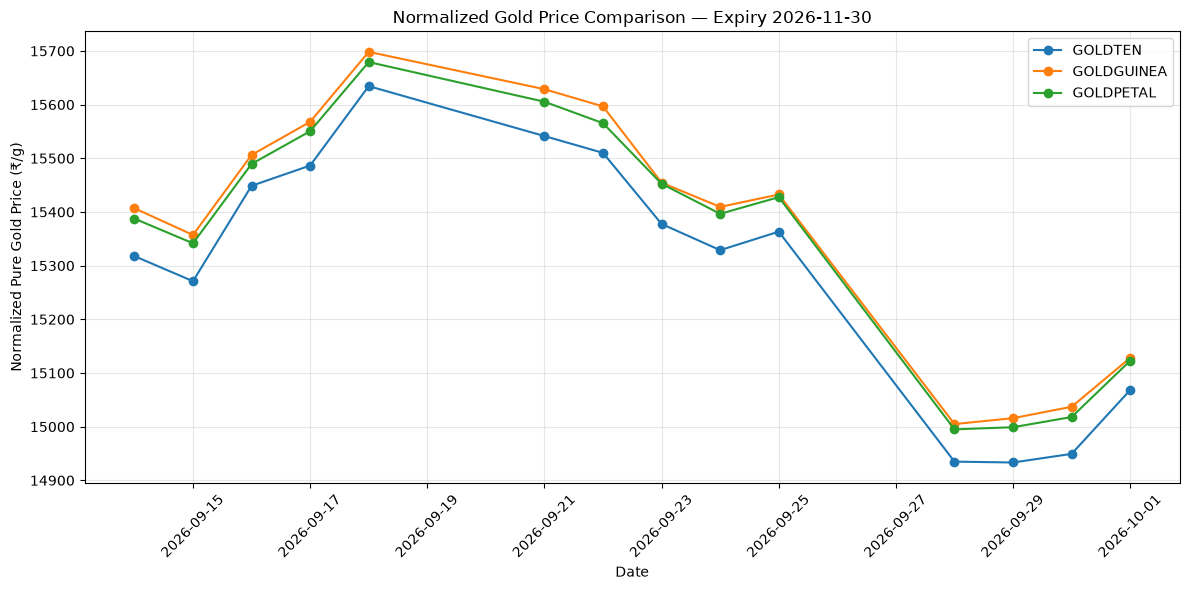

In [65]:
# STEP 72: Normalized price comparison
# ---------------------------------------------------------
# Educational/research visualization only.
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Select one exact expiry
selected_expiry = pd.Timestamp("2026-11-30")

plot_data = historical_same_expiry[
    historical_same_expiry["Expiry Date Parsed"]
    == selected_expiry
].copy()

plot_data = plot_data.sort_values("Date")

print("SELECTED EXPIRY:", selected_expiry.date())
print("Observations:", len(plot_data))

# ---------------------------------------------------------
# Create chart
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    plot_data["Date"],
    plot_data["GOLDTEN"],
    marker="o",
    label="GOLDTEN"
)

plt.plot(
    plot_data["Date"],
    plot_data["GOLDGUINEA"],
    marker="o",
    label="GOLDGUINEA"
)

plt.plot(
    plot_data["Date"],
    plot_data["GOLDPETAL"],
    marker="o",
    label="GOLDPETAL"
)

plt.title(
    "Normalized Gold Price Comparison — Expiry 2026-11-30"
)

plt.xlabel("Date")
plt.ylabel("Normalized Pure Gold Price (₹/g)")

plt.grid(True, alpha=0.3)
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

SELECTED EXPIRY: 2026-11-30
Observations: 14


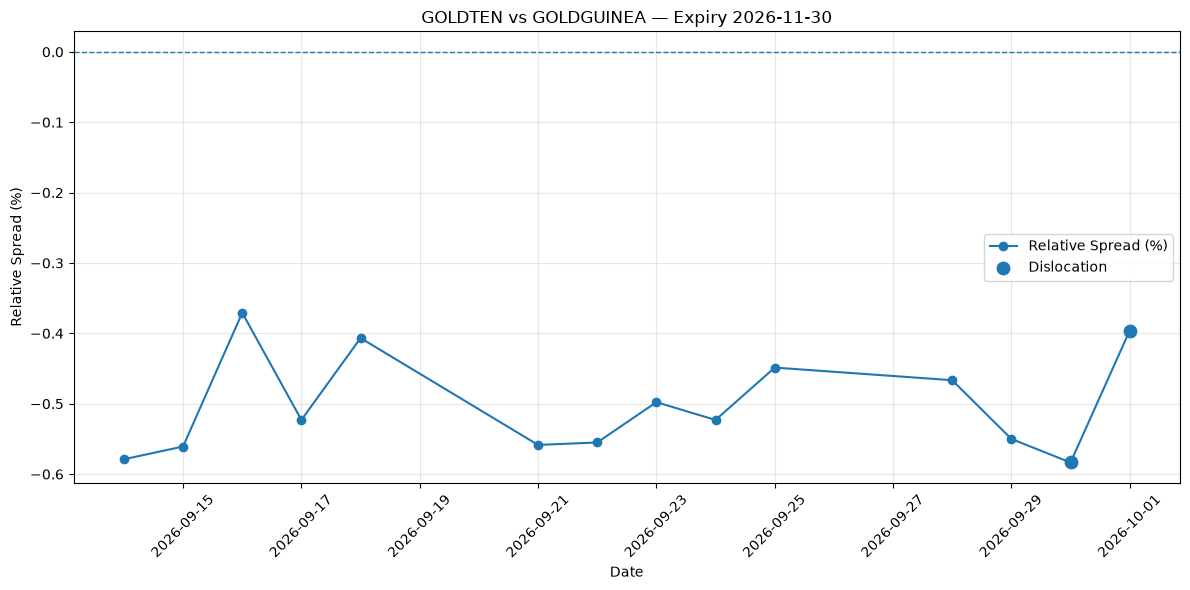

GOLDTEN vs GOLDGUINEA: 2 dislocation observations


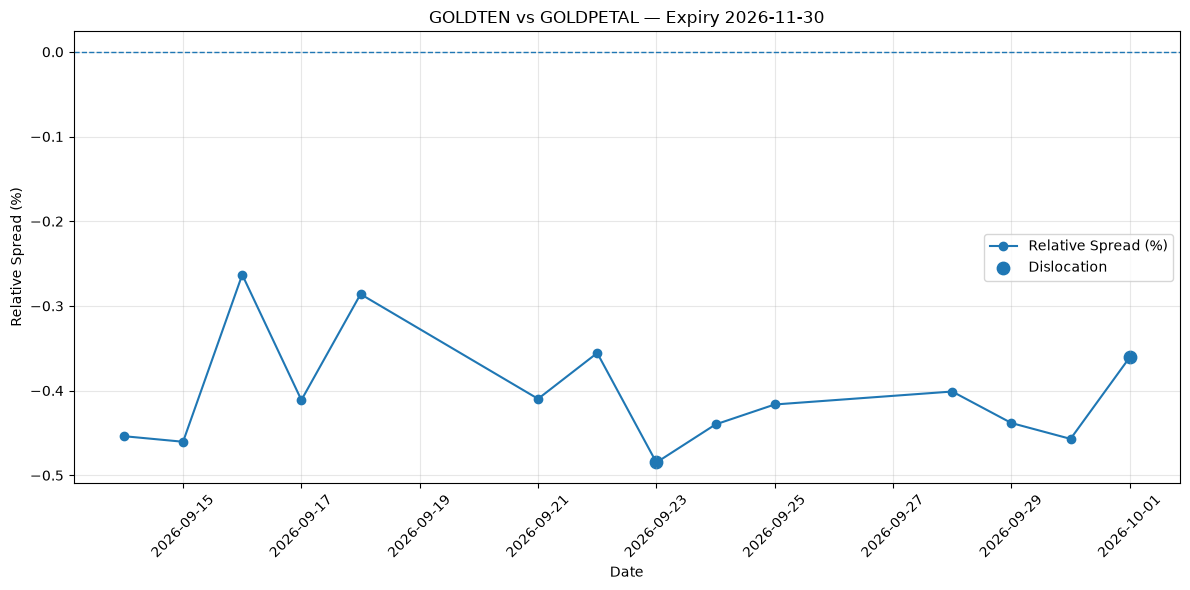

GOLDTEN vs GOLDPETAL: 2 dislocation observations


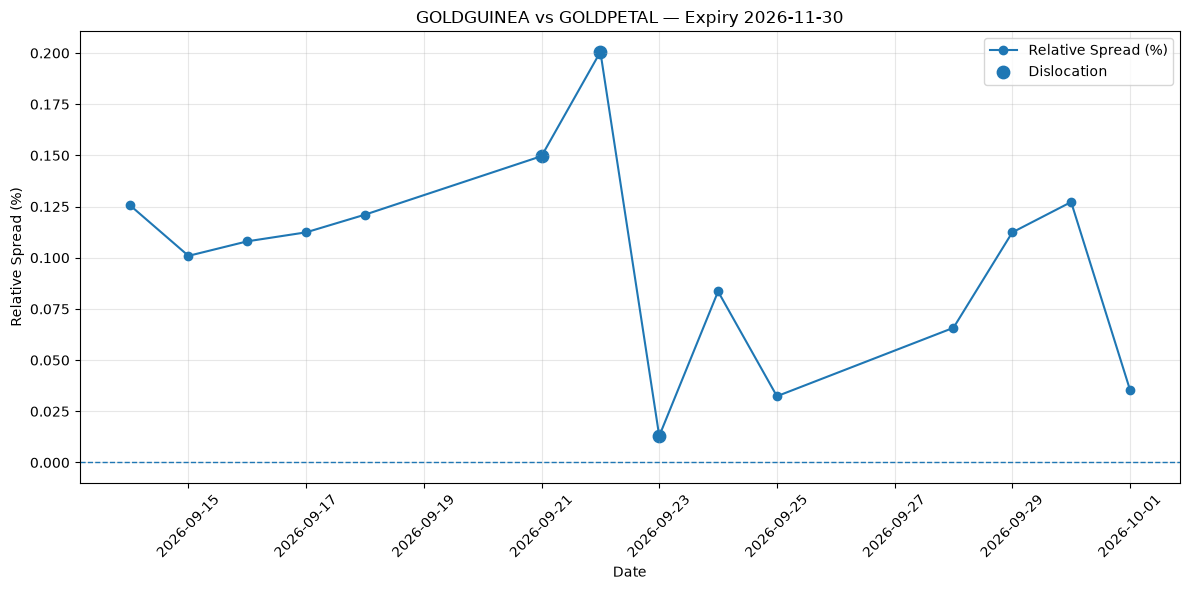

GOLDGUINEA vs GOLDPETAL: 3 dislocation observations


In [66]:
# STEP 73: Relative spread and dislocation visualization
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Select one exact expiry
selected_expiry = pd.Timestamp("2026-11-30")

plot_data = evaluation_data[
    evaluation_data["Expiry Date Parsed"] == selected_expiry
].copy()

plot_data = plot_data.sort_values("Date").reset_index(drop=True)

print("SELECTED EXPIRY:", selected_expiry.date())
print("Observations:", len(plot_data))

# ---------------------------------------------------------
# Create three separate spread charts
# ---------------------------------------------------------

spread_pairs = [
    (
        "TEN_vs_GUINEA_%",
        "TEN_vs_GUINEA_Signal",
        "GOLDTEN vs GOLDGUINEA"
    ),
    (
        "TEN_vs_PETAL_%",
        "TEN_vs_PETAL_Signal",
        "GOLDTEN vs GOLDPETAL"
    ),
    (
        "GUINEA_vs_PETAL_%",
        "GUINEA_vs_PETAL_Signal",
        "GOLDGUINEA vs GOLDPETAL"
    )
]

for spread_col, signal_col, title_name in spread_pairs:

    plt.figure(figsize=(12, 6))

    # Main spread line
    plt.plot(
        plot_data["Date"],
        plot_data[spread_col],
        marker="o",
        label="Relative Spread (%)"
    )

    # Identify dislocations
    dislocation_mask = plot_data[signal_col].isin([
        "EXTREME DISLOCATION",
        "UNUSUAL DISLOCATION"
    ])

    dislocation_data = plot_data[
        dislocation_mask
    ]

    # Mark dislocations
    if len(dislocation_data) > 0:

        plt.scatter(
            dislocation_data["Date"],
            dislocation_data[spread_col],
            s=80,
            label="Dislocation"
        )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.title(
        f"{title_name} — Expiry {selected_expiry.date()}"
    )

    plt.xlabel("Date")
    plt.ylabel("Relative Spread (%)")

    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

    print(
        f"{title_name}:",
        len(dislocation_data),
        "dislocation observations"
    )

SELECTED EXPIRY: 2026-11-30
Observations: 14


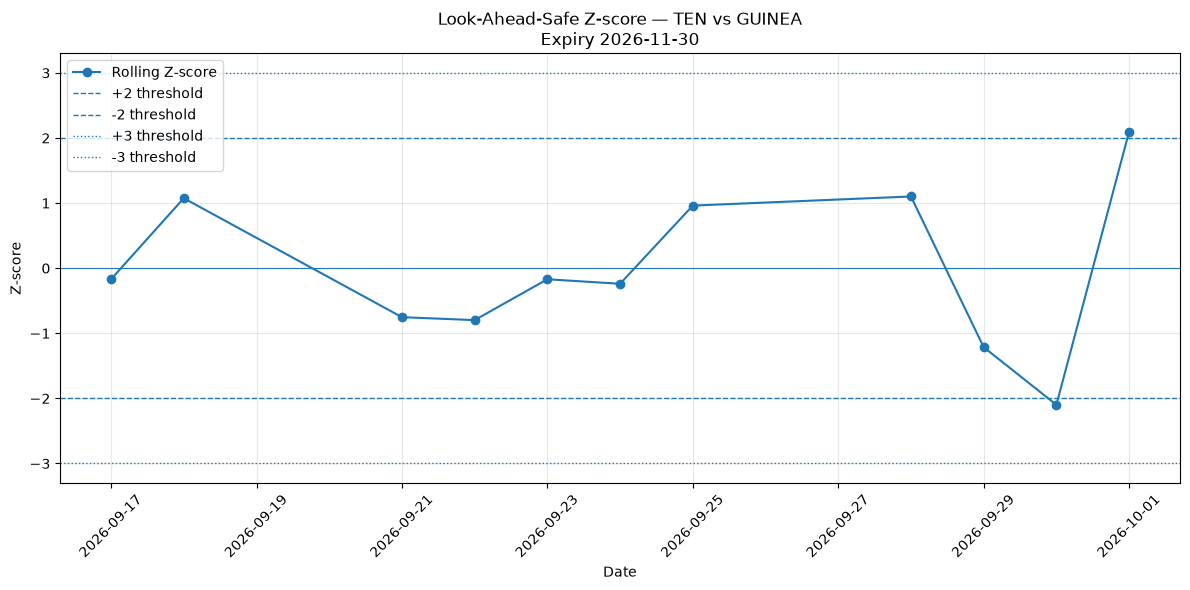


TEN vs GUINEA signal counts:
TEN_vs_GUINEA_Signal
NORMAL                  9
INSUFFICIENT HISTORY    3
UNUSUAL DISLOCATION     2
Name: count, dtype: int64
----------------------------------------------------------------------


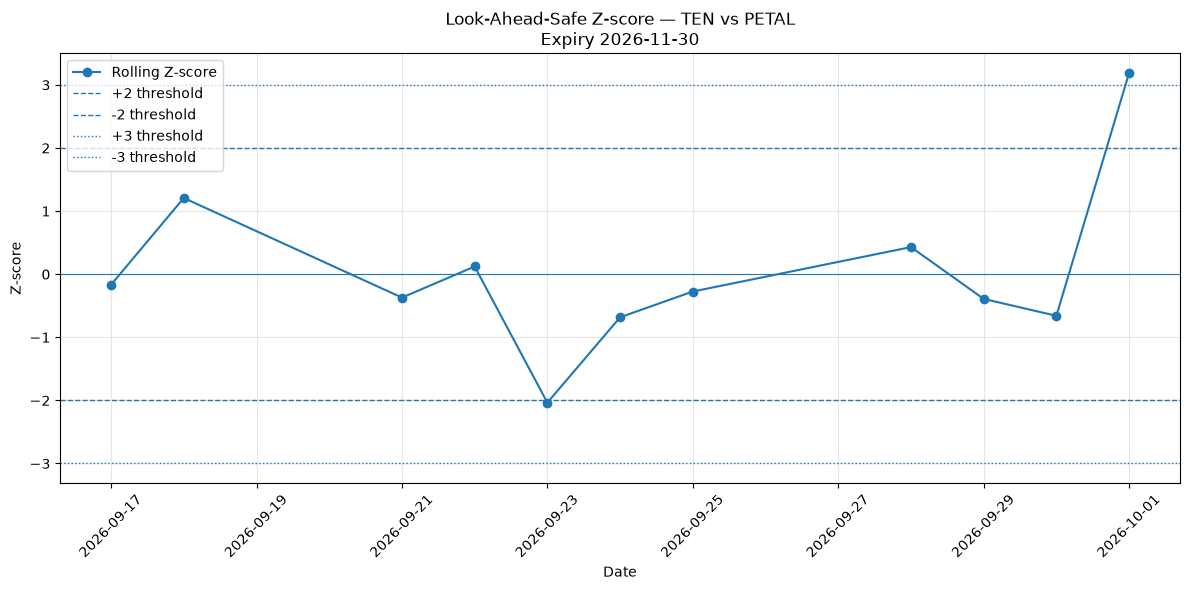


TEN vs PETAL signal counts:
TEN_vs_PETAL_Signal
NORMAL                  9
INSUFFICIENT HISTORY    3
UNUSUAL DISLOCATION     1
EXTREME DISLOCATION     1
Name: count, dtype: int64
----------------------------------------------------------------------


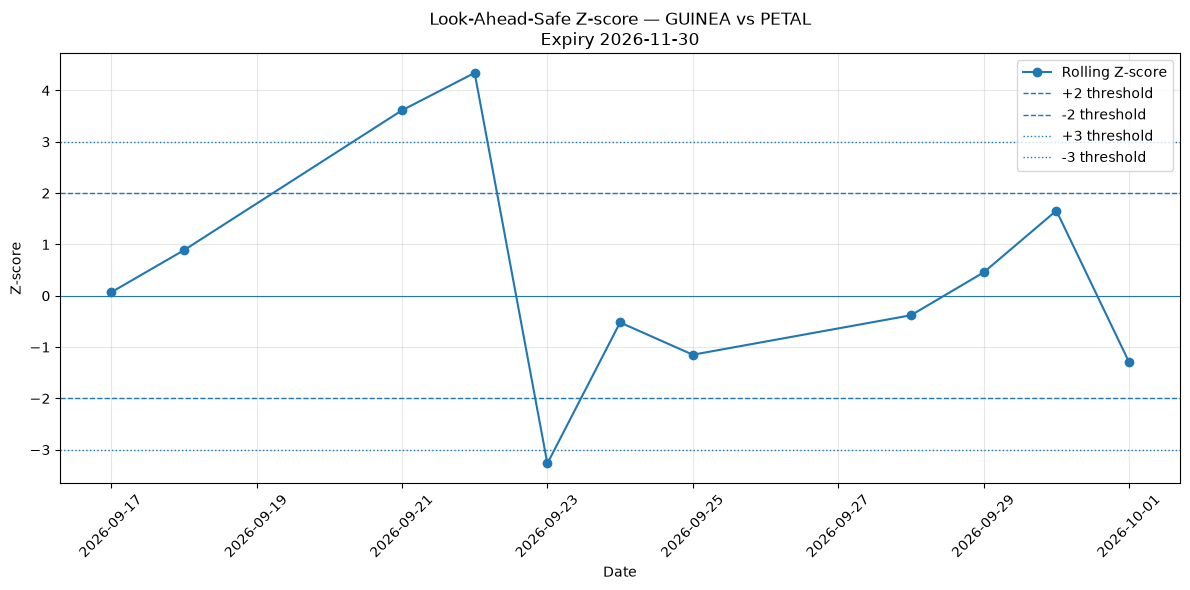


GUINEA vs PETAL signal counts:
GUINEA_vs_PETAL_Signal
NORMAL                  8
INSUFFICIENT HISTORY    3
EXTREME DISLOCATION     3
Name: count, dtype: int64
----------------------------------------------------------------------


In [67]:
# STEP 74: Z-score visualization
# ---------------------------------------------------------

import matplotlib.pyplot as plt

selected_expiry = pd.Timestamp("2026-11-30")

plot_data = evaluation_data[
    evaluation_data["Expiry Date Parsed"] == selected_expiry
].copy()

plot_data = (
    plot_data
    .sort_values("Date")
    .reset_index(drop=True)
)

print("SELECTED EXPIRY:", selected_expiry.date())
print("Observations:", len(plot_data))

# ---------------------------------------------------------
# Z-score pairs
# ---------------------------------------------------------

zscore_pairs = [
    (
        "TEN_vs_GUINEA_Z_ZScore",
        "TEN vs GUINEA"
    ),
    (
        "TEN_vs_PETAL_Z_ZScore",
        "TEN vs PETAL"
    ),
    (
        "GUINEA_vs_PETAL_Z_ZScore",
        "GUINEA vs PETAL"
    )
]

# ---------------------------------------------------------
# Create one chart per pair
# ---------------------------------------------------------

for zscore_col, pair_name in zscore_pairs:

    plt.figure(figsize=(12, 6))

    # Z-score line
    plt.plot(
        plot_data["Date"],
        plot_data[zscore_col],
        marker="o",
        label="Rolling Z-score"
    )

    # Threshold lines
    plt.axhline(
        2,
        linestyle="--",
        linewidth=1,
        label="+2 threshold"
    )

    plt.axhline(
        -2,
        linestyle="--",
        linewidth=1,
        label="-2 threshold"
    )

    plt.axhline(
        3,
        linestyle=":",
        linewidth=1,
        label="+3 threshold"
    )

    plt.axhline(
        -3,
        linestyle=":",
        linewidth=1,
        label="-3 threshold"
    )

    # Zero reference
    plt.axhline(
        0,
        linestyle="-",
        linewidth=0.8
    )

    plt.title(
        f"Look-Ahead-Safe Z-score — {pair_name}\n"
        f"Expiry {selected_expiry.date()}"
    )

    plt.xlabel("Date")
    plt.ylabel("Z-score")

    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

    # -----------------------------------------------------
    # Print signal observations
    # -----------------------------------------------------

    signal_col = (
        pair_name
        .replace(" vs ", "_vs_")
        + "_Signal"
    )

    if signal_col in plot_data.columns:

        signal_counts = (
            plot_data[signal_col]
            .value_counts()
        )

        print(f"\n{pair_name} signal counts:")
        print(signal_counts)

    print("-" * 70)

SELECTED EXPIRY: 2026-11-30
Development: 2026-09-14 to 2026-09-24
Validation: 2026-09-25 to 2026-10-01


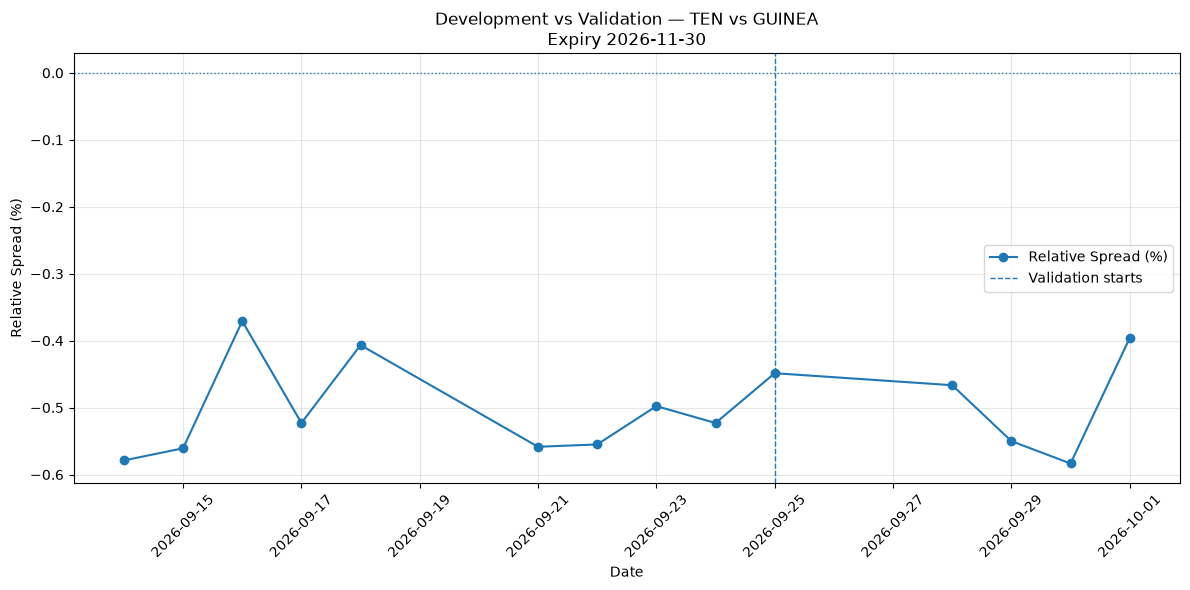

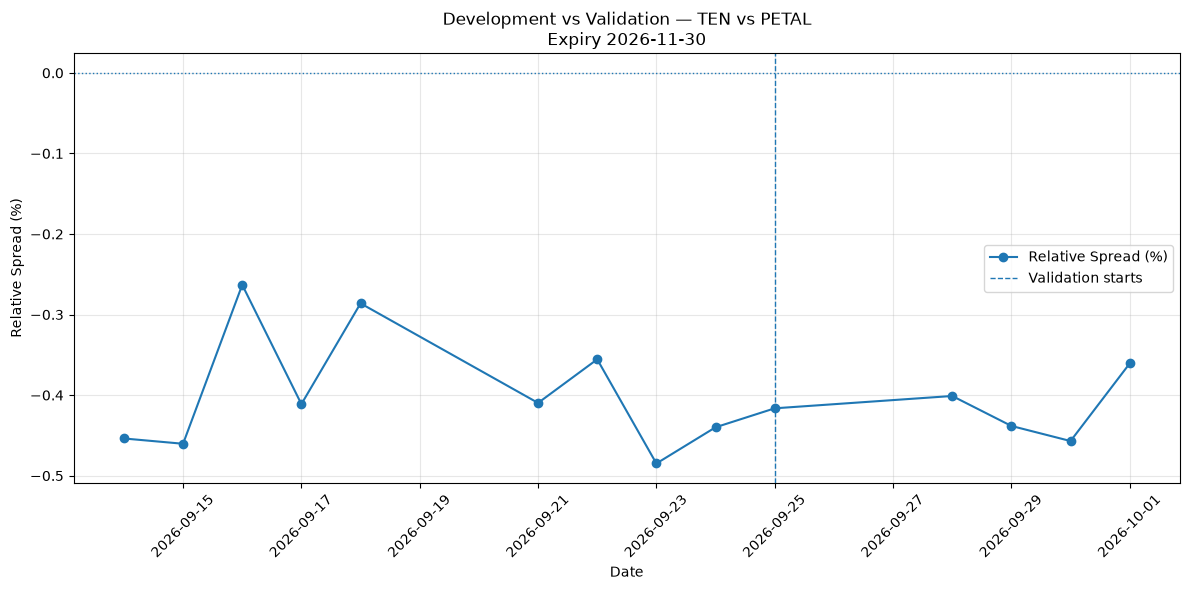

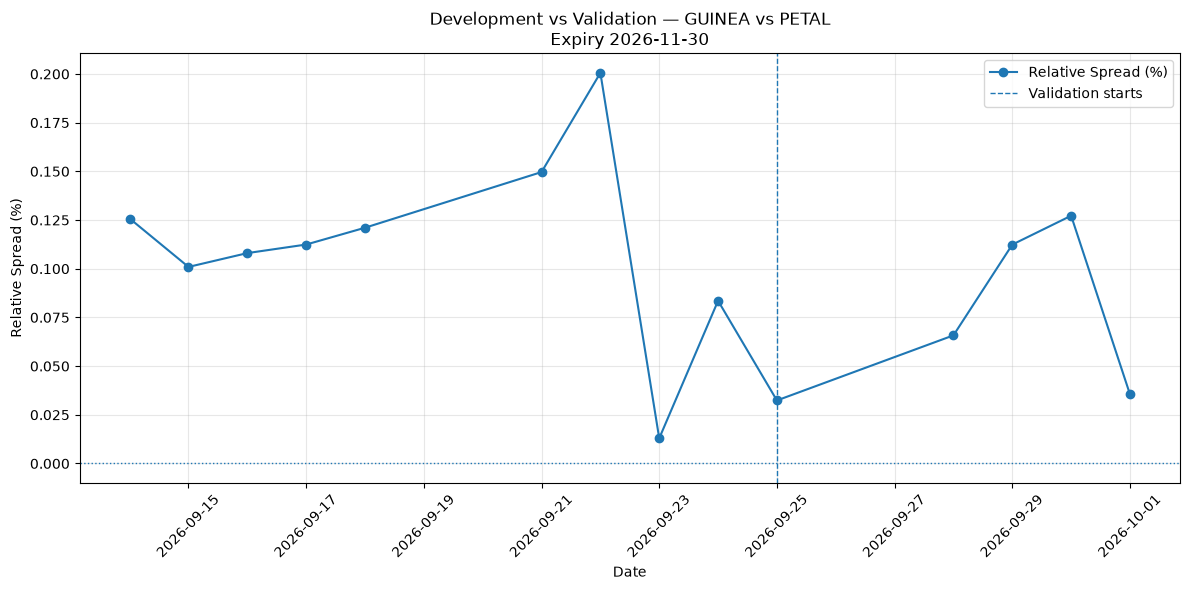

In [68]:
# STEP 75: Development vs Validation visualization
# ---------------------------------------------------------

import matplotlib.pyplot as plt

selected_expiry = pd.Timestamp("2026-11-30")

plot_data = evaluation_data[
    evaluation_data["Expiry Date Parsed"] == selected_expiry
].copy()

plot_data = (
    plot_data
    .sort_values("Date")
    .reset_index(drop=True)
)

# Add research period
plot_data["Research_Period"] = np.where(
    plot_data["Date"].dt.normalize().isin(
        development_dates
    ),
    "DEVELOPMENT",
    "VALIDATION"
)

print("SELECTED EXPIRY:", selected_expiry.date())
print(
    "Development:",
    plot_data[
        plot_data["Research_Period"] == "DEVELOPMENT"
    ]["Date"].min().date(),
    "to",
    plot_data[
        plot_data["Research_Period"] == "DEVELOPMENT"
    ]["Date"].max().date()
)

print(
    "Validation:",
    plot_data[
        plot_data["Research_Period"] == "VALIDATION"
    ]["Date"].min().date(),
    "to",
    plot_data[
        plot_data["Research_Period"] == "VALIDATION"
    ]["Date"].max().date()
)

# ---------------------------------------------------------
# Plot each relative spread separately
# ---------------------------------------------------------

spread_pairs = [
    (
        "TEN_vs_GUINEA_%",
        "TEN vs GUINEA"
    ),
    (
        "TEN_vs_PETAL_%",
        "TEN vs PETAL"
    ),
    (
        "GUINEA_vs_PETAL_%",
        "GUINEA vs PETAL"
    )
]

for spread_col, pair_name in spread_pairs:

    plt.figure(figsize=(12, 6))

    plt.plot(
        plot_data["Date"],
        plot_data[spread_col],
        marker="o",
        label="Relative Spread (%)"
    )

    # Find first validation date
    validation_rows = plot_data[
        plot_data["Research_Period"] == "VALIDATION"
    ]

    if len(validation_rows) > 0:

        validation_start = validation_rows[
            "Date"
        ].min()

        # Vertical separator
        plt.axvline(
            validation_start,
            linestyle="--",
            linewidth=1,
            label="Validation starts"
        )

    plt.axhline(
        0,
        linestyle=":",
        linewidth=1
    )

    plt.title(
        f"Development vs Validation — {pair_name}\n"
        f"Expiry {selected_expiry.date()}"
    )

    plt.xlabel("Date")
    plt.ylabel("Relative Spread (%)")

    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.show()

VALIDATION PERFORMANCE SUMMARY


,Pair,Validation_Evaluable,Validation_Contracted,Validation_Contraction_Rate_%,Validation_Mean_Abs_Change
0,TEN_vs_GUINEA,8,5,62.5,-0.115675
1,TEN_vs_PETAL,5,3,60.0,-0.074796
2,GUINEA_vs_PETAL,5,3,60.0,0.001331


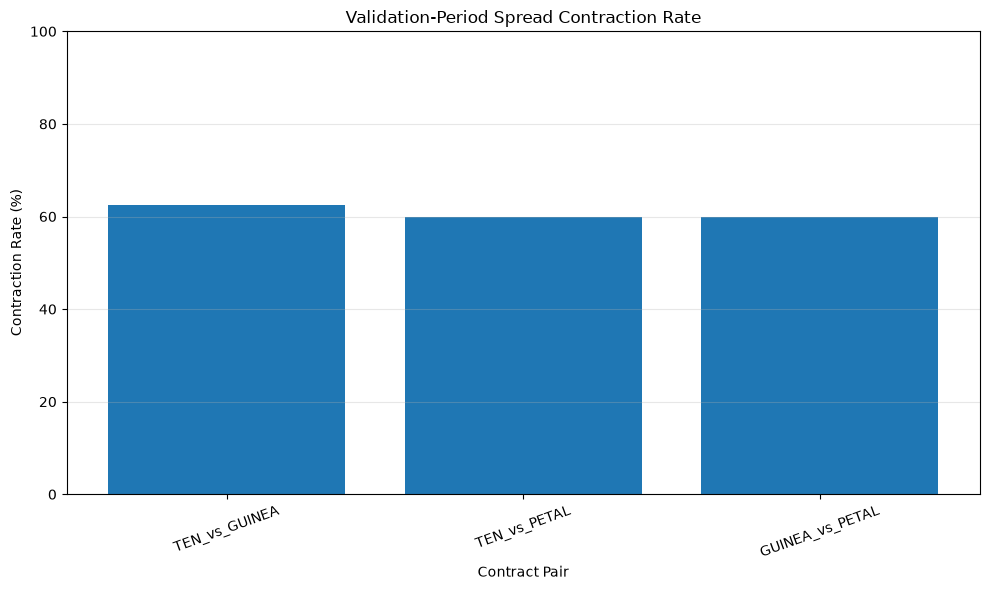

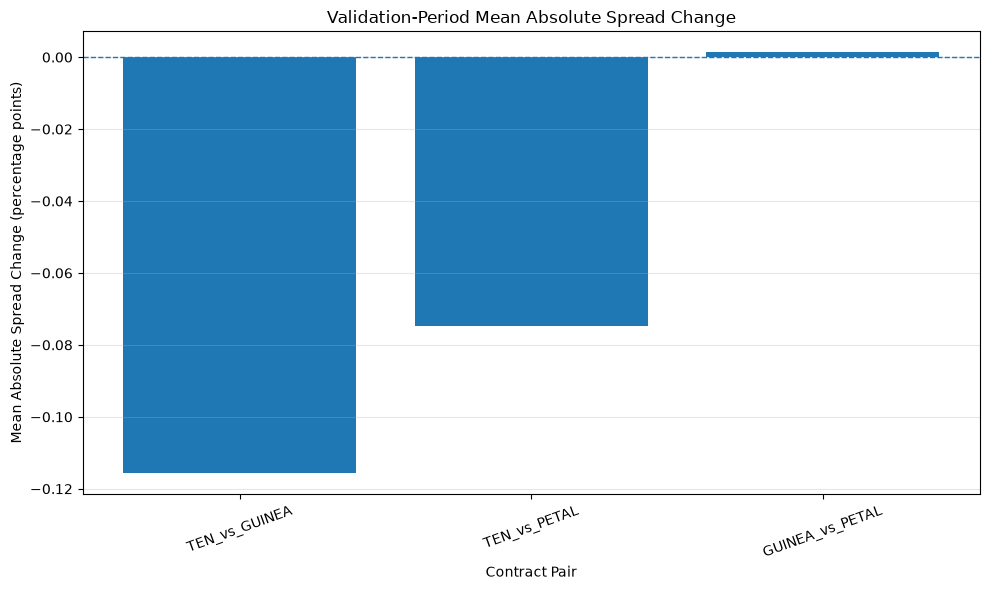

In [69]:
# STEP 76: Validation performance visualization
# ---------------------------------------------------------

import matplotlib.pyplot as plt

validation_plot_data = (
    development_validation_comparison[
        [
            "Pair",
            "Validation_Evaluable",
            "Validation_Contracted",
            "Validation_Contraction_Rate_%",
            "Validation_Mean_Abs_Change"
        ]
    ]
    .copy()
)

print("VALIDATION PERFORMANCE SUMMARY")
print("=" * 70)

display(validation_plot_data)

# ---------------------------------------------------------
# Chart 1: Validation contraction rate
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    validation_plot_data["Pair"],
    validation_plot_data[
        "Validation_Contraction_Rate_%"
    ]
)

plt.title(
    "Validation-Period Spread Contraction Rate"
)

plt.xlabel("Contract Pair")
plt.ylabel("Contraction Rate (%)")

plt.ylim(0, 100)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# ---------------------------------------------------------
# Chart 2: Mean absolute spread change
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    validation_plot_data["Pair"],
    validation_plot_data[
        "Validation_Mean_Abs_Change"
    ]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Validation-Period Mean Absolute Spread Change"
)

plt.xlabel("Contract Pair")

plt.ylabel(
    "Mean Absolute Spread Change (percentage points)"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

VALIDATION COST SENSITIVITY


,Pair,Cost_Assumption_%_Points,Validation_Observations,Positive_Rate_%,Mean_Gross_Contraction,Mean_Net_Contraction
0,GUINEA_vs_PETAL,0.02,5,60.0,-0.001331,-0.021331
1,GUINEA_vs_PETAL,0.05,5,20.0,-0.001331,-0.051331
2,GUINEA_vs_PETAL,0.10,5,20.0,-0.001331,-0.101331
3,GUINEA_vs_PETAL,0.20,5,20.0,-0.001331,-0.201331
4,TEN_vs_GUINEA,0.02,8,62.5,0.115675,0.095675
5,TEN_vs_GUINEA,0.05,8,50.0,0.115675,0.065675
6,TEN_vs_GUINEA,0.10,8,50.0,0.115675,0.015675
7,TEN_vs_GUINEA,0.20,8,12.5,0.115675,-0.084325
8,TEN_vs_PETAL,0.02,5,60.0,0.074796,0.054796
9,TEN_vs_PETAL,0.05,5,60.0,0.074796,0.024796


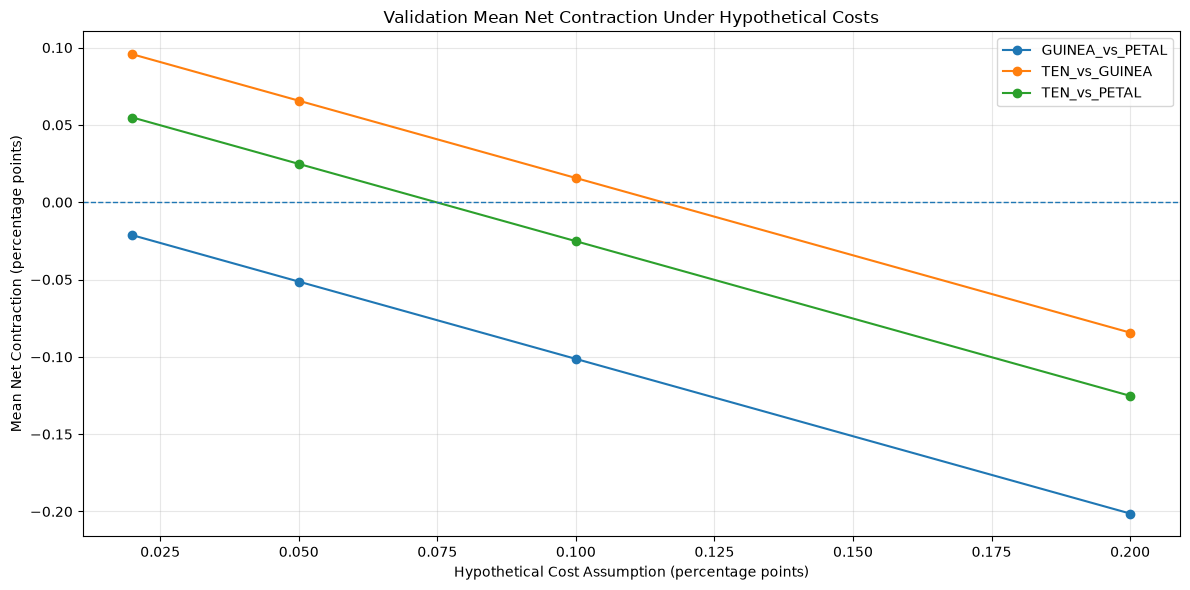

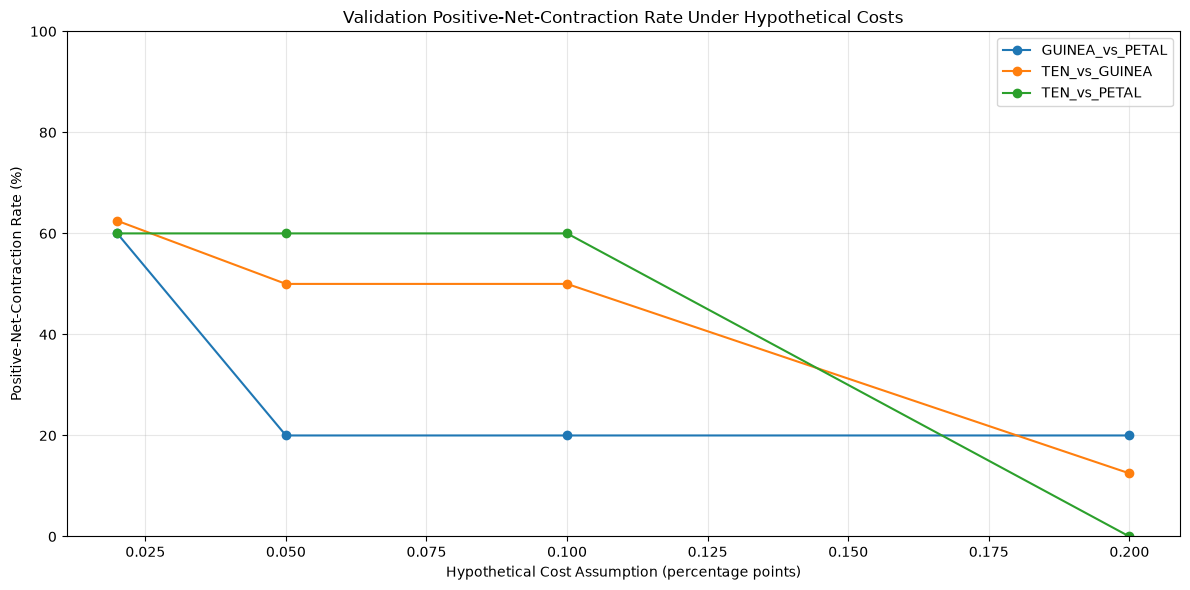

In [70]:
# STEP 77: Cost-sensitivity visualization
# ---------------------------------------------------------

import matplotlib.pyplot as plt

cost_plot_data = (
    validation_cost_sensitivity
    .copy()
    .sort_values(
        ["Pair", "Cost_Assumption_%_Points"]
    )
    .reset_index(drop=True)
)

print("VALIDATION COST SENSITIVITY")
print("=" * 70)

display(
    cost_plot_data[
        [
            "Pair",
            "Cost_Assumption_%_Points",
            "Validation_Observations",
            "Positive_Rate_%",
            "Mean_Gross_Contraction",
            "Mean_Net_Contraction"
        ]
    ]
)

# ---------------------------------------------------------
# Chart 1: Mean net contraction vs assumed cost
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

for pair_name in cost_plot_data["Pair"].unique():

    pair_data = cost_plot_data[
        cost_plot_data["Pair"] == pair_name
    ]

    plt.plot(
        pair_data["Cost_Assumption_%_Points"],
        pair_data["Mean_Net_Contraction"],
        marker="o",
        label=pair_name
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Validation Mean Net Contraction Under Hypothetical Costs"
)

plt.xlabel(
    "Hypothetical Cost Assumption (percentage points)"
)

plt.ylabel(
    "Mean Net Contraction (percentage points)"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.show()


# ---------------------------------------------------------
# Chart 2: Positive-net-contraction rate
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

for pair_name in cost_plot_data["Pair"].unique():

    pair_data = cost_plot_data[
        cost_plot_data["Pair"] == pair_name
    ]

    plt.plot(
        pair_data["Cost_Assumption_%_Points"],
        pair_data["Positive_Rate_%"],
        marker="o",
        label=pair_name
    )

plt.title(
    "Validation Positive-Net-Contraction Rate Under Hypothetical Costs"
)

plt.xlabel(
    "Hypothetical Cost Assumption (percentage points)"
)

plt.ylabel(
    "Positive-Net-Contraction Rate (%)"
)

plt.ylim(0, 100)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()

plt.show()

In [71]:
# STEP 78: Final project results table
# ---------------------------------------------------------

# Start from the final research summary
project_results = final_research_summary.copy()

# Add overall signal counts
signal_counts = (
    post_signal_summary[
        [
            "Pair",
            "Total_Signals",
            "Extreme_Signals",
            "Unusual_Signals"
        ]
    ]
    .copy()
)

project_results = project_results.merge(
    signal_counts,
    on="Pair",
    how="left"
)

# Add validation signal counts
validation_signal_counts = []

for pair_name in pairs.keys():

    pair_validation = validation_data[
        validation_data[
            pairs[pair_name]["signal"]
        ].isin([
            "EXTREME DISLOCATION",
            "UNUSUAL DISLOCATION"
        ])
    ]

    validation_signal_counts.append({
        "Pair": pair_name,
        "Validation_Dislocation_Signals":
            len(pair_validation)
    })

validation_signal_counts = pd.DataFrame(
    validation_signal_counts
)

project_results = project_results.merge(
    validation_signal_counts,
    on="Pair",
    how="left"
)

# ---------------------------------------------------------
# Select report-ready columns
# ---------------------------------------------------------

report_columns = [
    "Pair",

    "Total_Signals",
    "Extreme_Signals",
    "Unusual_Signals",

    "Overall_Evaluable",
    "Overall_Contracted",
    "Overall_Contraction_Rate_%",

    "Development_Evaluable",
    "Development_Contraction_Rate_%",

    "Validation_Evaluable",
    "Validation_Contraction_Rate_%",

    "Validation_Dislocation_Signals",

    "Validation_Mean_Abs_Change",

    "Validation_0.05_Cost_Mean_Net_Contraction",
    "Validation_0.10_Cost_Mean_Net_Contraction"
]

# Keep only columns that exist
report_columns = [
    col for col in report_columns
    if col in project_results.columns
]

project_results = project_results[
    report_columns
].copy()

# ---------------------------------------------------------
# Save final table
# ---------------------------------------------------------

project_results_file = (
    PROCESSED_DATA_PATH
    / "final_project_results.csv"
)

project_results.to_csv(
    project_results_file,
    index=False
)

# ---------------------------------------------------------
# Display
# ---------------------------------------------------------

print("FINAL PROJECT RESULTS TABLE")
print("=" * 80)

display(project_results)

print("\n" + "=" * 80)

print("Rows:", len(project_results))
print("Columns:", len(project_results.columns))

print("\nFile:")
print(project_results_file)

print("\nFINAL PROJECT RESULTS TABLE SAVED")

FINAL PROJECT RESULTS TABLE


,Pair,Total_Signals,Extreme_Signals,Unusual_Signals,Overall_Evaluable,Overall_Contracted,Overall_Contraction_Rate_%,Development_Evaluable,Development_Contraction_Rate_%,Validation_Evaluable,Validation_Contraction_Rate_%,Validation_Dislocation_Signals,Validation_Mean_Abs_Change,Validation_0.05_Cost_Mean_Net_Contraction,Validation_0.10_Cost_Mean_Net_Contraction
0,TEN_vs_GUINEA,12,6,6,11,5,45.454545,3,0.000000,8,62.5,9,-0.115675,0.065675,0.015675
1,TEN_vs_PETAL,10,5,5,9,4,44.444444,4,25.000000,5,60.0,6,-0.074796,0.024796,-0.025204
2,GUINEA_vs_PETAL,12,10,2,12,7,58.333333,7,57.142857,5,60.0,5,0.001331,-0.051331,-0.101331



Rows: 3
Columns: 15

File:
c:\Users\ASUS\Desktop\commodity-intelligence\data\processed\final_project_results.csv

FINAL PROJECT RESULTS TABLE SAVED


EXPORTING FINAL REPORT CHARTS


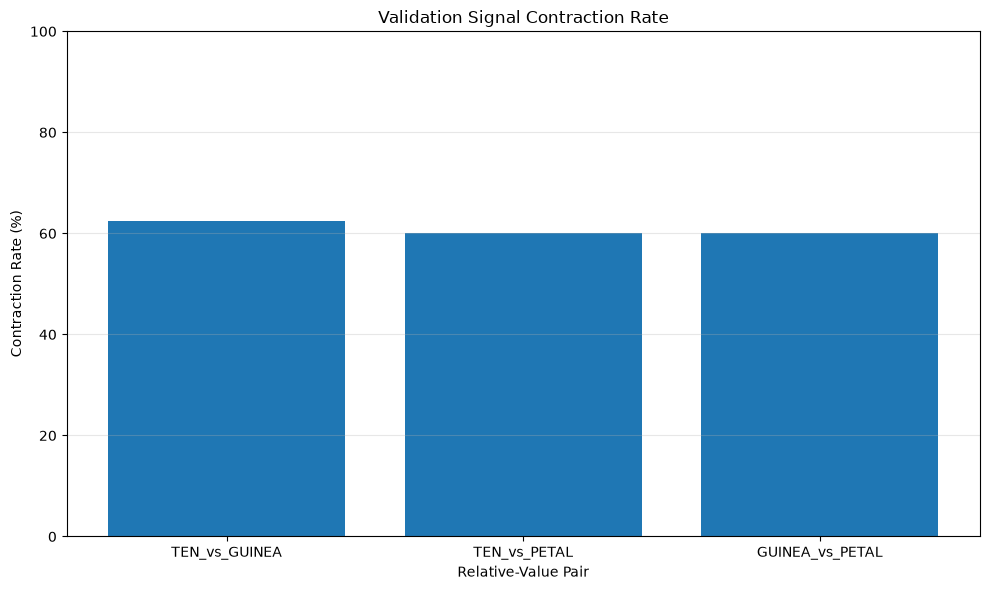

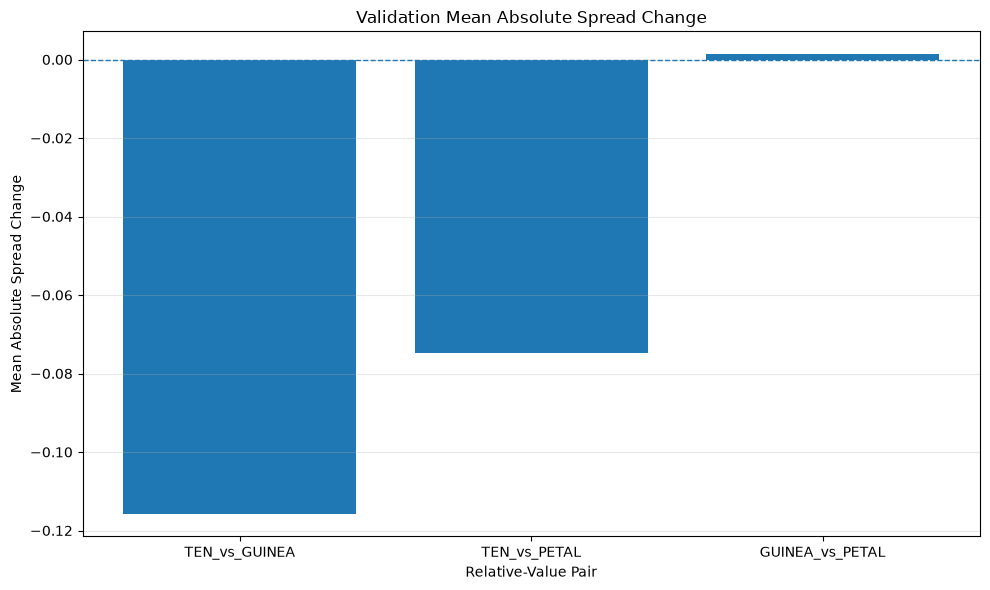

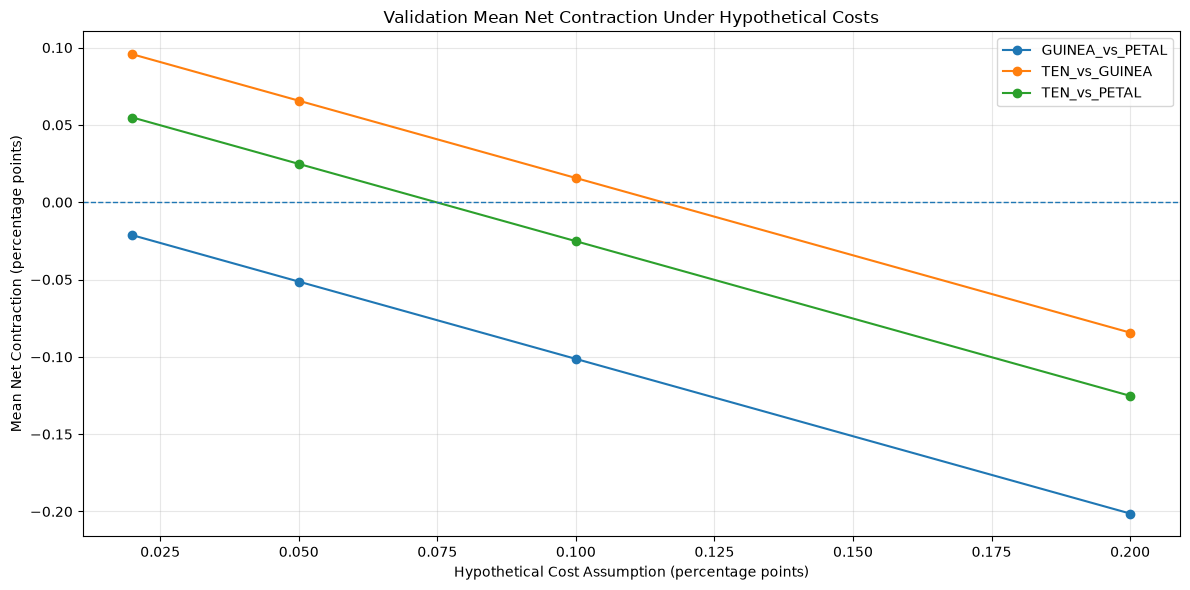

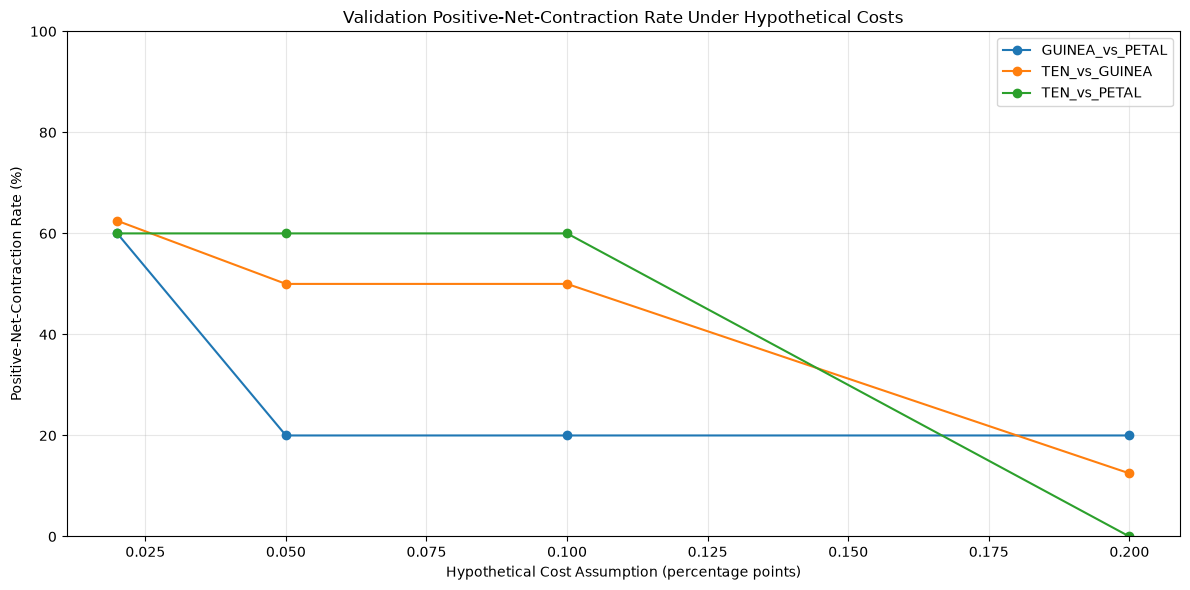

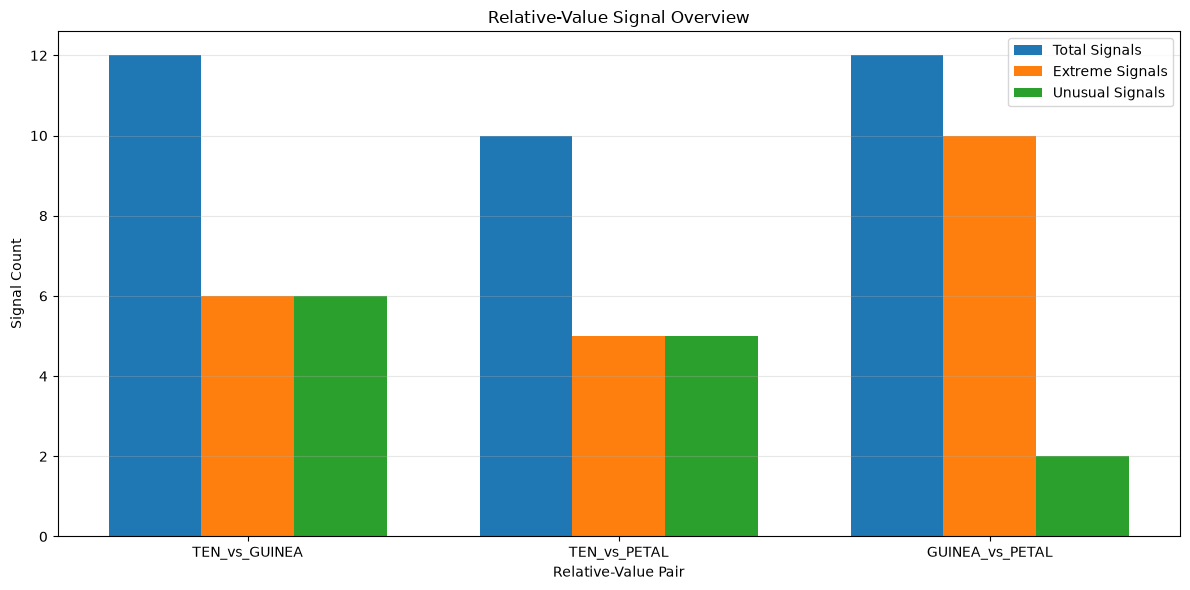


EXPORTED REPORT CHARTS
OK  c:\Users\ASUS\Desktop\commodity-intelligence\results\01_validation_contraction_rate.png
OK  c:\Users\ASUS\Desktop\commodity-intelligence\results\02_validation_mean_abs_change.png
OK  c:\Users\ASUS\Desktop\commodity-intelligence\results\03_validation_cost_sensitivity.png
OK  c:\Users\ASUS\Desktop\commodity-intelligence\results\04_validation_positive_rate.png
OK  c:\Users\ASUS\Desktop\commodity-intelligence\results\05_signal_overview.png

Total charts exported: 5

STEP 79 COMPLETE


In [72]:
# STEP 79: Export final report charts
# ---------------------------------------------------------

import matplotlib.pyplot as plt
from pathlib import Path

# Create results folder
RESULTS_PATH = PROJECT_ROOT / "results"
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print("EXPORTING FINAL REPORT CHARTS")
print("=" * 80)

# ---------------------------------------------------------
# 1. Validation Contraction Rate
# ---------------------------------------------------------

validation_chart = development_validation_comparison[
    [
        "Pair",
        "Validation_Contraction_Rate_%"
    ]
].copy()

plt.figure(figsize=(10, 6))

plt.bar(
    validation_chart["Pair"],
    validation_chart["Validation_Contraction_Rate_%"]
)

plt.title(
    "Validation Signal Contraction Rate"
)
plt.xlabel("Relative-Value Pair")
plt.ylabel("Contraction Rate (%)")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

file1 = RESULTS_PATH / "01_validation_contraction_rate.png"

plt.savefig(
    file1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# 2. Validation Mean Absolute Spread Change
# ---------------------------------------------------------

validation_change = development_validation_comparison[
    [
        "Pair",
        "Validation_Mean_Abs_Change"
    ]
].copy()

plt.figure(figsize=(10, 6))

plt.bar(
    validation_change["Pair"],
    validation_change["Validation_Mean_Abs_Change"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Validation Mean Absolute Spread Change"
)
plt.xlabel("Relative-Value Pair")
plt.ylabel("Mean Absolute Spread Change")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

file2 = RESULTS_PATH / "02_validation_mean_abs_change.png"

plt.savefig(
    file2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# 3. Validation Cost Sensitivity
# ---------------------------------------------------------

cost_plot_data = (
    validation_cost_sensitivity
    .copy()
    .sort_values(
        ["Pair", "Cost_Assumption_%_Points"]
    )
)

plt.figure(figsize=(12, 6))

for pair_name in cost_plot_data["Pair"].unique():

    pair_data = cost_plot_data[
        cost_plot_data["Pair"] == pair_name
    ]

    plt.plot(
        pair_data["Cost_Assumption_%_Points"],
        pair_data["Mean_Net_Contraction"],
        marker="o",
        label=pair_name
    )

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Validation Mean Net Contraction Under Hypothetical Costs"
)

plt.xlabel(
    "Hypothetical Cost Assumption (percentage points)"
)

plt.ylabel(
    "Mean Net Contraction (percentage points)"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

file3 = RESULTS_PATH / "03_validation_cost_sensitivity.png"

plt.savefig(
    file3,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# 4. Validation Positive-Net-Contraction Rate
# ---------------------------------------------------------

plt.figure(figsize=(12, 6))

for pair_name in cost_plot_data["Pair"].unique():

    pair_data = cost_plot_data[
        cost_plot_data["Pair"] == pair_name
    ]

    plt.plot(
        pair_data["Cost_Assumption_%_Points"],
        pair_data["Positive_Rate_%"],
        marker="o",
        label=pair_name
    )

plt.title(
    "Validation Positive-Net-Contraction Rate Under Hypothetical Costs"
)

plt.xlabel(
    "Hypothetical Cost Assumption (percentage points)"
)

plt.ylabel(
    "Positive-Net-Contraction Rate (%)"
)

plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

file4 = RESULTS_PATH / "04_validation_positive_rate.png"

plt.savefig(
    file4,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# 5. Final Results Overview
# ---------------------------------------------------------

overview = project_results[
    [
        "Pair",
        "Total_Signals",
        "Extreme_Signals",
        "Unusual_Signals",
        "Overall_Contraction_Rate_%",
        "Validation_Contraction_Rate_%"
    ]
].copy()

x = range(len(overview))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    [i - width for i in x],
    overview["Total_Signals"],
    width=width,
    label="Total Signals"
)

plt.bar(
    x,
    overview["Extreme_Signals"],
    width=width,
    label="Extreme Signals"
)

plt.bar(
    [i + width for i in x],
    overview["Unusual_Signals"],
    width=width,
    label="Unusual Signals"
)

plt.xticks(
    list(x),
    overview["Pair"]
)

plt.title(
    "Relative-Value Signal Overview"
)

plt.xlabel("Relative-Value Pair")
plt.ylabel("Signal Count")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.legend()
plt.tight_layout()

file5 = RESULTS_PATH / "05_signal_overview.png"

plt.savefig(
    file5,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()


# ---------------------------------------------------------
# Verify exported files
# ---------------------------------------------------------

exported_files = [
    file1,
    file2,
    file3,
    file4,
    file5
]

print("\n" + "=" * 80)
print("EXPORTED REPORT CHARTS")
print("=" * 80)

for file_path in exported_files:
    print(
        f"{'OK' if file_path.exists() else 'ERROR'}  "
        f"{file_path}"
    )

print("\nTotal charts exported:", len(exported_files))
print("\nSTEP 79 COMPLETE")

In [73]:
# STEP 80: Final project package
# ---------------------------------------------------------

from pathlib import Path

RESULTS_PATH = PROJECT_ROOT / "results"
RESULTS_PATH.mkdir(parents=True, exist_ok=True)

print("CREATING FINAL PROJECT PACKAGE")
print("=" * 80)

# ---------------------------------------------------------
# 1. Copy final results table into results/
# ---------------------------------------------------------

final_results_file = RESULTS_PATH / "final_project_results.csv"

project_results.to_csv(
    final_results_file,
    index=False
)

# ---------------------------------------------------------
# 2. Create project summary text
# ---------------------------------------------------------

summary_file = RESULTS_PATH / "final_project_summary.txt"

summary_text = f"""
COMMODITY DERIVATIVES INTELLIGENCE
MCX GOLD RELATIVE PRICING ANALYZER
============================================================

RESEARCH PERIOD
------------------------------------------------------------
Start Date: 2026-09-14
End Date:   2026-10-01

Trading Dates: 14
Development Dates: 9
Validation Dates: 5

DATA
------------------------------------------------------------
Historical exact-expiry observations: 84
Relative-value pairs analyzed: 3

Pairs:
- TEN_vs_GUINEA
- TEN_vs_PETAL
- GUINEA_vs_PETAL

SIGNAL METHODOLOGY
------------------------------------------------------------
Rolling window: 5 observations
Minimum observations: 3
Z-score calculation: look-ahead-safe
Unusual threshold: |z| >= 2
Extreme threshold: |z| >= 3

VALIDATION
------------------------------------------------------------
Validation period:
2026-09-25 to 2026-10-01

The validation analysis measures whether the absolute
relative-price spread contracted at the next available
observation for the same exact expiry.

RESULTS
------------------------------------------------------------
"""

for _, row in project_results.iterrows():

    summary_text += f"""
{row['Pair']}
Total Signals: {row['Total_Signals']}
Extreme Signals: {row['Extreme_Signals']}
Unusual Signals: {row['Unusual_Signals']}
Overall Evaluable: {row['Overall_Evaluable']}
Overall Contraction Rate: {row['Overall_Contraction_Rate_%']:.2f}%
Development Contraction Rate: {row['Development_Contraction_Rate_%']:.2f}%
Validation Evaluable: {row['Validation_Evaluable']}
Validation Contraction Rate: {row['Validation_Contraction_Rate_%']:.2f}%
Validation Mean Absolute Change: {row['Validation_Mean_Abs_Change']:.6f}
"""

summary_text += """

COST SENSITIVITY
------------------------------------------------------------
Cost assumptions of 0.05 and 0.10 percentage points were
used only as hypothetical sensitivity assumptions.

They are NOT verified brokerage, taxes, bid-ask spread,
slippage, exchange charges, or execution costs.

IMPORTANT LIMITATIONS
------------------------------------------------------------
1. The research sample contains only 14 trading dates.
2. The validation period contains only 5 trading dates.
3. Observations within an expiry lifecycle may not be
   statistically independent.
4. Closing/settlement prices are not guaranteed executable
   prices.
5. Volume does not represent complete market depth.
6. Actual transaction costs were not modeled.
7. GOLDM was excluded from the exact-expiry 999-purity
   comparisons because its expiry schedule and purity differ.
8. The current walk-forward split is a prototype and should
   be tested over substantially longer historical data.
9. The results should be interpreted as historical research
   findings, not as a prediction or trading recommendation.

CONCLUSION
------------------------------------------------------------
The project demonstrates a complete research pipeline for
detecting, classifying, and evaluating relative pricing
dislocations between selected MCX gold contracts.

The validation results provide an initial out-of-sample
research check, while the limited sample size and simplified
execution-cost assumptions mean that stronger conclusions
require substantially more historical data and more realistic
execution modeling.

============================================================
END OF PROJECT SUMMARY
============================================================
"""

with open(
    summary_file,
    "w",
    encoding="utf-8"
) as f:
    f.write(summary_text)

# ---------------------------------------------------------
# 3. Verify package
# ---------------------------------------------------------

print("FINAL FILES")
print("=" * 80)

files_to_check = [
    final_results_file,
    summary_file
]

for file_path in files_to_check:

    print(
        f"{'OK' if file_path.exists() else 'ERROR'}  "
        f"{file_path}"
    )

print("\nFinal results rows:", len(project_results))
print("Final results columns:", len(project_results.columns))

print("\nSTEP 80 COMPLETE")

CREATING FINAL PROJECT PACKAGE
FINAL FILES
OK  c:\Users\ASUS\Desktop\commodity-intelligence\results\final_project_results.csv
OK  c:\Users\ASUS\Desktop\commodity-intelligence\results\final_project_summary.txt

Final results rows: 3
Final results columns: 15

STEP 80 COMPLETE
